# Comparison with Observations: Survey Populations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import rc
import matplotlib as mpl
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import pathlib
from scipy.integrate import quad
from scipy import stats

from pypopsyn.simulator.config_simulator import cfg
import pypopsyn.simulator.basics.constants as const
import utilities.plot_settings

In [2]:
# Canonical neutron star moment of inertia in [g cm^2] assuming a perfect solid sphere.
NS_inertia = 2.0 / 5.0 * cfg["NS_mass"] * cfg["NS_radius"] ** 2

# Auxiliary quantity beta as defined in eq. (72) of Pons & Vigano (2019).
beta = np.pi**2 * cfg["NS_radius"] ** 6 / (NS_inertia * const.C**3)

# Assume an inclination angle in [rad].
chi = 0.0

# Incorporate the inclination angle dependence into a constant.
beta_1 = beta * (
    cfg["k_coefficients"][0] + cfg["k_coefficients"][1] * np.sin(chi) ** 2
)

In [3]:
# Set this variable to True if you want to also include the X-ray data.
survey_x = True

In [4]:
def outburst_filter(age, B):
    outburst_prob = np.zeros(len(age))
    outburst_prob[age <= 100] = np.random.uniform(0.40, 0.85, size=len(age[age <= 100]))
    outburst_prob[(age > 100) & (age <= 400)] = np.random.uniform(0.1, 0.4, size=len(age[(age > 100) & (age <= 400)]))
    outburst_prob[(age > 400) & (age <= 1000)] = np.random.uniform(0.05, 0.2, size=len(age[(age > 400) & (age <= 1000)]))
    #outburst_prob[(age > 1000) & (age <= 2000)] = np.random.uniform(0.02, 0.1, size=len(age[(age > 1000) & (age <= 2000)]))
    outburst_prob[age > 1000] = np.random.uniform(0.0, 0.05, size=len(age[age > 1000]))

    mask = (np.random.rand(len(outburst_prob)) < outburst_prob) & (B >= 1.e13)

    return mask

In [5]:
def pwn_filter(Erot_dot):
    pwn_prob = np.zeros(len(Erot_dot))
    pwn_prob[Erot_dot > 1.e36] = np.random.uniform(0.7, 0.9, size=len(Erot_dot[Erot_dot > 1.e36]))
    pwn_prob[(Erot_dot > 1.e33) & (Erot_dot <= 1.e36)] = np.random.uniform(0.3, 0.5, size=len(Erot_dot[(Erot_dot > 1.e33) & (Erot_dot <= 1.e36)]))

    mask = (np.random.rand(len(pwn_prob)) < pwn_prob)

    return mask

In [6]:
def flux_filter(S_x, mean_threshold):
    flux_threshold = 10**np.random.normal(mean_threshold, 0.5, len(S_x))
    mask = S_x > flux_threshold
    return mask

## Load observed data

### Load the ATNF Pulsar Catalogue for the observed radio surveys.

In [7]:
# Read the full ATNF catalog.csv file. Binary pulsars are excluded.
df_atnf = pd.read_csv(
    "../../data/observations/atnf_full_nobinary_25-03-2025_with_errors.csv",
    delimiter=";",
    header=[0, 1],
)
df_atnf.columns

df_atnf.columns = df_atnf.columns.droplevel(1)

In [8]:
# Select only stars that are not in globular clusters or in the Magellanic Clouds.
discard = [
    "EXGAL:SMC",
    "EXGAL:LMC",
    "GC:47Tuc",
    "GC:M3",
    "GC:M5",
    "GC:M13",
    "GC:NGC6440",
    "GC:Ter5",
    "GC:NGC6441",
    "GC:NGC6517",
    "GC:NGC6522",
    "GC:NGC6624",
    "GC:M28(NGC6626)",
    "GC:NGC6652",
    "GC:M22(NGC6656)",
    "GC:NGC6752",
    "GC:NGC6760",
    "GC:M15",
    "GC:M30",
]

df_atnf = df_atnf[
    ~df_atnf["ASSOC"].str.match("|".join(discard))
]

# Select only isolated non-recycled neutron stars through filters with P > 0.01 and Pdot > 1e-19 (for those with measured values).
df_atnf = df_atnf[df_atnf["P0"].to_numpy().astype(np.float64) > 0.01]

df_atnf = df_atnf[
    (df_atnf["P1"].to_numpy().astype(np.float64) > 1.0e-19)
    | (df_atnf["P1"].isin(["NAN"]))
]

In [9]:
# Parks multibeam pulsar survey database.
df_atnf_pk = df_atnf[
    df_atnf["SURVEY"].str.contains("pksmb")
]

# Database of pulsars detected by Parkes multibeam
# that have a pulse width W10 measurement available.
df_atnf_pk_w10 = df_atnf_pk[~df_atnf_pk["W10"].isin(["NAN"])]

# Database of pulsars detected by Parkes multibeam
# that have a proper motion measurement available.
df_atnf_pk_pm = df_atnf_pk[
    (df_atnf_pk["PMRA"] != "NAN")
    & (df_atnf_pk["PMDEC"] != "NAN")
]

RA_pk_obs = df_atnf_pk["RAJD"].to_numpy().astype(np.float64)
DEC_pk_obs = df_atnf_pk["DECJD"].to_numpy().astype(np.float64)
l_pk_obs = df_atnf_pk["Gl"].to_numpy().astype(np.float64)
b_pk_obs = df_atnf_pk["Gb"].to_numpy().astype(np.float64)
P_pk_obs = df_atnf_pk["P0"].to_numpy().astype(np.float64)
Pdot_pk_obs = df_atnf_pk["P1"].to_numpy().astype(np.float64)
DM_pk_obs = df_atnf_pk["DM"].to_numpy().astype(np.float64)
dist_pk_obs = df_atnf_pk["DIST"].to_numpy().astype(np.float64)
S1400_pk_obs = df_atnf_pk["S1400"].to_numpy().astype(np.float64)

l_pk_obs_pm = df_atnf_pk_pm["Gl"].to_numpy().astype(np.float64)
b_pk_obs_pm = df_atnf_pk_pm["Gb"].to_numpy().astype(np.float64)
Pdot_pk_obs_pm = df_atnf_pk_pm["P1"].to_numpy().astype(np.float64)
dist_pk_obs_pm = df_atnf_pk_pm["DIST"].to_numpy().astype(np.float64)
pmRA_pk_obs = df_atnf_pk_pm["PMRA"].to_numpy().astype(np.float64)
pmDEC_pk_obs = df_atnf_pk_pm["PMDEC"].to_numpy().astype(np.float64)

l_pk_obs_w10 = df_atnf_pk_w10["Gl"].to_numpy().astype(np.float64)
b_pk_obs_w10 = df_atnf_pk_w10["Gb"].to_numpy().astype(np.float64)
P_pk_obs_w10 = df_atnf_pk_w10["P0"].to_numpy().astype(np.float64)
Pdot_pk_obs_w10 = df_atnf_pk_w10["P1"].to_numpy().astype(np.float64)
dist_pk_obs_w10 = df_atnf_pk_w10["DIST"].to_numpy().astype(np.float64)
w10_pk_obs = df_atnf_pk_w10["W10"].to_numpy().astype(np.float64)

# Convert galactic latitude in the range [-180., 180].
l_pk_obs[(l_pk_obs > 180.0) & (l_pk_obs < 360.0)] = (
    l_pk_obs[(l_pk_obs > 180.0) & (l_pk_obs < 360.0)] - 360.0
)
l_pk_obs_pm[(l_pk_obs_pm > 180.0) & (l_pk_obs_pm < 360.0)] = (
    l_pk_obs_pm[(l_pk_obs_pm > 180.0) & (l_pk_obs_pm < 360.0)] - 360.0
)
l_pk_obs_w10[(l_pk_obs_w10 > 180.0) & (l_pk_obs_w10 < 360.0)] = (
    l_pk_obs_w10[(l_pk_obs_w10 > 180.0) & (l_pk_obs_w10 < 360.0)] - 360.0
)

# Select only pulsars falling in the Parkes multibeam sky coverage where completness is above 90%.
cond = (l_pk_obs > -100.0) & (l_pk_obs < 50.0) & (np.abs(b_pk_obs) < 5.0)
cond_w10 = (
    (l_pk_obs_w10 > -100.0)
    & (l_pk_obs_w10 < 50.0)
    & (np.abs(b_pk_obs_w10) < 5.0)
)
cond_pm = (
    (l_pk_obs_pm > -100.0) & (l_pk_obs_pm < 50.0) & (np.abs(b_pk_obs_pm) < 5.0)
)

RA_pk_obs = RA_pk_obs[cond]
DEC_pk_obs = DEC_pk_obs[cond]
l_pk_obs = l_pk_obs[cond]
b_pk_obs = b_pk_obs[cond]
P_pk_obs = P_pk_obs[cond]
Pdot_pk_obs = Pdot_pk_obs[cond]
DM_pk_obs = DM_pk_obs[cond]
dist_pk_obs = dist_pk_obs[cond]
S1400_pk_obs = S1400_pk_obs[cond]
P_pk_obs_w10 = P_pk_obs_w10[cond_w10]
w10_pk_obs = w10_pk_obs[cond_w10]
pmRA_pk_obs = pmRA_pk_obs[cond_pm]
pmDEC_pk_obs = pmDEC_pk_obs[cond_pm]

number_pk = len(RA_pk_obs)

In [10]:
# Swinburne multibeam pulsar survey database.
df_atnf_sw = df_atnf[
    df_atnf["SURVEY"].str.contains("pkssw")
]

# Database of pulsars detected by Swinburne that have a pulse width W10 measurment available.
df_atnf_sw_w10 = df_atnf_sw[~df_atnf_sw["W10"].isin(["NAN"])]
# Database of pulsars detected by Swinburne that have a proper motion measurment available.
df_atnf_sw_pm = df_atnf_sw[
    (df_atnf_sw["PMRA"] != "NAN")
    & (df_atnf_sw["PMDEC"] != "NAN")
]

RA_sw_obs = df_atnf_sw["RAJD"].to_numpy().astype(np.float64)
DEC_sw_obs = df_atnf_sw["DECJD"].to_numpy().astype(np.float64)
l_sw_obs = df_atnf_sw["Gl"].to_numpy().astype(np.float64)
b_sw_obs = df_atnf_sw["Gb"].to_numpy().astype(np.float64)
P_sw_obs = df_atnf_sw["P0"].to_numpy().astype(np.float64)
Pdot_sw_obs = df_atnf_sw["P1"].to_numpy().astype(np.float64)
DM_sw_obs = df_atnf_sw["DM"].to_numpy().astype(np.float64)
dist_sw_obs = df_atnf_sw["DIST"].to_numpy().astype(np.float64)
S1400_sw_obs = df_atnf_sw["S1400"].to_numpy().astype(np.float64)

l_sw_obs_pm = df_atnf_sw_pm["Gl"].to_numpy().astype(np.float64)
b_sw_obs_pm = df_atnf_sw_pm["Gb"].to_numpy().astype(np.float64)
Pdot_sw_obs_pm = df_atnf_sw_pm["P1"].to_numpy().astype(np.float64)
dist_sw_obs_pm = df_atnf_sw_pm["DIST"].to_numpy().astype(np.float64)
pmRA_sw_obs = df_atnf_sw_pm["PMRA"].to_numpy().astype(np.float64)
pmDEC_sw_obs = df_atnf_sw_pm["PMDEC"].to_numpy().astype(np.float64)

l_sw_obs_w10 = df_atnf_sw_w10["Gl"].to_numpy().astype(np.float64)
b_sw_obs_w10 = df_atnf_sw_w10["Gb"].to_numpy().astype(np.float64)
P_sw_obs_w10 = df_atnf_sw_w10["P0"].to_numpy().astype(np.float64)
Pdot_sw_obs_w10 = df_atnf_sw_w10["P1"].to_numpy().astype(np.float64)
dist_sw_obs_w10 = df_atnf_sw_w10["DIST"].to_numpy().astype(np.float64)
w10_sw_obs = df_atnf_sw_w10["W10"].to_numpy().astype(np.float64)

# Convert galactic latitude in the range [-180., 180].
l_sw_obs[(l_sw_obs > 180.0) & (l_sw_obs < 360.0)] = (
    l_sw_obs[(l_sw_obs > 180.0) & (l_sw_obs < 360.0)] - 360.0
)
l_sw_obs_pm[(l_sw_obs_pm > 180.0) & (l_sw_obs_pm < 360.0)] = (
    l_sw_obs_pm[(l_sw_obs_pm > 180.0) & (l_sw_obs_pm < 360.0)] - 360.0
)
l_sw_obs_w10[(l_sw_obs_w10 > 180.0) & (l_sw_obs_w10 < 360.0)] = (
    l_sw_obs_w10[(l_sw_obs_w10 > 180.0) & (l_sw_obs_w10 < 360.0)] - 360.0
)

# Selection only pulsars falling in the Swinburne sky coverage where completness is above 90%.
cond = (l_sw_obs > -100.0) & (l_sw_obs < 50.0)
cond_w10 = (l_sw_obs_w10 > -100.0) & (l_sw_obs_w10 < 50.0)
cond_pm = (l_sw_obs_pm > -100.0) & (l_sw_obs_pm < 50.0)

RA_sw_obs = RA_sw_obs[cond]
DEC_sw_obs = DEC_sw_obs[cond]
l_sw_obs = l_sw_obs[cond]
b_sw_obs = b_sw_obs[cond]
P_sw_obs = P_sw_obs[cond]
Pdot_sw_obs = Pdot_sw_obs[cond]
DM_sw_obs = DM_sw_obs[cond]
dist_sw_obs = dist_sw_obs[cond]
S1400_sw_obs = S1400_sw_obs[cond]
P_sw_obs_w10 = P_sw_obs_w10[cond_w10]
w10_sw_obs = w10_sw_obs[cond_w10]
pmRA_sw_obs = pmRA_sw_obs[cond_pm]
pmDEC_sw_obs = pmDEC_sw_obs[cond_pm]

number_sw = len(RA_sw_obs)

In [11]:
# HTRU pulsar survey database.
df_atnf_htru = df_atnf[
    df_atnf["SURVEY"].str.contains("htru_pks")
]

# Database of pulsars detected by Swinburne that have a pulse width W10 measurment available.
df_atnf_htru_w10 = df_atnf_htru[~df_atnf_htru["W10"].isin(["NAN"])]
# Database of pulsars detected by Swinburne that have a proper motion measurment available.
df_atnf_htru_pm = df_atnf_htru[
    (df_atnf_htru["PMRA"] != "NAN")
    & (df_atnf_htru["PMDEC"] != "NAN")
]

RA_htru_obs = df_atnf_htru["RAJD"].to_numpy().astype(np.float64)
DEC_htru_obs = df_atnf_htru["DECJD"].to_numpy().astype(np.float64)
l_htru_obs = df_atnf_htru["Gl"].to_numpy().astype(np.float64)
b_htru_obs = df_atnf_htru["Gb"].to_numpy().astype(np.float64)
P_htru_obs = df_atnf_htru["P0"].to_numpy().astype(np.float64)
Pdot_htru_obs = df_atnf_htru["P1"].to_numpy().astype(np.float64)
DM_htru_obs = df_atnf_htru["DM"].to_numpy().astype(np.float64)
dist_htru_obs = df_atnf_htru["DIST"].to_numpy().astype(np.float64)
S1400_htru_obs = df_atnf_htru["S1400"].to_numpy().astype(np.float64)

l_htru_obs_pm = df_atnf_htru_pm["Gl"].to_numpy().astype(np.float64)
b_htru_obs_pm = df_atnf_htru_pm["Gb"].to_numpy().astype(np.float64)
Pdot_htru_obs_pm = df_atnf_htru_pm["P1"].to_numpy().astype(np.float64)
dist_htru_obs_pm = (
    df_atnf_htru_pm["DIST"].to_numpy().astype(np.float64)
)
pmRA_htru_obs = (
    df_atnf_htru_pm["PMRA"].to_numpy().astype(np.float64)
)
pmDEC_htru_obs = (
    df_atnf_htru_pm["PMDEC"].to_numpy().astype(np.float64)
)

l_htru_obs_w10 = df_atnf_htru_w10["Gl"].to_numpy().astype(np.float64)
b_htru_obs_w10 = df_atnf_htru_w10["Gb"].to_numpy().astype(np.float64)
P_htru_obs_w10 = df_atnf_htru_w10["P0"].to_numpy().astype(np.float64)
Pdot_htru_obs_w10 = (
    df_atnf_htru_w10["P1"].to_numpy().astype(np.float64)
)
dist_htru_obs_w10 = (
    df_atnf_htru_w10["DIST"].to_numpy().astype(np.float64)
)
w10_htru_obs = df_atnf_htru_w10["W10"].to_numpy().astype(np.float64)

# Convert galactic latitude in the range [-180., 180].
l_htru_obs[(l_htru_obs > 180.0) & (l_htru_obs < 360.0)] = (
    l_htru_obs[(l_htru_obs > 180.0) & (l_htru_obs < 360.0)] - 360.0
)
l_htru_obs_pm[(l_htru_obs_pm > 180.0) & (l_htru_obs_pm < 360.0)] = (
    l_htru_obs_pm[(l_htru_obs_pm > 180.0) & (l_htru_obs_pm < 360.0)] - 360.0
)
l_htru_obs_w10[(l_htru_obs_w10 > 180.0) & (l_htru_obs_w10 < 360.0)] = (
    l_htru_obs_w10[(l_htru_obs_w10 > 180.0) & (l_htru_obs_w10 < 360.0)] - 360.0
)

# Selection only pulsars falling in the HTRU sky coverage where completness is above 90%.
cond = (
    (l_htru_obs > -120.0) & (l_htru_obs < 30.0) & (np.abs(b_htru_obs) < 15.0)
)
cond_pm = (
    (l_htru_obs_pm > -120.0) & (l_htru_obs_pm < 30.0) & (np.abs(b_htru_obs_pm) < 15.0)
)
cond_w10 = (
    (l_htru_obs_w10 > -120.0) & (l_htru_obs_w10 < 30.0) & (np.abs(b_htru_obs_w10) < 15.0)
)

RA_htru_obs = RA_htru_obs[cond]
DEC_htru_obs = DEC_htru_obs[cond]
l_htru_obs = l_htru_obs[cond]
b_htru_obs = b_htru_obs[cond]
P_htru_obs = P_htru_obs[cond]
Pdot_htru_obs = Pdot_htru_obs[cond]
DM_htru_obs = DM_htru_obs[cond]
dist_htru_obs = dist_htru_obs[cond]
S1400_htru_obs = S1400_htru_obs[cond]
P_htru_obs_w10 = P_htru_obs_w10[cond_w10]
w10_htru_obs = w10_htru_obs[cond_w10]
pmRA_htru_obs = pmRA_htru_obs[cond_pm]
pmDEC_htru_obs = pmDEC_htru_obs[cond_pm]

number_htru = len(RA_htru_obs)

In [12]:
RA_all_obs = np.concatenate((RA_pk_obs, RA_sw_obs, RA_htru_obs))
DEC_all_obs = np.concatenate((DEC_pk_obs, DEC_sw_obs, DEC_htru_obs))
pmRA_all_obs = np.concatenate((pmRA_pk_obs, pmRA_sw_obs, pmRA_htru_obs))
pmDEC_all_obs = np.concatenate((pmDEC_pk_obs, pmDEC_sw_obs, pmDEC_htru_obs))
l_all_obs = np.concatenate((l_pk_obs, l_sw_obs, l_htru_obs))
b_all_obs = np.concatenate((b_pk_obs, b_sw_obs, b_htru_obs))
P_all_obs = np.concatenate((P_pk_obs, P_sw_obs, P_htru_obs))
Pdot_all_obs = np.concatenate((Pdot_pk_obs, Pdot_sw_obs, Pdot_htru_obs))
DM_all_obs = np.concatenate((DM_pk_obs, DM_sw_obs, DM_htru_obs))
dist_all_obs = np.concatenate((dist_pk_obs, dist_sw_obs, dist_htru_obs))
S1400_all_obs = np.concatenate((S1400_pk_obs, S1400_sw_obs, S1400_htru_obs))
P_all_obs_w10 = np.concatenate((P_pk_obs_w10, P_sw_obs_w10, P_htru_obs_w10))
w10_all_obs = np.concatenate((w10_pk_obs, w10_sw_obs, w10_htru_obs))

In [13]:
print(f"Number of pulsars detected by Parks multibeam: {number_pk}")
print(f"Number of pulsars detected by Swinburne: {number_sw}")
print(f"Number of pulsars detected by HTRU: {number_htru}")

Number of pulsars detected by Parks multibeam: 1045
Number of pulsars detected by Swinburne: 218
Number of pulsars detected by HTRU: 1095


### Load the catalog of observed thermally emitting neutron stars.

In [14]:
# Read the thermally emitting neutron star catalog.csv file. Binary pulsars are excluded.
df_x_obs = pd.read_csv(
    "../../data/observations/thermal_NS_05-11-2024.csv",
    delimiter=",",
    header=[0],
)
df_x_obs.head()
df_x_obs.columns

Index(['source', 'abs. flux (0.3-10 keV)', 'period(s)', 'pdot(1e-11s/s)',
       'distance(kpc)', 'l(deg)', 'b(deg)', 'ra(deg)', 'dec(deg)',
       'luminosity_bol_qui(e33erg/s)', 'class', 'assoc', 'age_real(kyr)'],
      dtype='object')

In [15]:
# We remove Central Compact Objects (CCOs) because their magnetic field have likely been buried
# due to supernova fallback and their evolution cannot be modelled with our simulation framework.
# We also remove those stars that belong to the Magellanic Clouds.
df_x_obs = df_x_obs[~df_x_obs["class"].isin(["CCO"])]
df_x_obs = df_x_obs[~df_x_obs["assoc"].isin(["PWN", "PWN, Radio"])]
df_x_obs = df_x_obs[~df_x_obs["assoc"].isin(["SMC", "LMC"])]
df_x_obs = df_x_obs.dropna(subset=["period(s)"])
df_x_obs = df_x_obs.dropna(subset=["pdot(1e-11s/s)"])
df_x_obs = df_x_obs.dropna(subset=["abs. flux (0.3-10 keV)"])

In [16]:
l_x_obs = df_x_obs["l(deg)"].to_numpy().astype(np.float64)
b_x_obs = df_x_obs["b(deg)"].to_numpy().astype(np.float64)
RA_x_obs = df_x_obs["ra(deg)"].to_numpy().astype(np.float64)
DEC_x_obs = df_x_obs["dec(deg)"].to_numpy().astype(np.float64)
dist_x_obs = df_x_obs["distance(kpc)"].to_numpy().astype(np.float64)
P_x_obs = df_x_obs["period(s)"].to_numpy().astype(np.float64)
Pdot_x_obs = df_x_obs["pdot(1e-11s/s)"].to_numpy().astype(np.float64) * 1e-11
L_x_bol_obs = (
    df_x_obs["luminosity_bol_qui(e33erg/s)"].to_numpy().astype(np.float64)
    * 1e33
)
S_x_abs_obs = df_x_obs["abs. flux (0.3-10 keV)"].to_numpy().astype(np.float64)
age_x_obs = df_x_obs["age_real(kyr)"].to_numpy().astype(np.float64)

In [17]:
# Convert galactic latitude in the range [-180., 180].
l_x_obs[(l_x_obs > 180.0) & (l_x_obs < 360.0)] = (
    l_x_obs[(l_x_obs > 180.0) & (l_x_obs < 360.0)] - 360.0
)

number_x = len(l_x_obs)
print(f"Number of pulsars detected in X-rays: {number_x}")

Number of pulsars detected in X-rays: 35


## Load simulated data

### Load the output of a simulated detection with the radio and X-ray surveys.

In [18]:
#path_to_simulation = pathlib.Path("../../data/example_simulation_magrot_det/")
path_to_simulation = pathlib.Path("../../toremove/sim_x_BKS24_multi_heavy/")

# Load the `.pkl.gz` files containing the survey results to import.
df_PMPS_sim = pd.read_pickle(
    pathlib.Path().joinpath(path_to_simulation, "survey_PMPS_results.pkl.gz"),
    compression="gzip",
)
df_PMPS_sim.head()

df_SMPS_sim = pd.read_pickle(
    pathlib.Path().joinpath(path_to_simulation, "survey_SMPS_results.pkl.gz"),
    compression="gzip",
)

df_HTRU_sim = pd.read_pickle(
    pathlib.Path().joinpath(
        path_to_simulation, "survey_HTRU_low_mid_results.pkl.gz"
    ),
    compression="gzip",
)

In [19]:
# Extracting the parameters.
RA_pk_sim = df_PMPS_sim["RA"]["[deg]"].to_numpy()
DEC_pk_sim = df_PMPS_sim["DEC"]["[deg]"].to_numpy()
l_pk_sim = df_PMPS_sim["l"]["[deg]"].to_numpy()
b_pk_sim = df_PMPS_sim["b"]["[deg]"].to_numpy()
pmRA_pk_sim = df_PMPS_sim["pm_RA"]["[mas yr^-1]"].to_numpy()
pmDEC_pk_sim = df_PMPS_sim["pm_DEC"]["[mas yr^-1]"].to_numpy()
DM_pk_sim = df_PMPS_sim["DM"]["[pc cm^-3]"].to_numpy()
dist_pk_sim = df_PMPS_sim["d"]["[kpc]"].to_numpy()
P_pk_sim = df_PMPS_sim["P"]["[s]"].to_numpy()
Pdot_pk_sim = df_PMPS_sim["P_dot"]["[s s^-1]"].to_numpy()
S1400_pk_sim = df_PMPS_sim["S_radio_obs_mean"]["[Jy]"].to_numpy()
w_eff_pk_sim = df_PMPS_sim["w_eff"]["[s]"].to_numpy()

In [20]:
RA_sw_sim = df_SMPS_sim["RA"]["[deg]"].to_numpy()
DEC_sw_sim = df_SMPS_sim["DEC"]["[deg]"].to_numpy()
l_sw_sim = df_SMPS_sim["l"]["[deg]"].to_numpy()
b_sw_sim = df_SMPS_sim["b"]["[deg]"].to_numpy()
pmRA_sw_sim = df_SMPS_sim["pm_RA"]["[mas yr^-1]"].to_numpy()
pmDEC_sw_sim = df_SMPS_sim["pm_DEC"]["[mas yr^-1]"].to_numpy()
DM_sw_sim = df_SMPS_sim["DM"]["[pc cm^-3]"].to_numpy()
dist_sw_sim = df_SMPS_sim["d"]["[kpc]"].to_numpy()
P_sw_sim = df_SMPS_sim["P"]["[s]"].to_numpy()
Pdot_sw_sim = df_SMPS_sim["P_dot"]["[s s^-1]"].to_numpy()
S1400_sw_sim = df_SMPS_sim["S_radio_obs_mean"]["[Jy]"].to_numpy()
w_eff_sw_sim = df_SMPS_sim["w_eff"]["[s]"].to_numpy()

In [21]:
RA_htru_sim = df_HTRU_sim["RA"]["[deg]"].to_numpy()
DEC_htru_sim = df_HTRU_sim["DEC"]["[deg]"].to_numpy()
l_htru_sim = df_HTRU_sim["l"]["[deg]"].to_numpy()
b_htru_sim = df_HTRU_sim["b"]["[deg]"].to_numpy()
pmRA_htru_sim = df_HTRU_sim["pm_RA"]["[mas yr^-1]"].to_numpy()
pmDEC_htru_sim = df_HTRU_sim["pm_DEC"]["[mas yr^-1]"].to_numpy()
DM_htru_sim = df_HTRU_sim["DM"]["[pc cm^-3]"].to_numpy()
dist_htru_sim = df_HTRU_sim["d"]["[kpc]"].to_numpy()
P_htru_sim = df_HTRU_sim["P"]["[s]"].to_numpy()
Pdot_htru_sim = df_HTRU_sim["P_dot"]["[s s^-1]"].to_numpy()
S1400_htru_sim = df_HTRU_sim["S_radio_obs_mean"]["[Jy]"].to_numpy()
w_eff_htru_sim = df_HTRU_sim["w_eff"]["[s]"].to_numpy()

In [22]:
if survey_x:
    df_x_sim = pd.read_pickle(
        pathlib.Path().joinpath(
            path_to_simulation, "survey_xray_results.pkl.gz"
        ),
        compression="gzip",
    )
    df_x_sim.columns

    age_x_sim = df_x_sim["age"]["[yr]"].to_numpy()
    RA_x_sim = df_x_sim["RA"]["[deg]"].to_numpy()
    DEC_x_sim = df_x_sim["DEC"]["[deg]"].to_numpy()
    l_x_sim = df_x_sim["l"]["[deg]"].to_numpy()
    b_x_sim = df_x_sim["b"]["[deg]"].to_numpy()
    pmRA_x_sim = df_x_sim["pm_RA"]["[mas yr^-1]"].to_numpy()
    pmDEC_x_sim = df_x_sim["pm_DEC"]["[mas yr^-1]"].to_numpy()
    NH_x_sim = df_x_sim["N_H"]["[cm^-2]"].to_numpy()
    dist_x_sim = df_x_sim["d"]["[kpc]"].to_numpy()
    P_x_sim = df_x_sim["P"]["[s]"].to_numpy()
    Pdot_x_sim = df_x_sim["P_dot"]["[s s^-1]"].to_numpy()
    B_x_sim = df_x_sim["B"]["[G]"].to_numpy()
    L_x_sim = df_x_sim["L_x_therm"]["[erg s^-1]"].to_numpy()
    S_x_rcs_abs_sim = df_x_sim["S_x_rcs_abs"]["[erg s^-1 cm^-2]"].to_numpy()
    S_x_bb_abs_sim = df_x_sim["S_x_bb_abs"]["[erg s^-1 cm^-2]"].to_numpy()

In [23]:
print(
    f"Number of pulsars detected by the simulated Parkes multibeam survey: {len(RA_pk_sim)}"
)
print(
    f"Number of pulsars detected by the simulated Swinburne survey: {len(RA_sw_sim)}"
)
print(
    f"Number of pulsars detected by the simulated HTRU surveys: {len(RA_htru_sim)}"
)
print(
    f"Number of pulsars detected by the simulated HTRU low survey: {len(df_HTRU_sim.loc[(df_HTRU_sim['HTRU_low'] ==1) ])}"
)
print(
    f"Number of pulsars detected by the simulated HTRU mid survey: {len(df_HTRU_sim.loc[(df_HTRU_sim['HTRU_mid'] ==1) ])}"
)
if survey_x:
    print(
        f"Number of pulsars detected by the Simulated X-ray-ray survey: {len(RA_x_sim)}"
    )

Number of pulsars detected by the simulated Parkes multibeam survey: 770
Number of pulsars detected by the simulated Swinburne survey: 133
Number of pulsars detected by the simulated HTRU surveys: 921
Number of pulsars detected by the simulated HTRU low survey: 719
Number of pulsars detected by the simulated HTRU mid survey: 538
Number of pulsars detected by the Simulated X-ray-ray survey: 1067


In [24]:
outburst_mask = outburst_filter(age_x_sim, B_x_sim)
flux_outburst_mask = flux_filter(S_x_bb_abs_sim, -14)
flux_mask = flux_filter(S_x_bb_abs_sim, -12)
outburst_mask = outburst_mask & flux_outburst_mask
#flux_mask = S_x_bb_abs_sim > 2.e-12

In [25]:
if survey_x:
    Erot_dot_x_sim = NS_inertia * (2.0 * np.pi) ** 2 * Pdot_x_sim / (P_x_sim**3)

In [26]:
pwn_mask = pwn_filter(Erot_dot_x_sim)
flux_pwn_mask = flux_filter(S_x_bb_abs_sim, -14)
pwn_mask = pwn_mask & flux_pwn_mask
tot_mask = outburst_mask | flux_mask | pwn_mask

In [27]:

age_x_sim = age_x_sim[tot_mask]
RA_x_sim = RA_x_sim[tot_mask]
DEC_x_sim = DEC_x_sim[tot_mask]
l_x_sim = l_x_sim[tot_mask]
b_x_sim = b_x_sim[tot_mask]
pmRA_x_sim = pmRA_x_sim[tot_mask]
pmDEC_x_sim = pmDEC_x_sim[tot_mask]
NH_x_sim = NH_x_sim[tot_mask]
dist_x_sim = dist_x_sim[tot_mask]
P_x_sim = P_x_sim[tot_mask]
Pdot_x_sim = Pdot_x_sim[tot_mask]
B_x_sim = B_x_sim[tot_mask]
L_x_sim = L_x_sim[tot_mask]
S_x_rcs_abs_sim = S_x_rcs_abs_sim[tot_mask]
S_x_bb_abs_sim = S_x_bb_abs_sim[tot_mask]


### Load the cooling curves from the magneto-thermal simulations.

In [28]:
if cfg["magneto-thermal_model"] == "SLy4_dip-tor_heavy":
    simB12_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/SLy4_dip-tor_heavy-envelope/cool_curve_CC_Bdip1e12_Btor1e13.csv"
    simB13_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/SLy4_dip-tor_heavy-envelope/cool_curve_CC_Bdip1e13_Btor1e14.csv"
    simB14_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/SLy4_dip-tor_heavy-envelope/cool_curve_CC_Bdip1e14_Btor1e15.csv"
    simB15_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/SLy4_dip-tor_heavy-envelope/cool_curve_CC_Bdip1e15_Btor1e16.csv"
    simB5e15_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/SLy4_dip-tor_heavy-envelope/cool_curve_CC_Bdip5e15_Btor1e16.csv"
elif cfg["magneto-thermal_model"] == "BKS24_dip-tor_heavy":
    simB12_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_heavy-envelope/50-50_1e12_H.csv"
    simB13_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_heavy-envelope/50-50_1e13_H.csv"
    simB14_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_heavy-envelope/50-50_1e14_H.csv"
    simB15_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_heavy-envelope/50-50_1e15_H.csv"
    simB5e15_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_heavy-envelope/50-50_5e15_H.csv"    
elif cfg["magneto-thermal_model"] == "BKS24_dip-tor_light":
    simB12_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_light-envelope/50-50_1e12_L.csv"
    simB13_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_light-envelope/50-50_1e13_L.csv"
    simB14_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_light-envelope/50-50_1e14_L.csv"
    simB15_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_light-envelope/50-50_1e15_L.csv"
    simB5e15_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_light-envelope/50-50_5e15_L.csv"    
elif cfg["magneto-thermal_model"] == "BKS24_multi_heavy":
    simB12_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_multi_heavy-envelope/multi_1e12_H.csv"
    simB13_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_multi_heavy-envelope/multi_1e13_H.csv"
    simB14_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_multi_heavy-envelope/multi_1e14_H.csv"
    simB15_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_multi_heavy-envelope/multi_1e15_H.csv"
    simB5e15_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_multi_heavy-envelope/multi_5e15_H.csv"    
elif cfg["magneto-thermal_model"] == "BKS24_multi_light":
    simB12_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_multi_light-envelope/multi_1e12_L.csv"
    simB13_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_multi_light-envelope/multi_1e13_L.csv"
    simB14_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_multi_light-envelope/multi_1e14_L.csv"
    simB15_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_multi_light-envelope/multi_1e15_L.csv"
    simB5e15_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_multi_light-envelope/multi_5e15_L.csv"    

In [29]:
df_B12 = pd.read_csv(
    simB12_path,
    delimiter=",",
    header=[0],
)
df_B12.head()

,t[yr],B[G],L[erg/s],P_fill[s],Pdot_fill[s/s],chi[rad],P_vac[s],Pdot_vac[s/s],P_vacObs[s],Pdot_vacObs[s/s],bpol,etor,btorAvg
0,0.000,1.000000e+12,1.245832e+36,0.001000,1.016742e-12,1.047198,0.001000,2.904977e-13,0.001000,6.488486e-13,3.000000e+14,50,5.200000e+13
1,1.000,9.994200e+11,5.882812e+34,0.001028,9.842215e-13,1.040230,0.001008,2.878329e-13,0.001018,6.365612e-13,3.000000e+14,50,5.200000e+13
2,2.012,9.993600e+11,5.611416e+34,0.001059,9.518164e-13,1.032775,0.001017,2.852106e-13,0.001038,6.241501e-13,3.000000e+14,50,5.200000e+13
3,3.030,9.993000e+11,5.511288e+34,0.001089,9.220568e-13,1.025638,0.001026,2.826437e-13,0.001058,6.123668e-13,3.000000e+14,50,5.200000e+13
4,4.067,9.992390e+11,5.434458e+34,0.001119,8.942632e-13,1.018705,0.001036,2.800978e-13,0.001078,6.010188e-13,3.000000e+14,50,5.200000e+13


In [30]:
df_B13 = pd.read_csv(
    simB13_path,
    delimiter=",",
    header=[0],
)
df_B13.head()

,t[yr],B[G],L[erg/s],P_fill[s],Pdot_fill[s/s],chi[rad],P_vac[s],Pdot_vac[s/s],P_vacObs[s],Pdot_vacObs[s/s],bpol,etor,btorAvg
0,0.000,1.000000e+13,9.860081e+35,0.001000,1.016741e-10,1.047198,0.001000,2.904973e-11,0.001000,6.488478e-11,3.000000e+14,50,5.200000e+13
1,1.000,9.994140e+12,5.712735e+34,0.002502,3.461317e-11,0.777622,0.001628,1.782117e-11,0.002166,2.992210e-11,3.000000e+14,50,5.200000e+13
2,2.012,9.993432e+12,5.154763e+34,0.003405,2.363419e-11,0.671240,0.002124,1.366348e-11,0.002974,2.179147e-11,3.000000e+14,50,5.200000e+13
3,3.030,9.992668e+12,4.955931e+34,0.004082,1.884035e-11,0.607062,0.002526,1.148676e-11,0.003608,1.795722e-11,3.000000e+14,50,5.200000e+13
4,4.067,9.991845e+12,4.844060e+34,0.004651,1.600394e-11,0.560895,0.002878,1.007866e-11,0.004156,1.558755e-11,3.000000e+14,50,5.200000e+13


In [31]:
df_B14 = pd.read_csv(
    simB14_path,
    delimiter=",",
    header=[0],
)
df_B14.head()

,t[yr],B[G],L[erg/s],P_fill[s],Pdot_fill[s/s],chi[rad],P_vac[s],Pdot_vac[s/s],P_vacObs[s],Pdot_vacObs[s/s],bpol,etor,btorAvg
0,0.000,1.000000e+14,1.064531e+36,0.001000,1.016677e-08,1.047198,0.001000,2.904791e-09,0.001000,6.488070e-09,3.000000e+14,50,5.200000e+13
1,1.000,9.990998e+13,9.595779e+34,0.018941,3.140745e-10,0.160704,0.012915,2.245641e-10,0.019273,3.360941e-10,3.000000e+14,50,5.200000e+13
2,2.012,9.986823e+13,8.966986e+34,0.027147,2.161925e-10,0.113031,0.018778,1.543105e-10,0.028045,2.307746e-10,3.000000e+14,50,5.200000e+13
3,3.030,9.982334e+13,8.688034e+34,0.033381,1.749243e-10,0.092102,0.023224,1.246589e-10,0.034694,1.863864e-10,3.000000e+14,50,5.200000e+13
4,4.067,9.977691e+13,8.541288e+34,0.038693,1.504473e-10,0.079507,0.027008,1.070954e-10,0.040350,1.601075e-10,3.000000e+14,50,5.200000e+13


In [32]:
df_B15 = pd.read_csv(
    simB15_path,
    delimiter=",",
    header=[0],
)
df_B15.head()

,t[yr],B[G],L[erg/s],P_fill[s],Pdot_fill[s/s],chi[rad],P_vac[s],Pdot_vac[s/s],P_vacObs[s],Pdot_vacObs[s/s],bpol,etor,btorAvg
0,0.000,1.000000e+15,3.621634e+36,0.001000,1.016120e-06,1.047198,0.001000,2.903200e-07,0.001000,6.484518e-07,3.000000e+14,50,5.200000e+13
1,1.000,9.963620e+14,6.786837e+35,0.202163,3.075141e-09,-12.283860,0.129394,2.229058e-09,0.194902,3.305363e-09,3.000000e+14,50,5.200000e+13
2,2.012,9.930044e+14,6.724292e+35,0.282510,2.114678e-09,-12.358279,0.187539,1.527590e-09,0.281327,2.274500e-09,3.000000e+14,50,5.200000e+13
3,3.030,9.897771e+14,6.762717e+35,0.343418,1.706674e-09,-12.393472,0.231480,1.229597e-09,0.346799,1.833156e-09,3.000000e+14,50,5.200000e+13
4,4.067,9.866123e+14,6.808937e+35,0.395179,1.463683e-09,-12.415373,0.268736,1.052371e-09,0.402359,1.569931e-09,3.000000e+14,50,5.200000e+13


In [33]:
df_B5e15 = pd.read_csv(
    simB5e15_path,
    delimiter=",",
    header=[0],
)
df_B5e15.head()

,t[yr],B[G],L[erg/s],P_fill[s],Pdot_fill[s/s],chi[rad],P_vac[s],Pdot_vac[s/s],P_vacObs[s],Pdot_vacObs[s/s],bpol,etor,btorAvg
0,0.000,5.000000e+15,1.393804e+37,0.001000,2.533075e-05,1.047198,0.001000,7.237359e-06,0.001000,1.616519e-05,3.000000e+14,50,5.200000e+13
1,1.000,4.910683e+15,9.787706e+36,1.667897,1.584471e-08,-274.544916,0.711825,9.842726e-09,1.187498,1.317817e-08,3.000000e+14,50,5.200000e+13
2,2.012,4.838481e+15,9.123588e+36,2.106134,1.200251e-08,-274.503344,0.974090,6.982749e-09,1.548315,9.812188e-09,3.000000e+14,50,5.200000e+13
3,3.030,4.776812e+15,8.375067e+36,2.456385,9.914307e-09,-274.473394,1.175406,5.640237e-09,1.833988,8.074001e-09,3.000000e+14,50,5.200000e+13
4,4.067,4.721617e+15,7.702423e+36,2.757867,8.542765e-09,-274.449450,1.346026,4.812171e-09,2.079468,6.957325e-09,3.000000e+14,50,5.200000e+13


In [34]:
t12 = df_B12["t[yr]"].to_numpy().astype(float)
t13 = df_B13["t[yr]"].to_numpy().astype(float)
t14 = df_B14["t[yr]"].to_numpy().astype(float)
t15 = df_B15["t[yr]"].to_numpy().astype(float)
t5e15 = df_B5e15["t[yr]"].to_numpy().astype(float)
B12 = df_B12["B[G]"].to_numpy().astype(float)
B13 = df_B13["B[G]"].to_numpy().astype(float)
B14 = df_B14["B[G]"].to_numpy().astype(float)
B15 = df_B15["B[G]"].to_numpy().astype(float)
B5e15 = df_B5e15["B[G]"].to_numpy().astype(float)
L12 = df_B12["L[erg/s]"].to_numpy().astype(float)
L13 = df_B13["L[erg/s]"].to_numpy().astype(float)
L14 = df_B14["L[erg/s]"].to_numpy().astype(float)
L15 = df_B15["L[erg/s]"].to_numpy().astype(float)
L5e15 = df_B5e15["L[erg/s]"].to_numpy().astype(float)

In [35]:
P_B12 = df_B12["P_fill[s]"].to_numpy().astype(float)
Pdot_B12 = df_B12["Pdot_fill[s/s]"].to_numpy().astype(float)
P_B13 = df_B13["P_fill[s]"].to_numpy().astype(float)
Pdot_B13 = df_B13["Pdot_fill[s/s]"].to_numpy().astype(float)
P_B14 = df_B14["P_fill[s]"].to_numpy().astype(float)
Pdot_B14 = df_B14["Pdot_fill[s/s]"].to_numpy().astype(float)
P_B15 = df_B15["P_fill[s]"].to_numpy().astype(float)
Pdot_B15 = df_B15["Pdot_fill[s/s]"].to_numpy().astype(float)
P_B5e15 = df_B5e15["P_fill[s]"].to_numpy().astype(float)
Pdot_B5e15 = df_B5e15["Pdot_fill[s/s]"].to_numpy().astype(float)

In [36]:
tau_c_B12 = P_B12 / (2.0 * Pdot_B12) / const.YR_TO_S
tau_c_B13 = P_B13 / (2.0 * Pdot_B13) / const.YR_TO_S
tau_c_B14 = P_B14 / (2.0 * Pdot_B14) / const.YR_TO_S
tau_c_B15 = P_B15 / (2.0 * Pdot_B15) / const.YR_TO_S
tau_c_B5e15 = P_B5e15 / (2.0 * Pdot_B5e15) / const.YR_TO_S

In [37]:
log_B_range = np.array([12, 13, 14, 15, np.log10(5.0e15)])

## Compare simulations with observations

Comparison of the sky distributions.

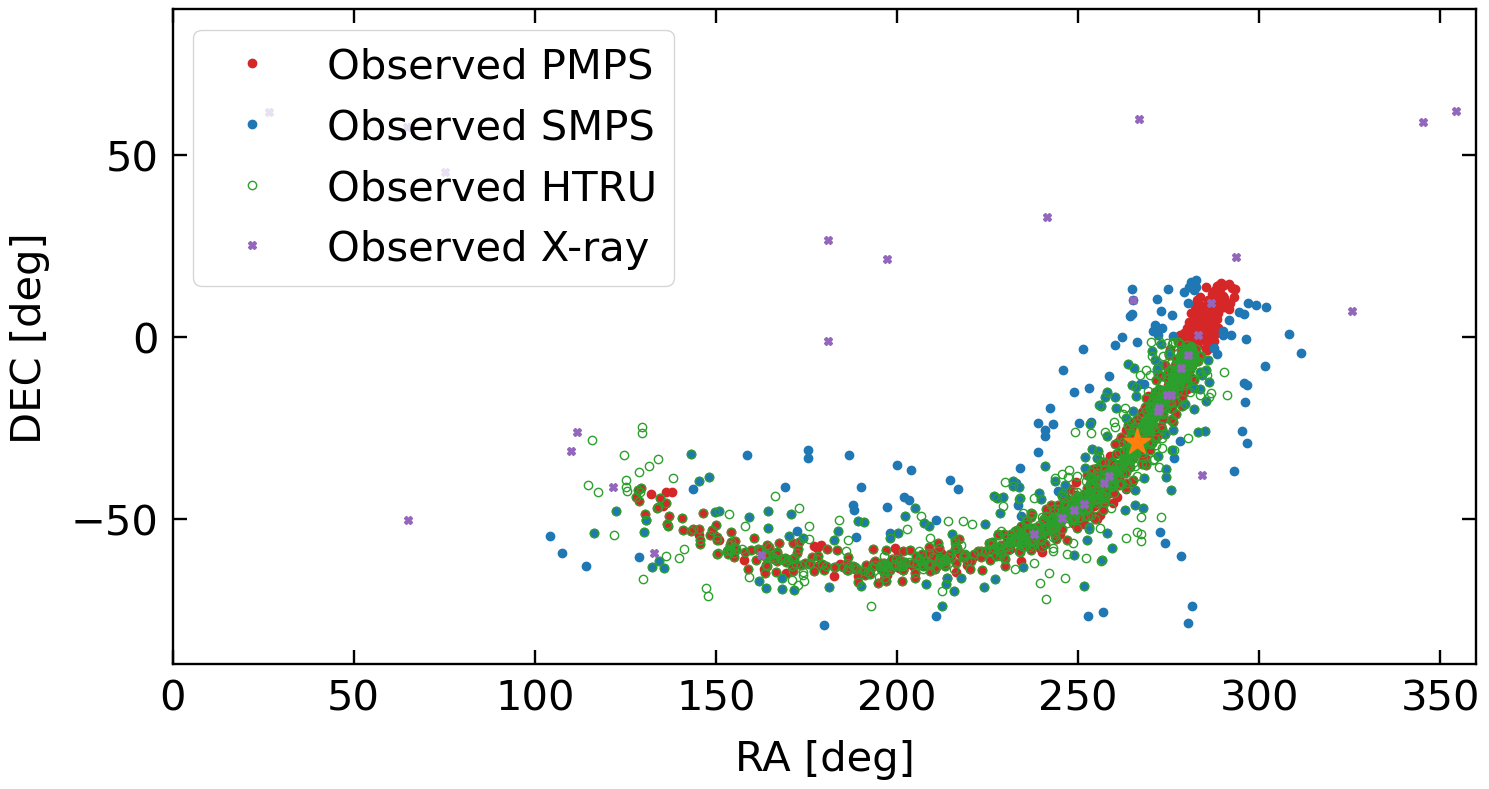

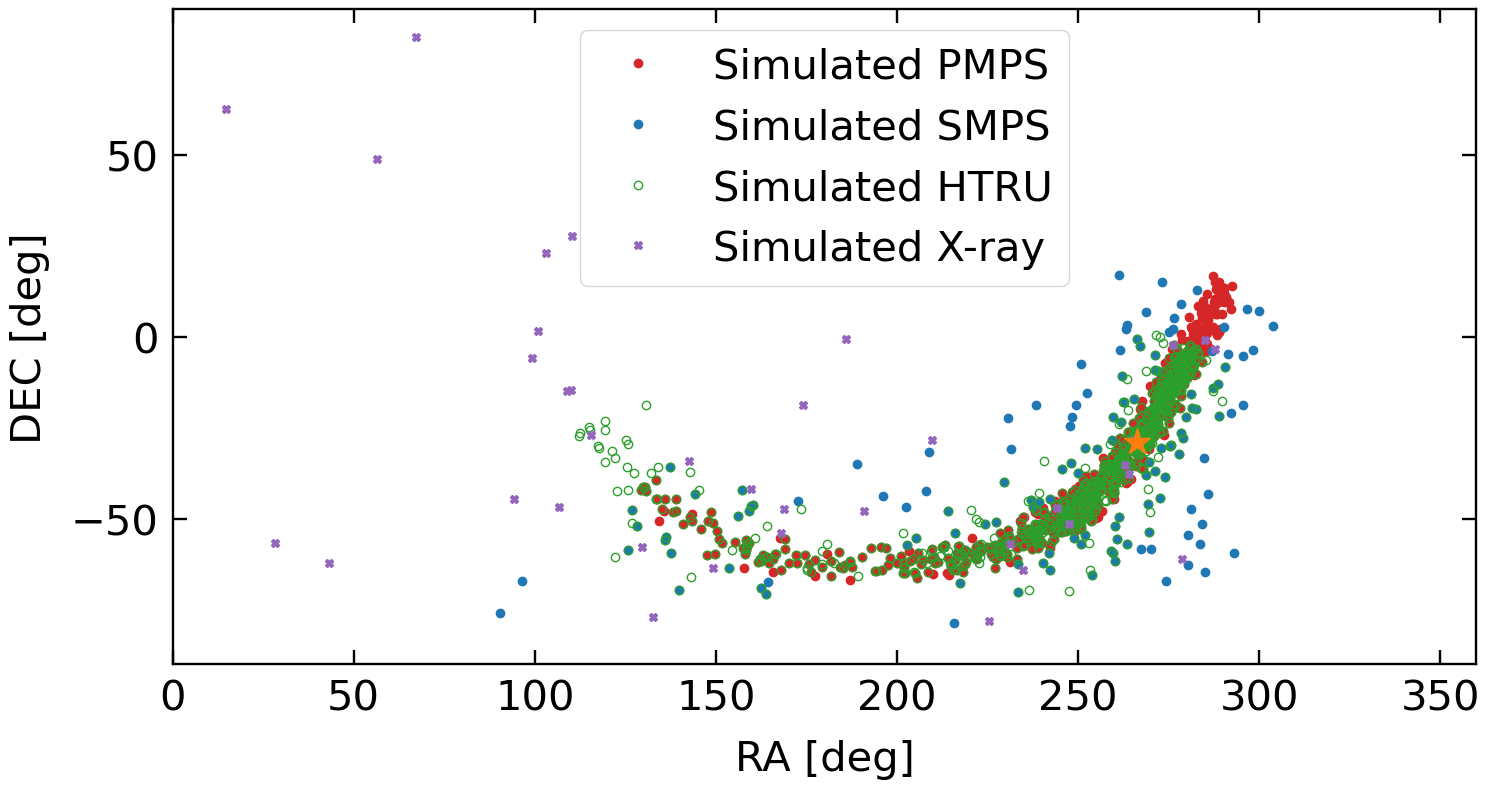

In [38]:
RA_galcen = 266.4
DEC_galcen = -29.0

fig, ax = plt.subplots(figsize=(15, 8))

ax.plot(
    RA_pk_obs,
    DEC_pk_obs,
    linestyle="None",
    marker="o",
    color="tab:red",
    markersize=6,
    alpha=1,
    rasterized=True,
    label=r"Observed PMPS",
)
ax.plot(
    RA_sw_obs,
    DEC_sw_obs,
    linestyle="None",
    marker="o",
    color="tab:blue",
    markersize=6,
    alpha=1,
    rasterized=True,
    label=r"Observed SMPS",
)

ax.plot(
    RA_htru_obs,
    DEC_htru_obs,
    linestyle="None",
    marker="o",
    fillstyle="none",
    color="tab:green",
    markersize=6,
    alpha=1,
    rasterized=True,
    label=r"Observed HTRU",
)
if survey_x:
    ax.plot(
        RA_x_obs,
        DEC_x_obs,
        linestyle="None",
        marker="X",
        color="tab:purple",
        markersize=6,
        rasterized=True,
        label=r"Observed X-ray",
    )

ax.plot(RA_galcen, DEC_galcen, marker="*", color="tab:orange", markersize=20)
ax.set_xlim(0.0, 360.0)
ax.set_ylim(-90.0, 90.0)
ax.set_xlabel("RA [deg]")
ax.set_ylabel("DEC [deg]")
ax.legend(frameon=True, loc=0)

fig, ax = plt.subplots(figsize=(15, 8))

ax.plot(
    RA_pk_sim,
    DEC_pk_sim,
    linestyle="None",
    marker="o",
    color="tab:red",
    markersize=6,
    alpha=1,
    rasterized=True,
    label=r"Simulated PMPS",
)
ax.plot(
    RA_sw_sim,
    DEC_sw_sim,
    linestyle="None",
    marker="o",
    color="tab:blue",
    markersize=6,
    alpha=1,
    rasterized=True,
    label=r"Simulated SMPS",
)

ax.plot(
    RA_htru_sim,
    DEC_htru_sim,
    linestyle="None",
    marker="o",
    fillstyle="none",
    color="tab:green",
    markersize=6,
    rasterized=True,
    label=r"Simulated HTRU",
)
if survey_x:
    ax.plot(
        RA_x_sim,
        DEC_x_sim,
        linestyle="None",
        marker="X",
        color="tab:purple",
        markersize=6,
        rasterized=True,
        label=r"Simulated X-ray",
    )

ax.plot(RA_galcen, DEC_galcen, marker="*", color="tab:orange", markersize=20)
ax.set_xlim(0.0, 360.0)
ax.set_ylim(-90.0, 90.0)
ax.set_xlabel("RA [deg]")
ax.set_ylabel("DEC [deg]")
ax.legend(frameon=True, loc=0)

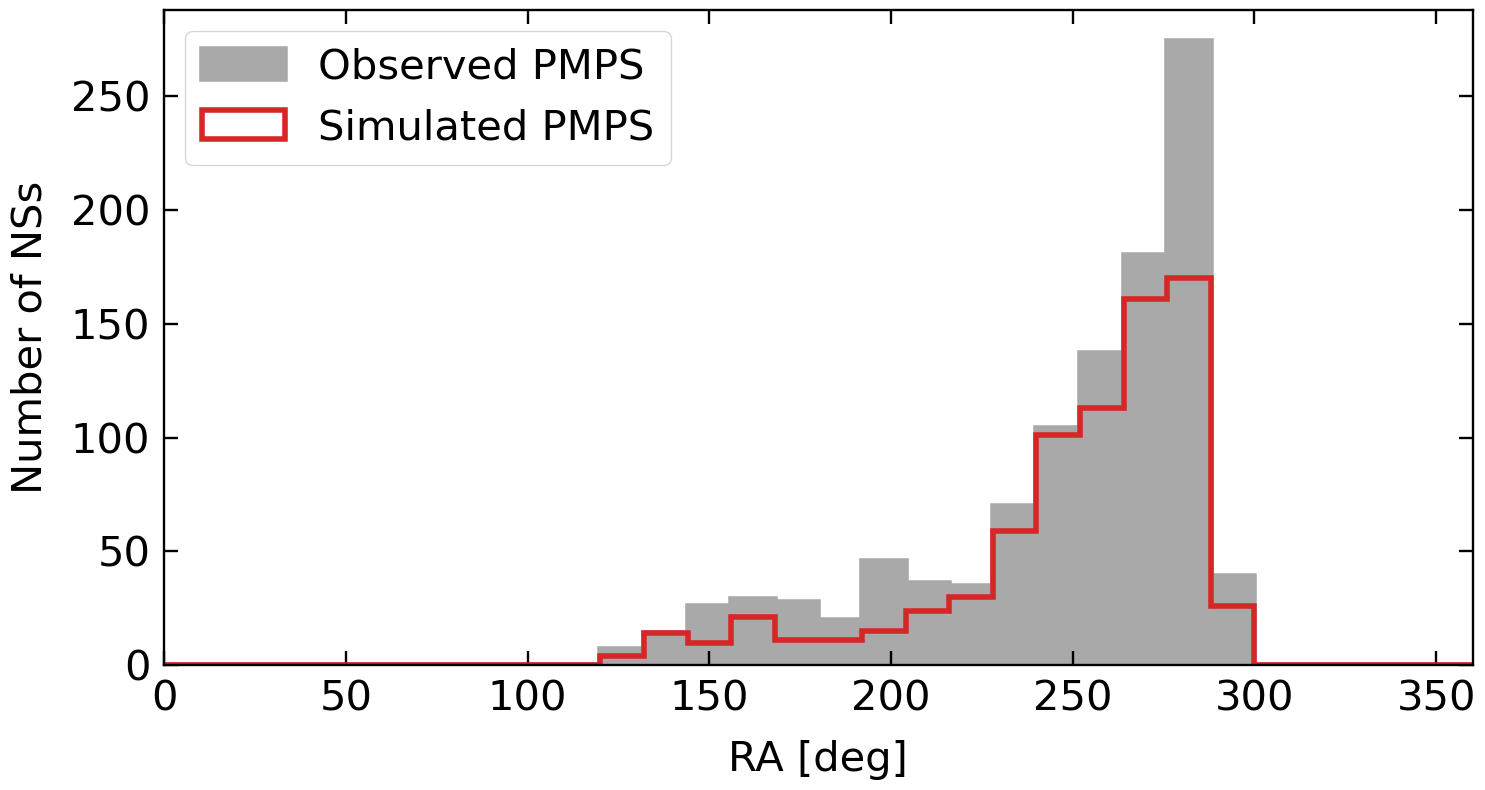

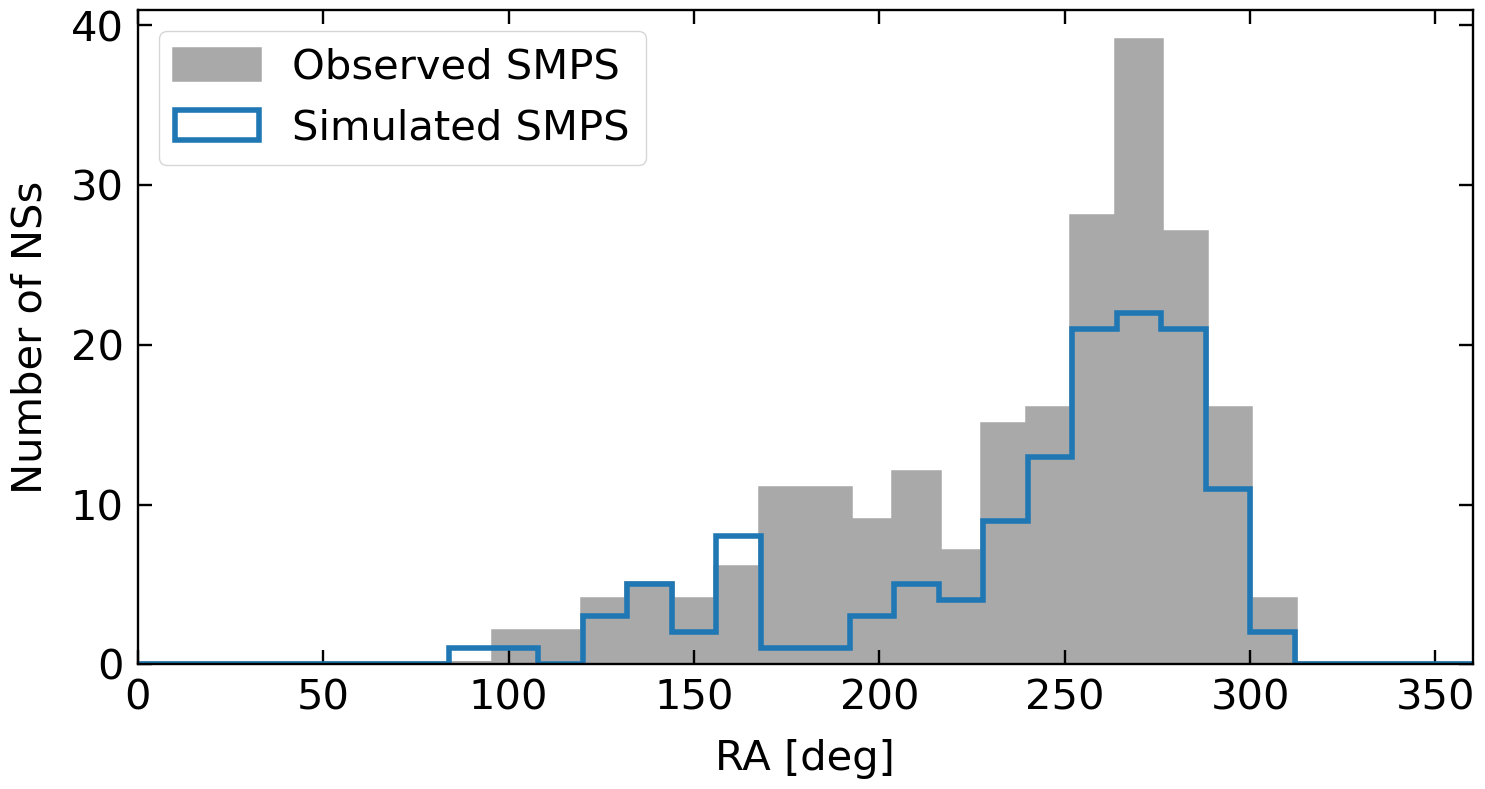

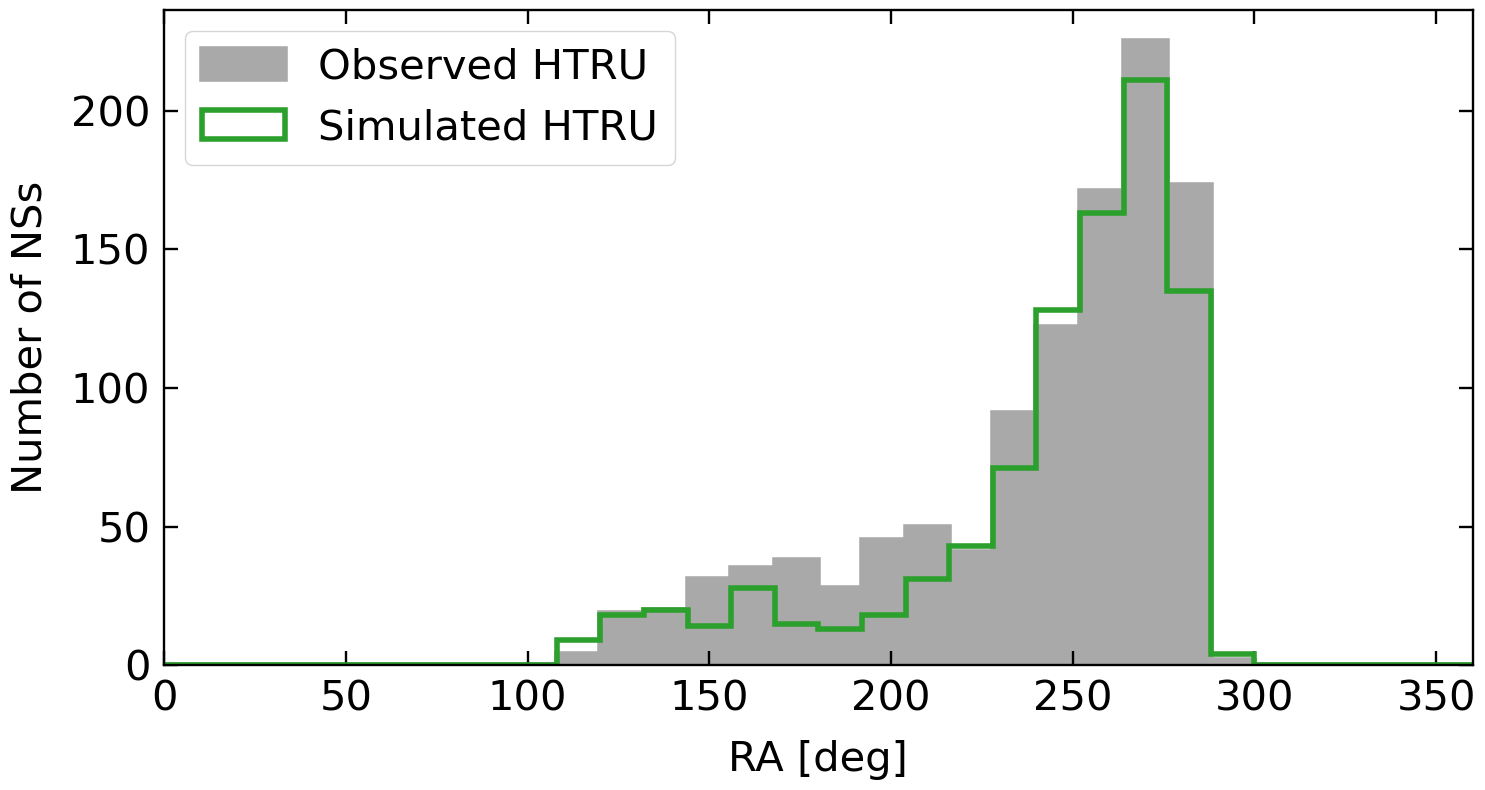

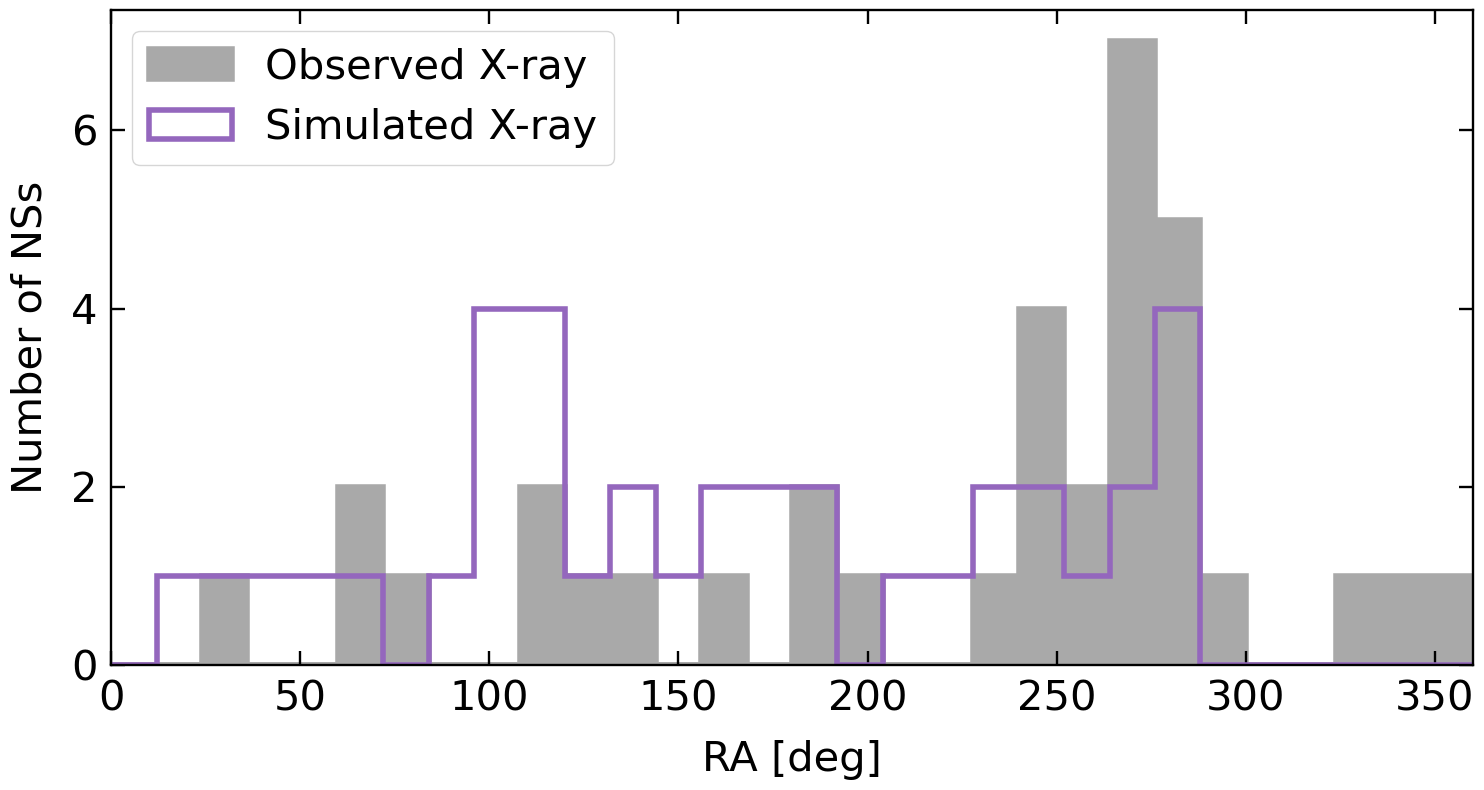

In [39]:
fig, ax = plt.subplots(figsize=(15, 8))

RA_edges = np.linspace(0.0, 360.0, 31)

ax.hist(
    RA_pk_obs,
    bins=RA_edges,
    histtype="stepfilled",
    edgecolor="darkgray",
    facecolor="darkgray",
    lw=4,
    alpha=1,
    label=r"Observed PMPS",
)
ax.hist(
    RA_pk_sim,
    bins=RA_edges,
    histtype="step",
    edgecolor="tab:red",
    lw=4,
    alpha=1,
    label=r"Simulated PMPS",
)


ax.set_xlabel(r"RA [deg]")
ax.set_ylabel(r"Number of NSs")
ax.set_xlim(0.0, 360.0)
ax.legend(frameon=True, loc=2)

plt.show()

fig, ax = plt.subplots(figsize=(15, 8))

RA_edges = np.linspace(0.0, 360.0, 31)

ax.hist(
    RA_sw_obs,
    bins=RA_edges,
    histtype="stepfilled",
    edgecolor="darkgray",
    facecolor="darkgray",
    lw=4,
    alpha=1,
    label=r"Observed SMPS",
)
ax.hist(
    RA_sw_sim,
    bins=RA_edges,
    histtype="step",
    edgecolor="tab:blue",
    lw=4,
    alpha=1,
    label=r"Simulated SMPS",
)
ax.set_xlabel(r"RA [deg]")
ax.set_ylabel(r"Number of NSs")
ax.set_xlim(0.0, 360.0)
ax.legend(frameon=True, loc=2)

plt.show()


fig, ax = plt.subplots(figsize=(15, 8))

RA_edges = np.linspace(0.0, 360.0, 31)

ax.hist(
    RA_htru_obs,
    bins=RA_edges,
    histtype="stepfilled",
    edgecolor="darkgray",
    facecolor="darkgray",
    lw=4,
    alpha=1,
    label=r"Observed HTRU",
)
ax.hist(
    RA_htru_sim,
    bins=RA_edges,
    histtype="step",
    edgecolor="tab:green",
    lw=4,
    alpha=1,
    label=r"Simulated HTRU",
)
ax.set_xlabel(r"RA [deg]")
ax.set_ylabel(r"Number of NSs")
ax.set_xlim(0.0, 360.0)
ax.legend(frameon=True, loc=2)

plt.show()

if survey_x:
    fig, ax = plt.subplots(figsize=(15, 8))

    RA_edges = np.linspace(0.0, 360.0, 31)

    ax.hist(
        RA_x_obs,
        bins=RA_edges,
        histtype="stepfilled",
        edgecolor="darkgray",
        facecolor="darkgray",
        lw=4,
        alpha=1,
        label=r"Observed X-ray",
    )
    ax.hist(
        RA_x_sim,
        bins=RA_edges,
        histtype="step",
        edgecolor="tab:purple",
        lw=4,
        alpha=1,
        label=r"Simulated X-ray",
    )
    ax.set_xlabel(r"RA [deg]")
    ax.set_ylabel(r"Number of NSs")
    ax.set_xlim(0.0, 360.0)
    ax.legend(frameon=True, loc=2)

    plt.show()

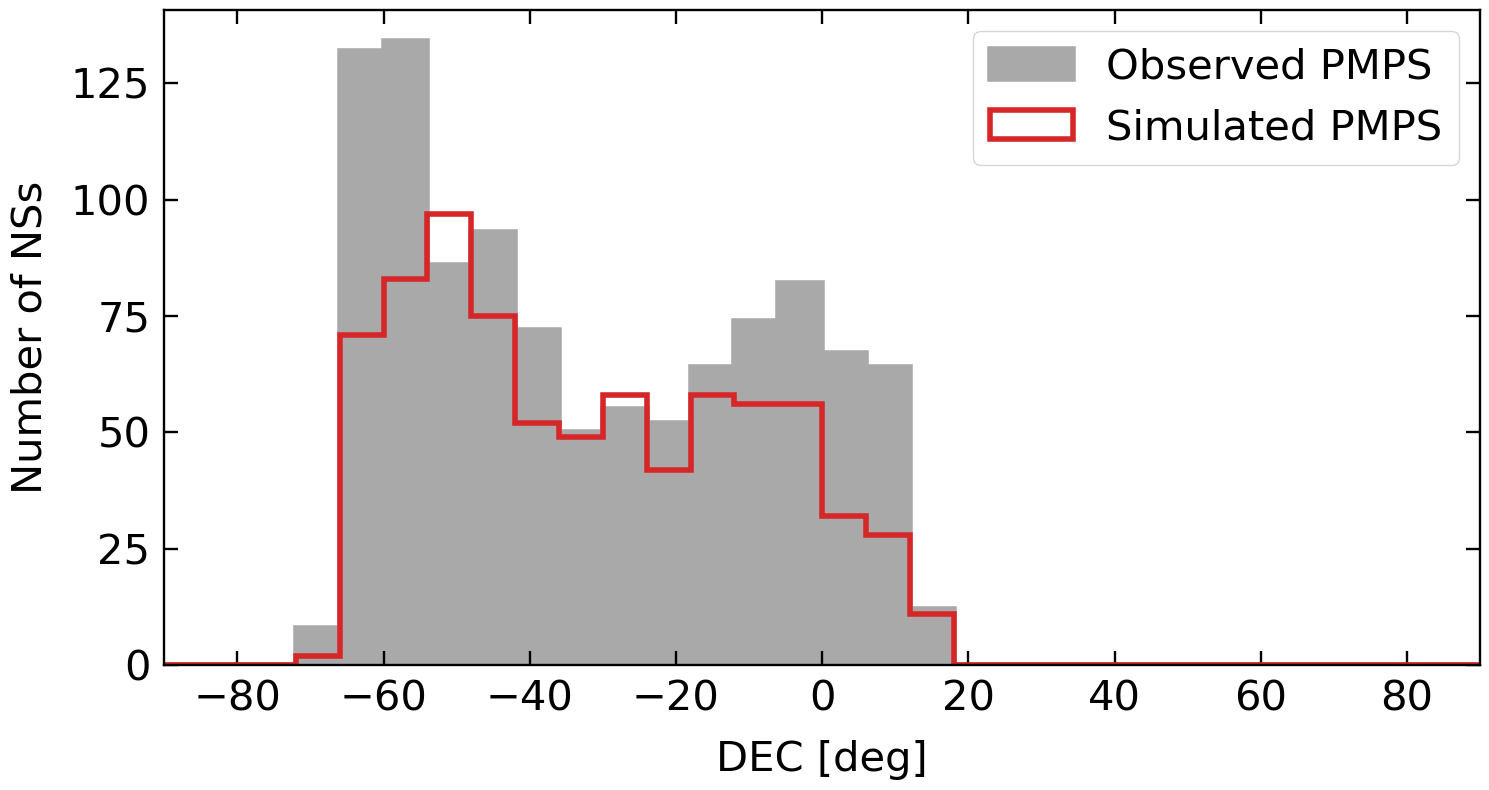

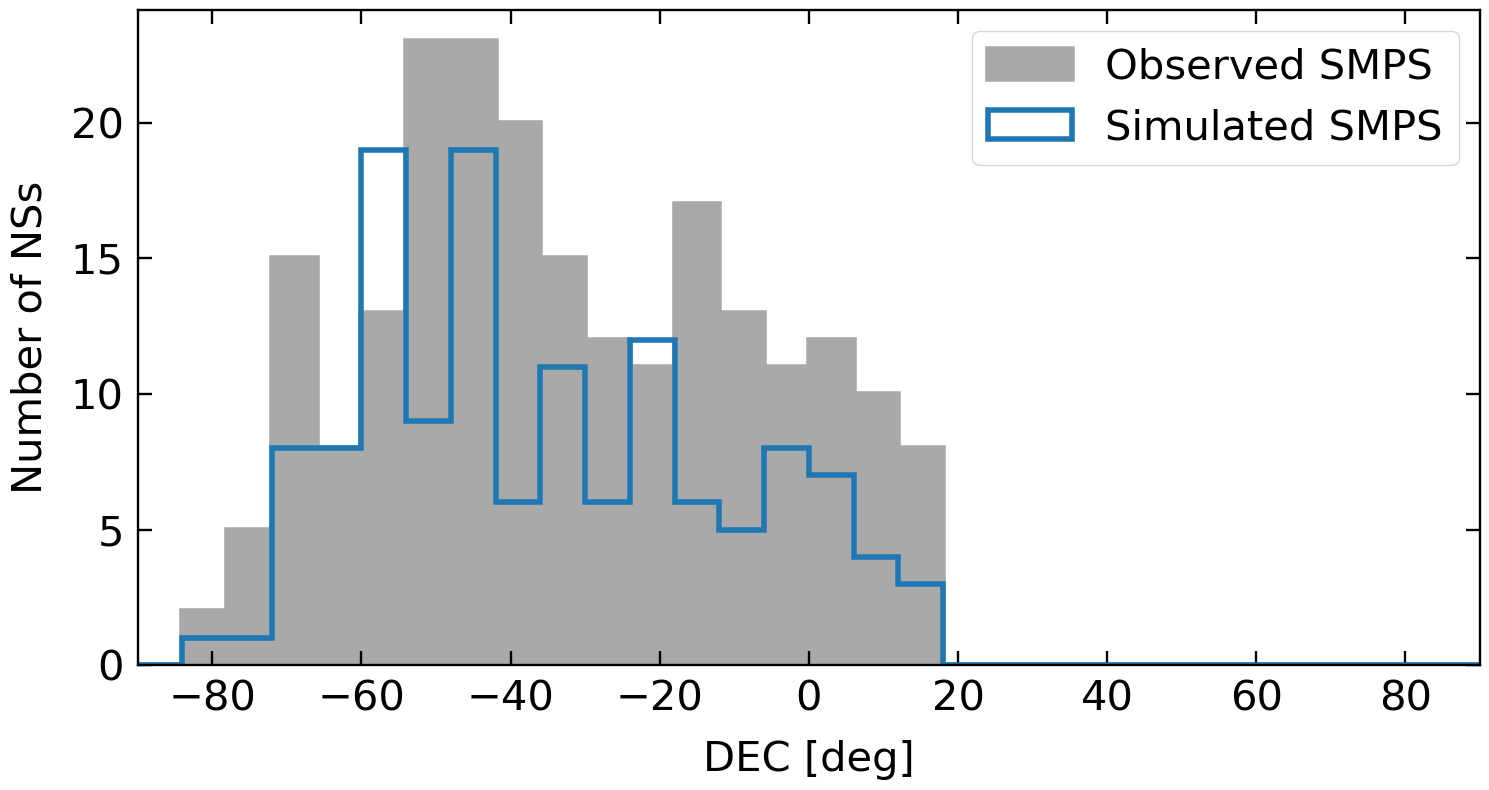

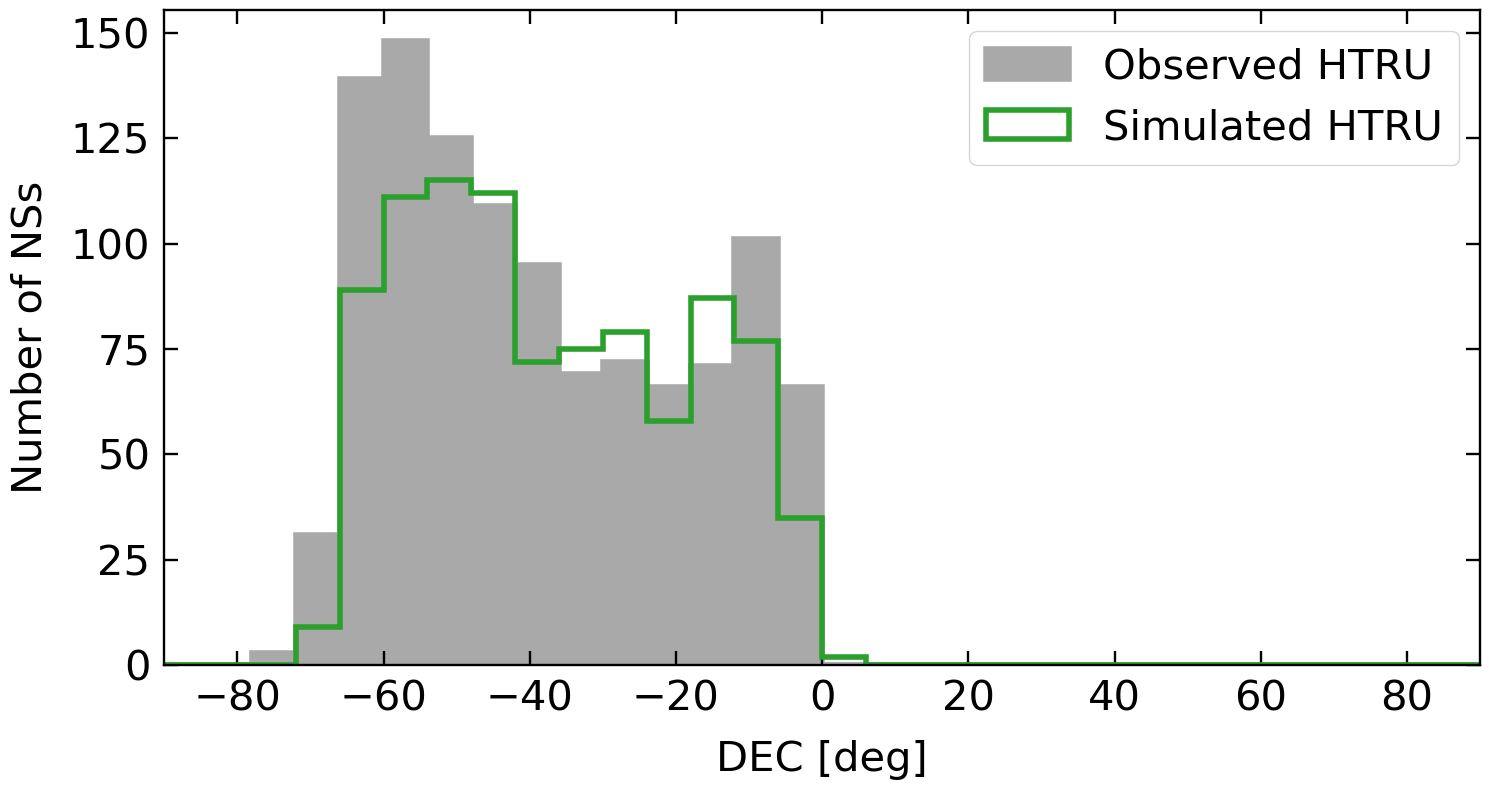

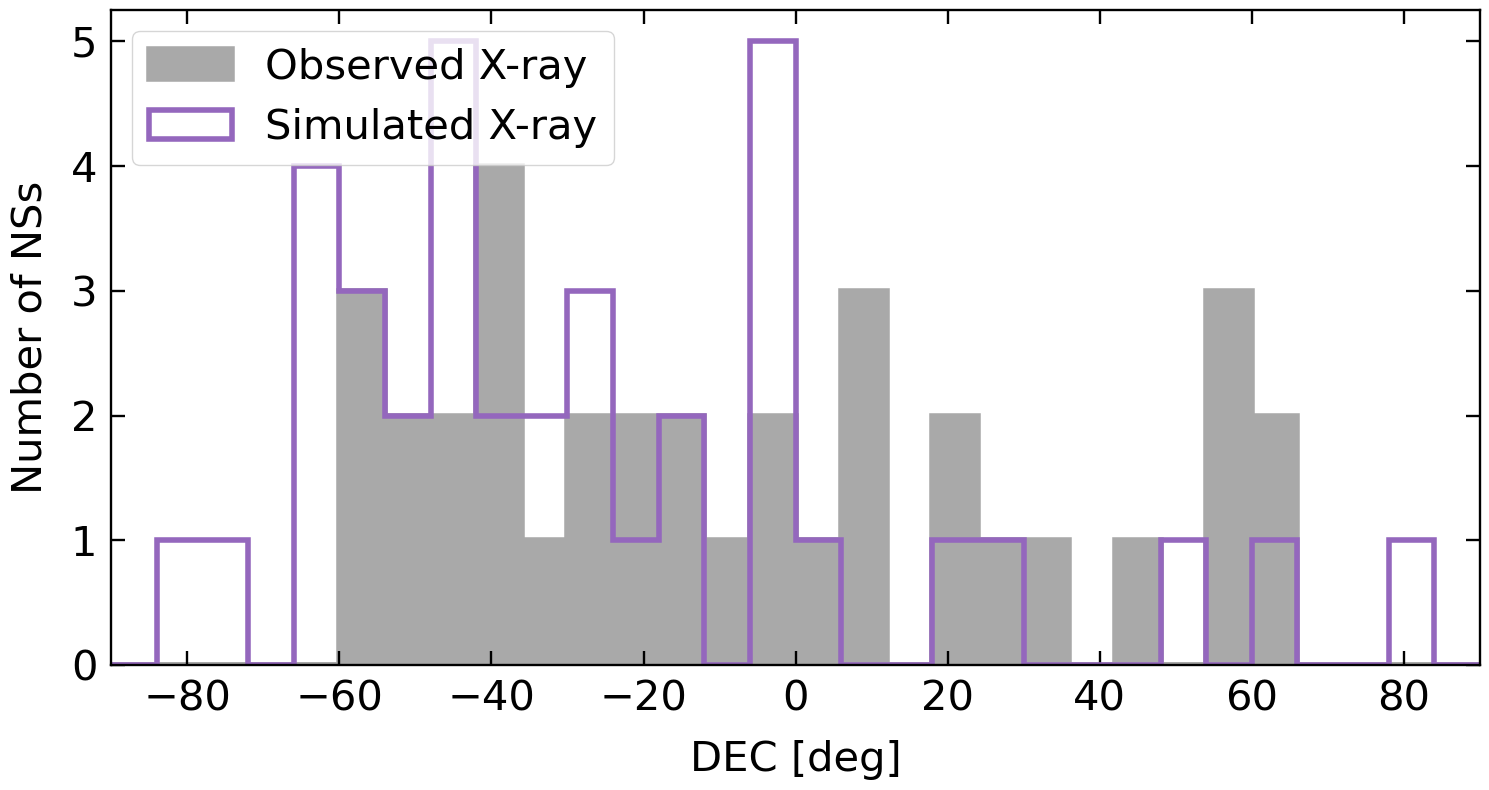

In [40]:
fig, ax = plt.subplots(figsize=(15, 8))

DEC_edges = np.linspace(-90.0, 90.0, 31)

ax.hist(
    DEC_pk_obs,
    bins=DEC_edges,
    histtype="stepfilled",
    edgecolor="darkgray",
    facecolor="darkgray",
    lw=4,
    alpha=1,
    label=r"Observed PMPS",
)
ax.hist(
    DEC_pk_sim,
    bins=DEC_edges,
    histtype="step",
    edgecolor="tab:red",
    lw=4,
    alpha=1,
    label=r"Simulated PMPS",
)
ax.set_xlabel(r"DEC [deg]")
ax.set_ylabel(r"Number of NSs")
ax.set_xlim(-90.0, 90.0)
ax.legend(frameon=True, loc=0)

plt.show()

fig, ax = plt.subplots(figsize=(15, 8))

DEC_edges = np.linspace(-90.0, 90.0, 31)

ax.hist(
    DEC_sw_obs,
    bins=DEC_edges,
    histtype="stepfilled",
    edgecolor="darkgray",
    facecolor="darkgray",
    lw=4,
    alpha=1,
    label=r"Observed SMPS",
)
ax.hist(
    DEC_sw_sim,
    bins=DEC_edges,
    histtype="step",
    edgecolor="tab:blue",
    lw=4,
    alpha=1,
    label=r"Simulated SMPS",
)
ax.set_xlabel(r"DEC [deg]")
ax.set_ylabel(r"Number of NSs")
ax.set_xlim(-90.0, 90.0)
ax.legend(frameon=True, loc=0)

plt.show()

fig, ax = plt.subplots(figsize=(15, 8))

DEC_edges = np.linspace(-90.0, 90.0, 31)

ax.hist(
    DEC_htru_obs,
    bins=DEC_edges,
    histtype="stepfilled",
    edgecolor="darkgray",
    facecolor="darkgray",
    lw=4,
    alpha=1,
    label=r"Observed HTRU",
)
ax.hist(
    DEC_htru_sim,
    bins=DEC_edges,
    histtype="step",
    edgecolor="tab:green",
    lw=4,
    alpha=1,
    label=r"Simulated HTRU",
)
ax.set_xlabel(r"DEC [deg]")
ax.set_ylabel(r"Number of NSs")
ax.set_xlim(-90.0, 90.0)
ax.legend(frameon=True, loc=0)

plt.show()

if survey_x:
    fig, ax = plt.subplots(figsize=(15, 8))

    DEC_edges = np.linspace(-90.0, 90.0, 31)

    ax.hist(
        DEC_x_obs,
        bins=DEC_edges,
        histtype="stepfilled",
        edgecolor="darkgray",
        facecolor="darkgray",
        lw=4,
        alpha=1,
        label=r"Observed X-ray",
    )
    ax.hist(
        DEC_x_sim,
        bins=DEC_edges,
        histtype="step",
        edgecolor="tab:purple",
        lw=4,
        alpha=1,
        label=r"Simulated X-ray",
    )
    ax.set_xlabel(r"DEC [deg]")
    ax.set_ylabel(r"Number of NSs")
    ax.set_xlim(-90.0, 90.0)
    ax.legend(frameon=True, loc=2)

    plt.show()

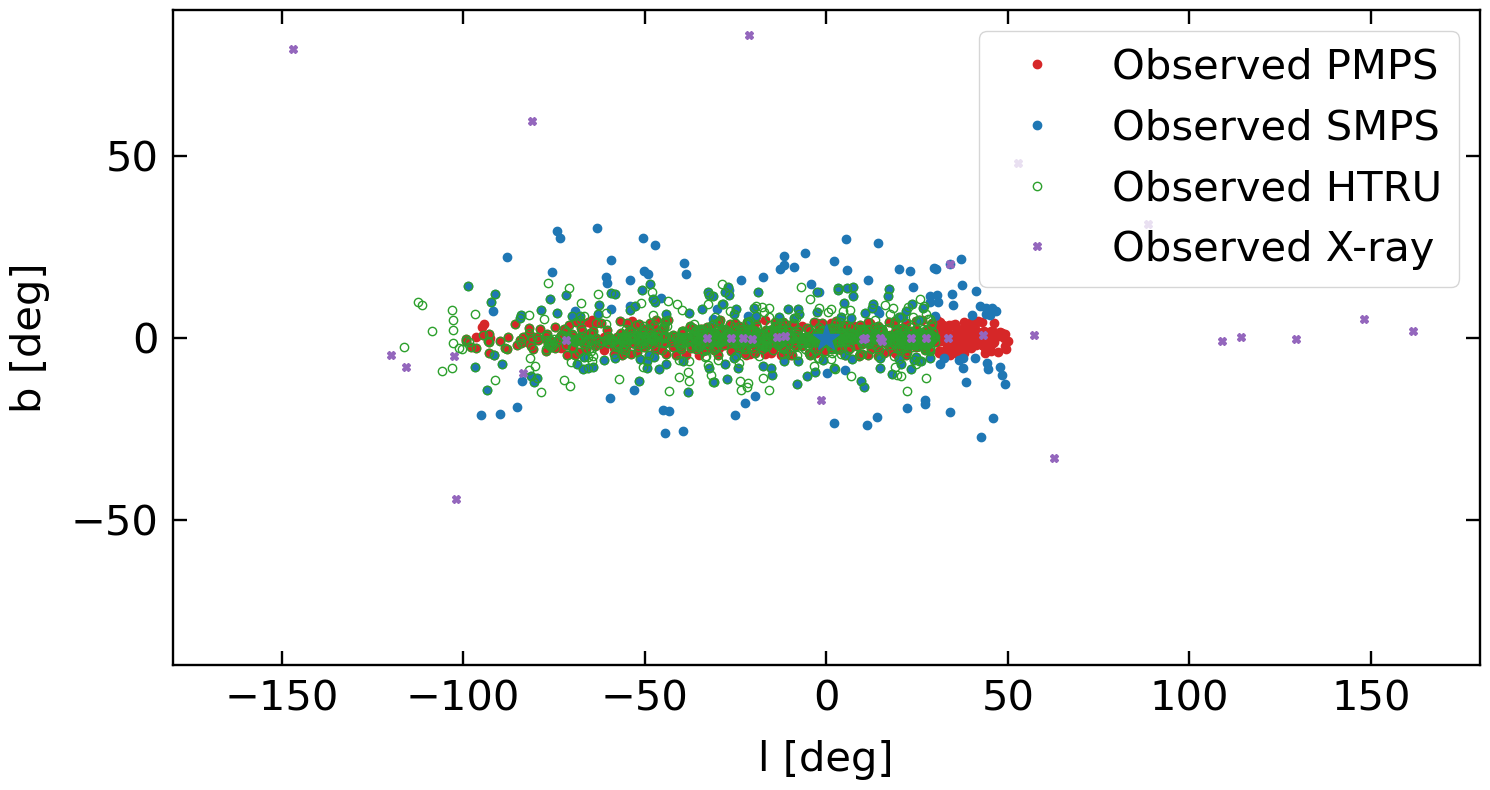

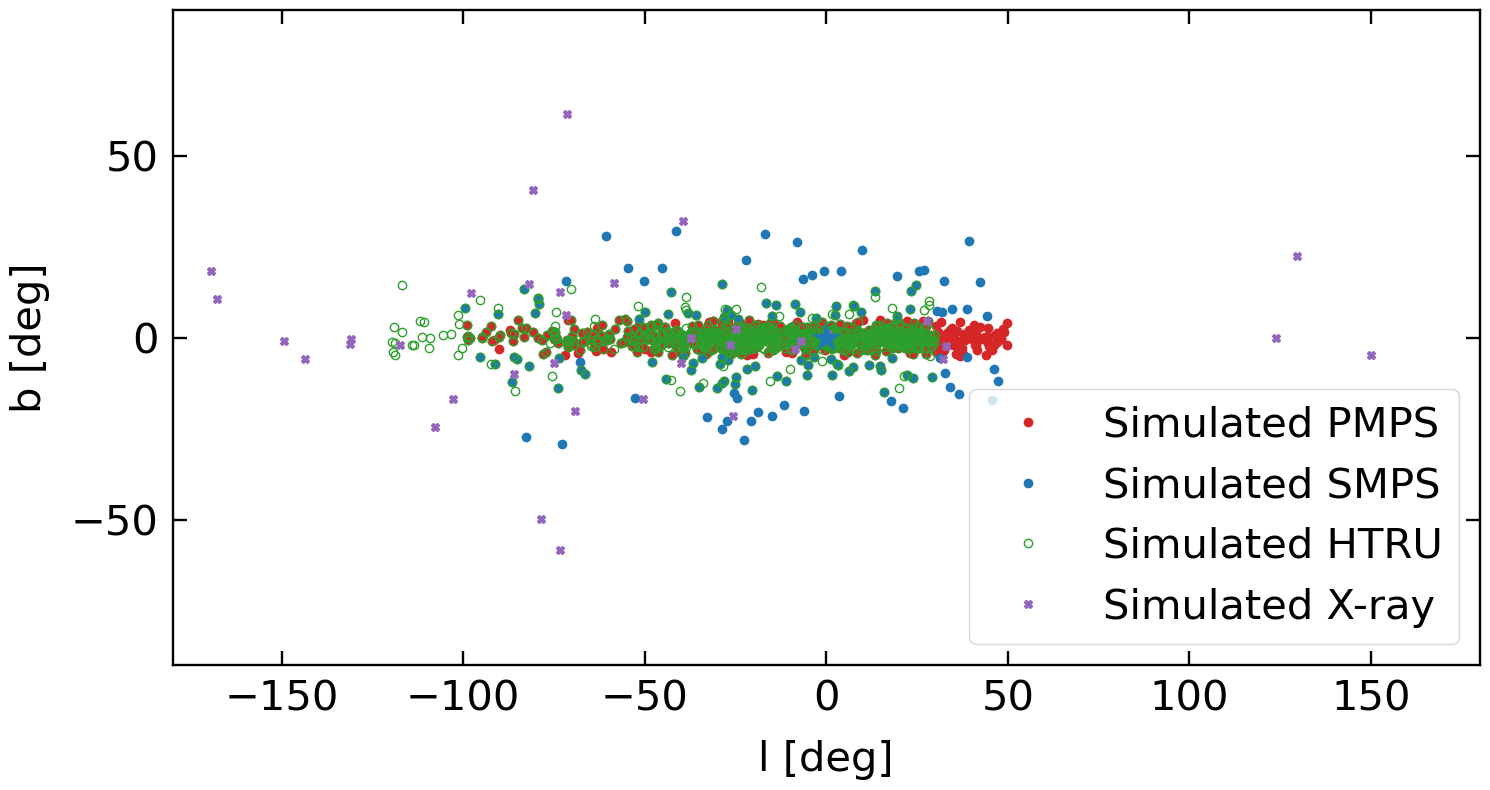

In [41]:
fig, ax = plt.subplots(figsize=(15, 8))

ax.plot(
    l_pk_obs,
    b_pk_obs,
    linestyle="None",
    marker="o",
    color="tab:red",
    markersize=6,
    alpha=1,
    rasterized=True,
    label=r"Observed PMPS",
)
ax.plot(
    l_sw_obs,
    b_sw_obs,
    linestyle="None",
    marker="o",
    color="tab:blue",
    markersize=6,
    alpha=1,
    rasterized=True,
    label=r"Observed SMPS",
)
ax.plot(
    l_htru_obs,
    b_htru_obs,
    linestyle="None",
    marker="o",
    fillstyle="none",
    color="tab:green",
    markersize=6,
    alpha=1,
    rasterized=True,
    label=r"Observed HTRU",
)

if survey_x:
    ax.plot(
        l_x_obs,
        b_x_obs,
        linestyle="None",
        marker="X",
        color="tab:purple",
        markersize=6,
        alpha=1,
        rasterized=True,
        label=r"Observed X-ray",
    )

ax.plot(0.0, 0.0, marker="*", color="tab:blue", markersize=20)
ax.set_xlim(-180.0, 180.0)
ax.set_ylim(-90.0, 90.0)
ax.set_xlabel("l [deg]")
ax.set_ylabel("b [deg]")
ax.legend(frameon=True, loc=0)

plt.show()

fig, ax = plt.subplots(figsize=(15, 8))

ax.plot(
    l_pk_sim,
    b_pk_sim,
    linestyle="None",
    marker="o",
    color="tab:red",
    markersize=6,
    alpha=1,
    rasterized=True,
    label=r"Simulated PMPS",
)
ax.plot(
    l_sw_sim,
    b_sw_sim,
    linestyle="None",
    marker="o",
    color="tab:blue",
    markersize=6,
    alpha=1,
    rasterized=True,
    label=r"Simulated SMPS",
)
ax.plot(
    l_htru_sim,
    b_htru_sim,
    linestyle="None",
    marker="o",
    fillstyle="none",
    color="tab:green",
    markersize=6,
    alpha=1,
    rasterized=True,
    label=r"Simulated HTRU",
)

if survey_x:
    ax.plot(
        l_x_sim,
        b_x_sim,
        linestyle="None",
        marker="X",
        color="tab:purple",
        markersize=6,
        rasterized=True,
        label=r"Simulated X-ray",
    )

ax.plot(0.0, 0.0, marker="*", color="tab:blue", markersize=20)
ax.set_xlim(-180.0, 180.0)
ax.set_ylim(-90.0, 90.0)
ax.set_xlabel("l [deg]")
ax.set_ylabel("b [deg]")
ax.legend(frameon=True, loc=0)

plt.show()

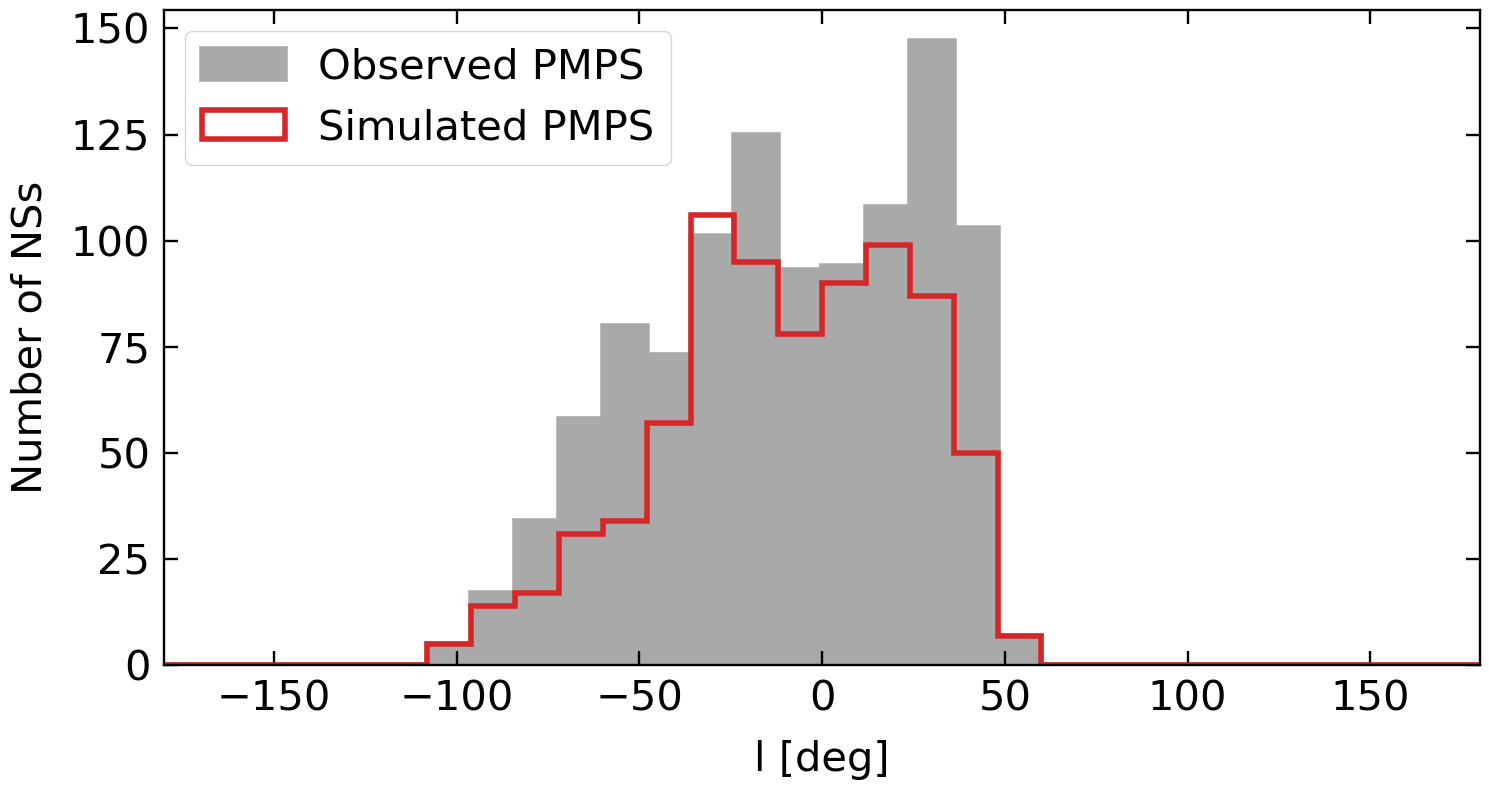

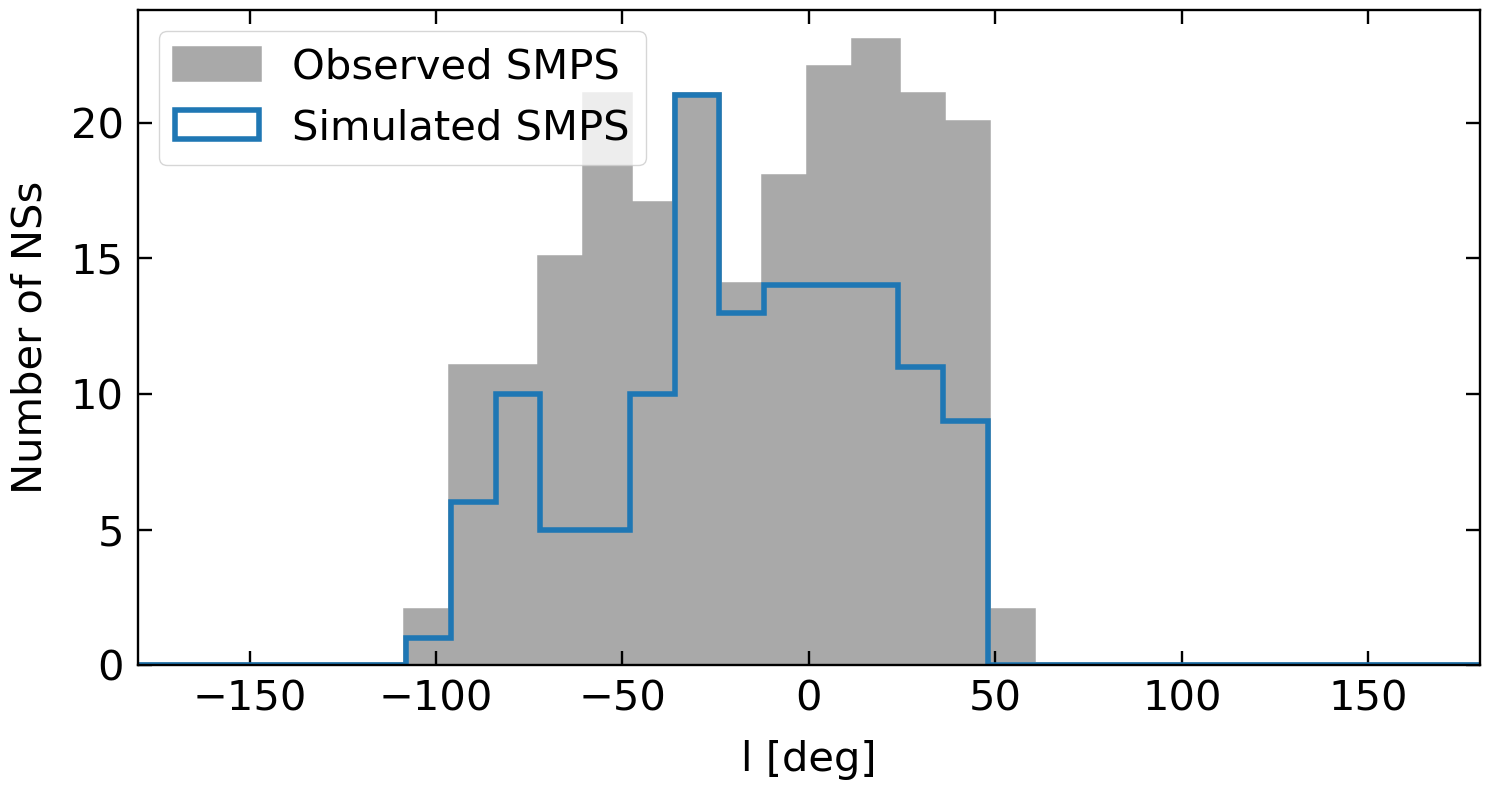

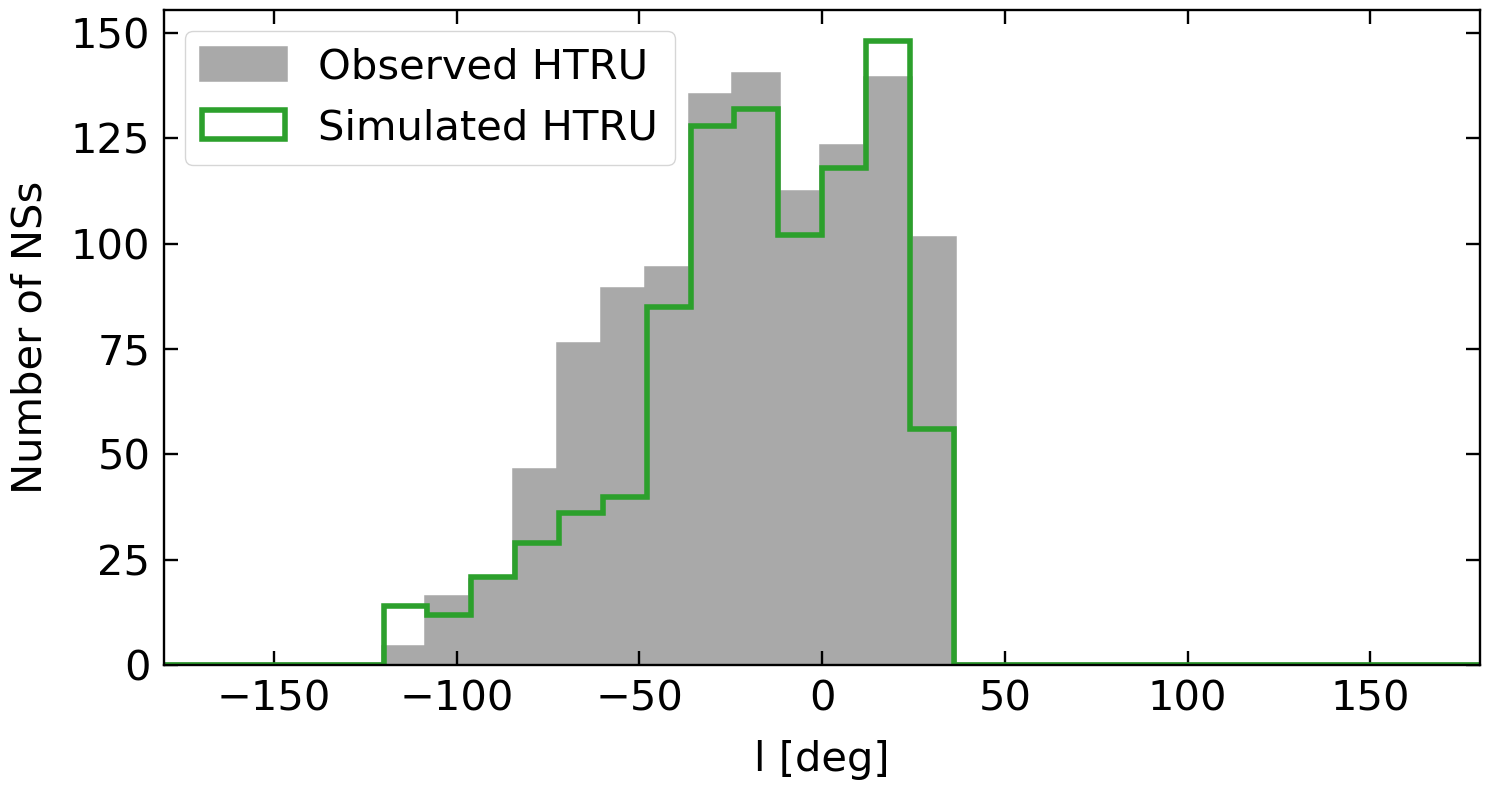

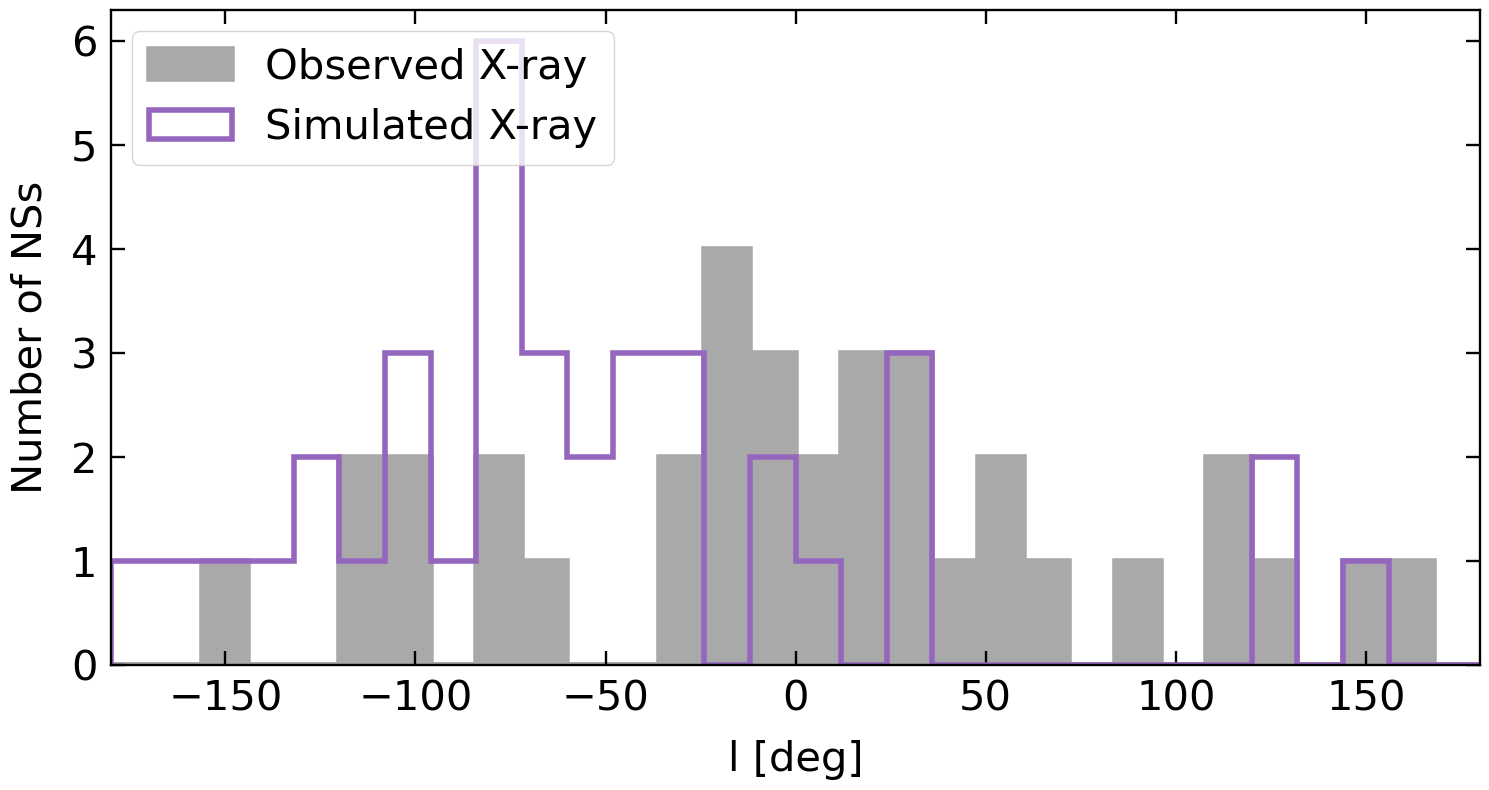

In [42]:
l_edges = np.linspace(-180.0, 180.0, 31)

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    l_pk_obs,
    bins=l_edges,
    histtype="stepfilled",
    edgecolor="darkgray",
    facecolor="darkgray",
    lw=4,
    alpha=1,
    label=r"Observed PMPS",
)
ax.hist(
    l_pk_sim,
    bins=l_edges,
    histtype="step",
    edgecolor="tab:red",
    lw=4,
    alpha=1,
    label=r"Simulated PMPS",
)
ax.set_xlabel(r"l [deg]")
ax.set_ylabel(r"Number of NSs")
ax.set_xlim(-180.0, 180.0)
ax.legend(frameon=True, loc=2)

plt.show()

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    l_sw_obs,
    bins=l_edges,
    histtype="stepfilled",
    edgecolor="darkgray",
    facecolor="darkgray",
    lw=4,
    alpha=1,
    label=r"Observed SMPS",
)
ax.hist(
    l_sw_sim,
    bins=l_edges,
    histtype="step",
    edgecolor="tab:blue",
    lw=4,
    alpha=1,
    label=r"Simulated SMPS",
)
ax.set_xlabel(r"l [deg]")
ax.set_ylabel(r"Number of NSs")
ax.set_xlim(-180.0, 180.0)
ax.legend(frameon=True, loc=2)

plt.show()


fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    l_htru_obs,
    bins=l_edges,
    histtype="stepfilled",
    edgecolor="darkgray",
    facecolor="darkgray",
    lw=4,
    alpha=1,
    label=r"Observed HTRU",
)
ax.hist(
    l_htru_sim,
    bins=l_edges,
    histtype="step",
    edgecolor="tab:green",
    lw=4,
    alpha=1,
    label=r"Simulated HTRU",
)
ax.set_xlabel(r"l [deg]")
ax.set_ylabel(r"Number of NSs")
ax.set_xlim(-180.0, 180.0)
ax.legend(frameon=True, loc=2)

plt.show()

if survey_x:
    fig, ax = plt.subplots(figsize=(15, 8))

    ax.hist(
        l_x_obs,
        bins=l_edges,
        histtype="stepfilled",
        edgecolor="darkgray",
        facecolor="darkgray",
        lw=4,
        alpha=1,
        label=r"Observed X-ray",
    )
    ax.hist(
        l_x_sim,
        bins=l_edges,
        histtype="step",
        edgecolor="tab:purple",
        lw=4,
        alpha=1,
        label=r"Simulated X-ray",
    )
    ax.set_xlabel(r"l [deg]")
    ax.set_ylabel(r"Number of NSs")
    ax.set_xlim(-180.0, 180.0)
    ax.legend(frameon=True, loc=2)

    plt.show()

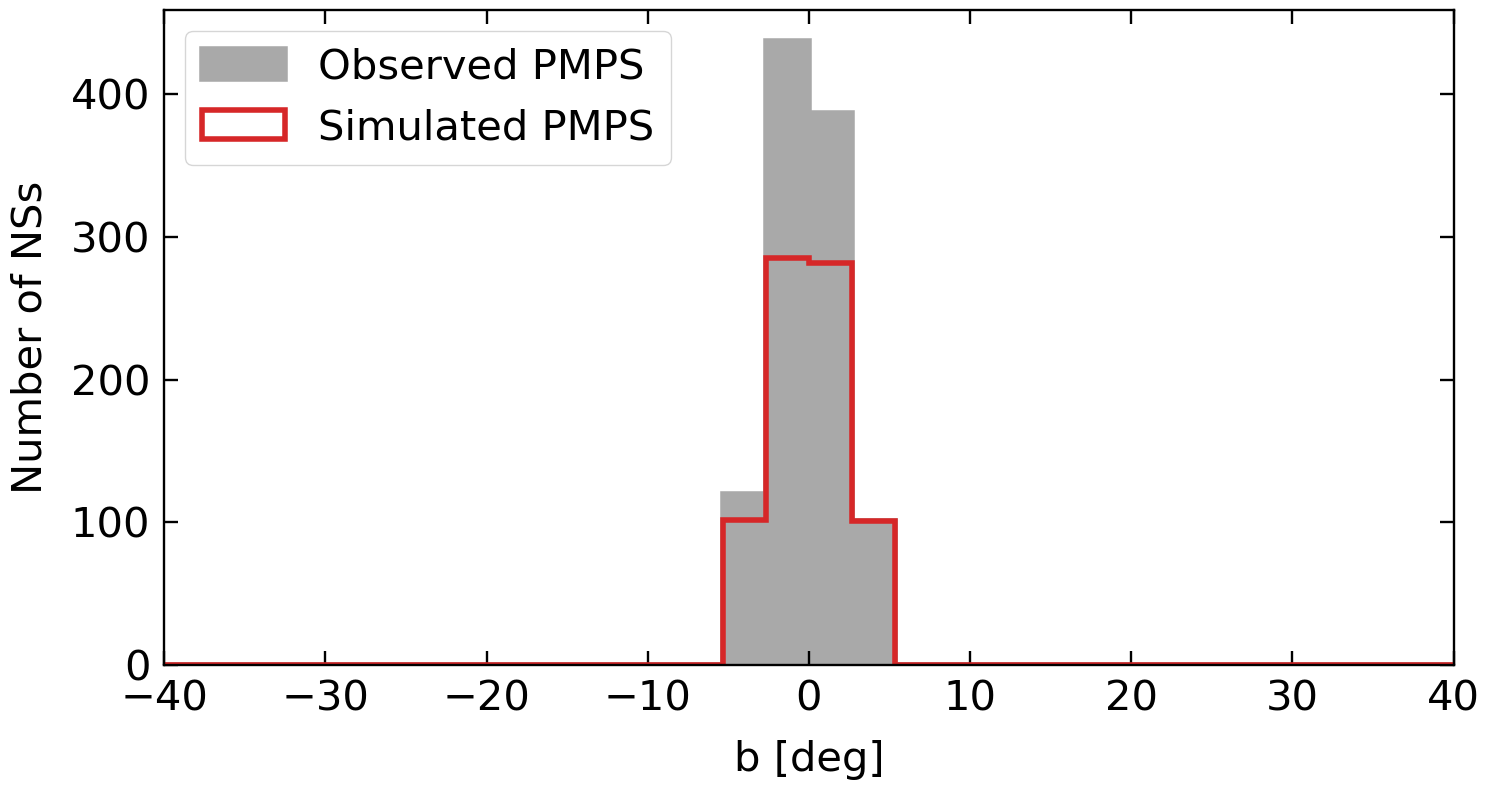

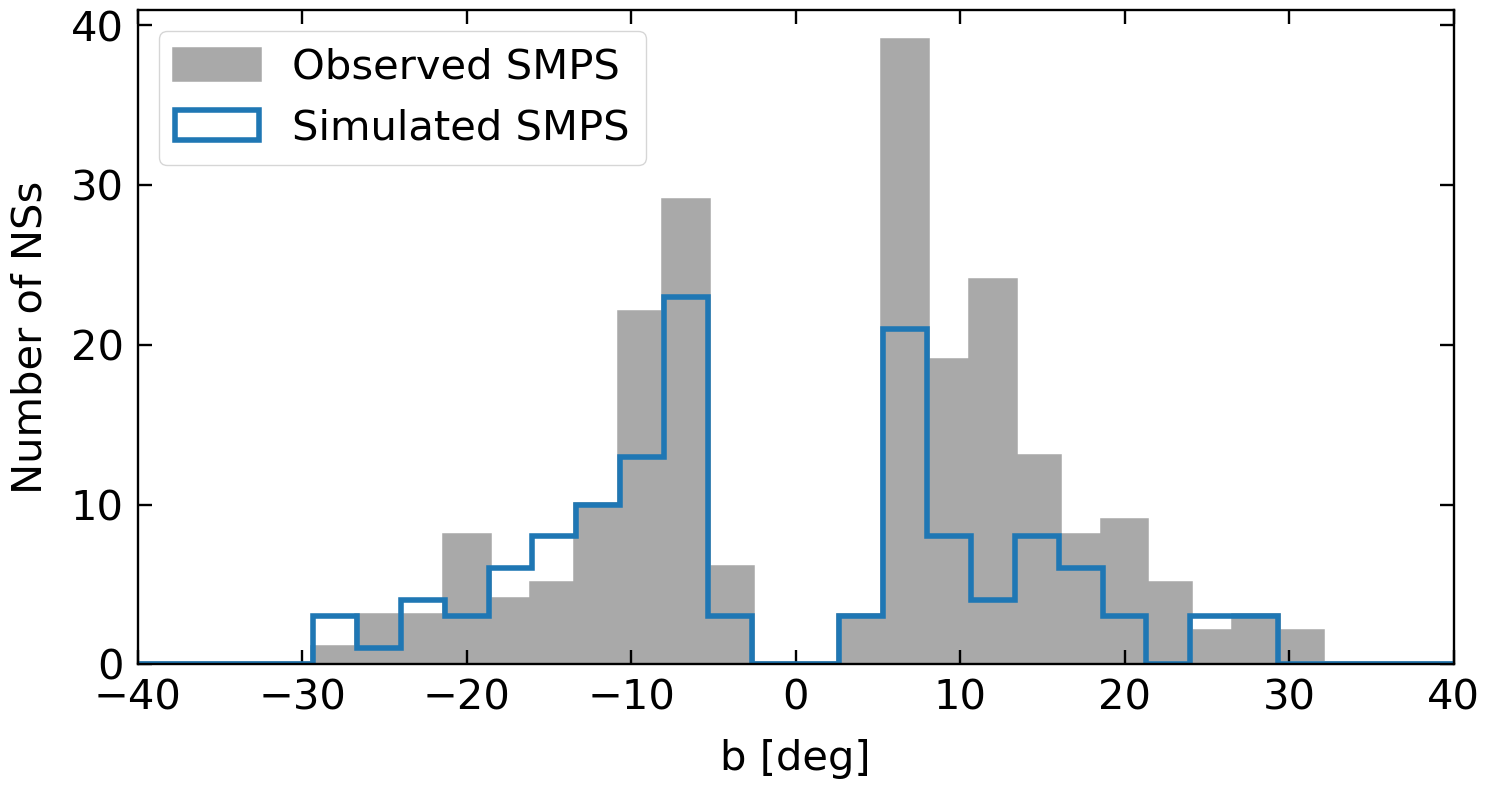

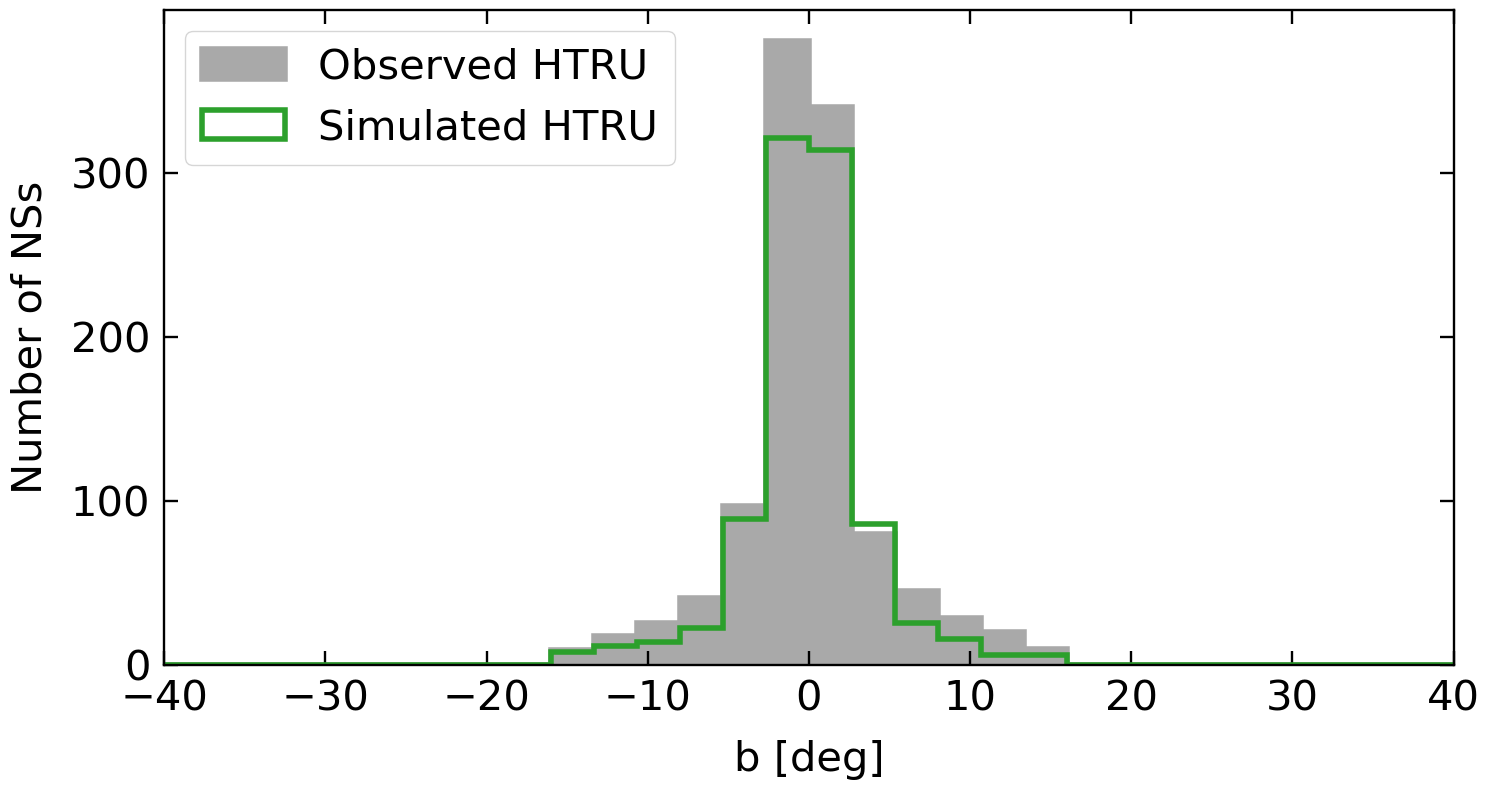

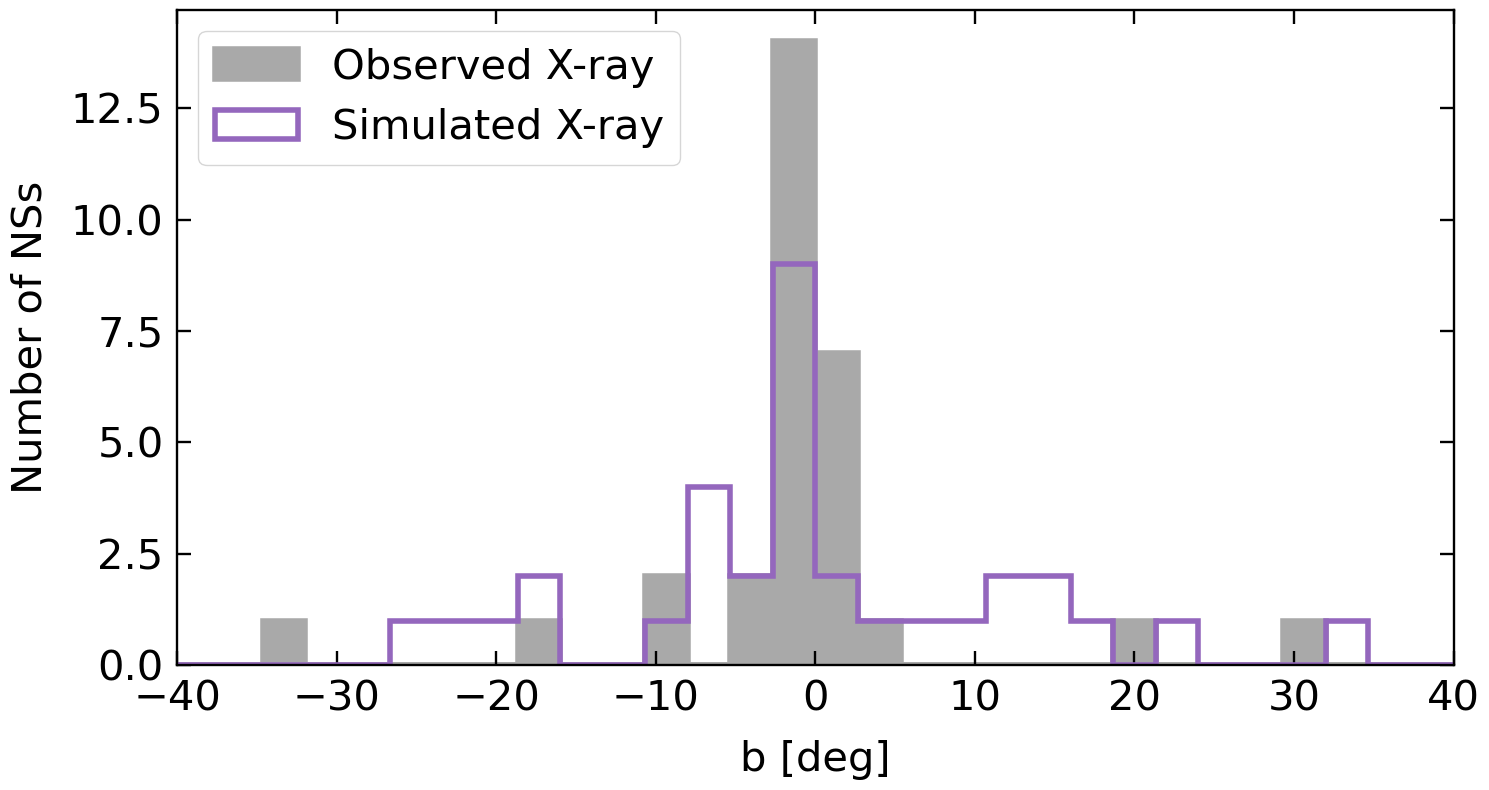

In [43]:
b_edges = np.linspace(-40.0, 40.0, 31)

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    b_pk_obs,
    bins=b_edges,
    histtype="stepfilled",
    edgecolor="darkgray",
    facecolor="darkgray",
    lw=4,
    alpha=1,
    label=r"Observed PMPS",
)
ax.hist(
    b_pk_sim,
    bins=b_edges,
    histtype="step",
    edgecolor="tab:red",
    lw=4,
    alpha=1,
    label=r"Simulated PMPS",
)
ax.set_xlabel(r"b [deg]")
ax.set_ylabel(r"Number of NSs")
ax.set_xlim(-40.0, 40.0)
ax.legend(frameon=True, loc=2)

plt.show()

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    b_sw_obs,
    bins=b_edges,
    histtype="stepfilled",
    edgecolor="darkgray",
    facecolor="darkgray",
    lw=4,
    alpha=1,
    label=r"Observed SMPS",
)
ax.hist(
    b_sw_sim,
    bins=b_edges,
    histtype="step",
    edgecolor="tab:blue",
    lw=4,
    alpha=1,
    label=r"Simulated SMPS",
)
ax.set_xlabel(r"b [deg]")
ax.set_ylabel(r"Number of NSs")
ax.set_xlim(-40.0, 40.0)
ax.legend(frameon=True, loc=2)

plt.show()


fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    b_htru_obs,
    bins=b_edges,
    histtype="stepfilled",
    edgecolor="darkgray",
    facecolor="darkgray",
    lw=4,
    alpha=1,
    label=r"Observed HTRU",
)
ax.hist(
    b_htru_sim,
    bins=b_edges,
    histtype="step",
    edgecolor="tab:green",
    lw=4,
    alpha=1,
    label=r"Simulated HTRU",
)
ax.set_xlabel(r"b [deg]")
ax.set_ylabel(r"Number of NSs")
ax.set_xlim(-40.0, 40.0)
ax.legend(frameon=True, loc=2)

plt.show()

if survey_x:
    fig, ax = plt.subplots(figsize=(15, 8))

    ax.hist(
        b_x_obs,
        bins=b_edges,
        histtype="stepfilled",
        edgecolor="darkgray",
        facecolor="darkgray",
        lw=4,
        alpha=1,
        label=r"Observed X-ray",
    )
    ax.hist(
        b_x_sim,
        bins=b_edges,
        histtype="step",
        edgecolor="tab:purple",
        lw=4,
        alpha=1,
        label=r"Simulated X-ray",
    )
    ax.set_xlabel(r"b [deg]")
    ax.set_ylabel(r"Number of NSs")
    ax.set_xlim(-40.0, 40.0)
    ax.legend(frameon=True, loc=2)

    plt.show()

Compare proper motion distributions.

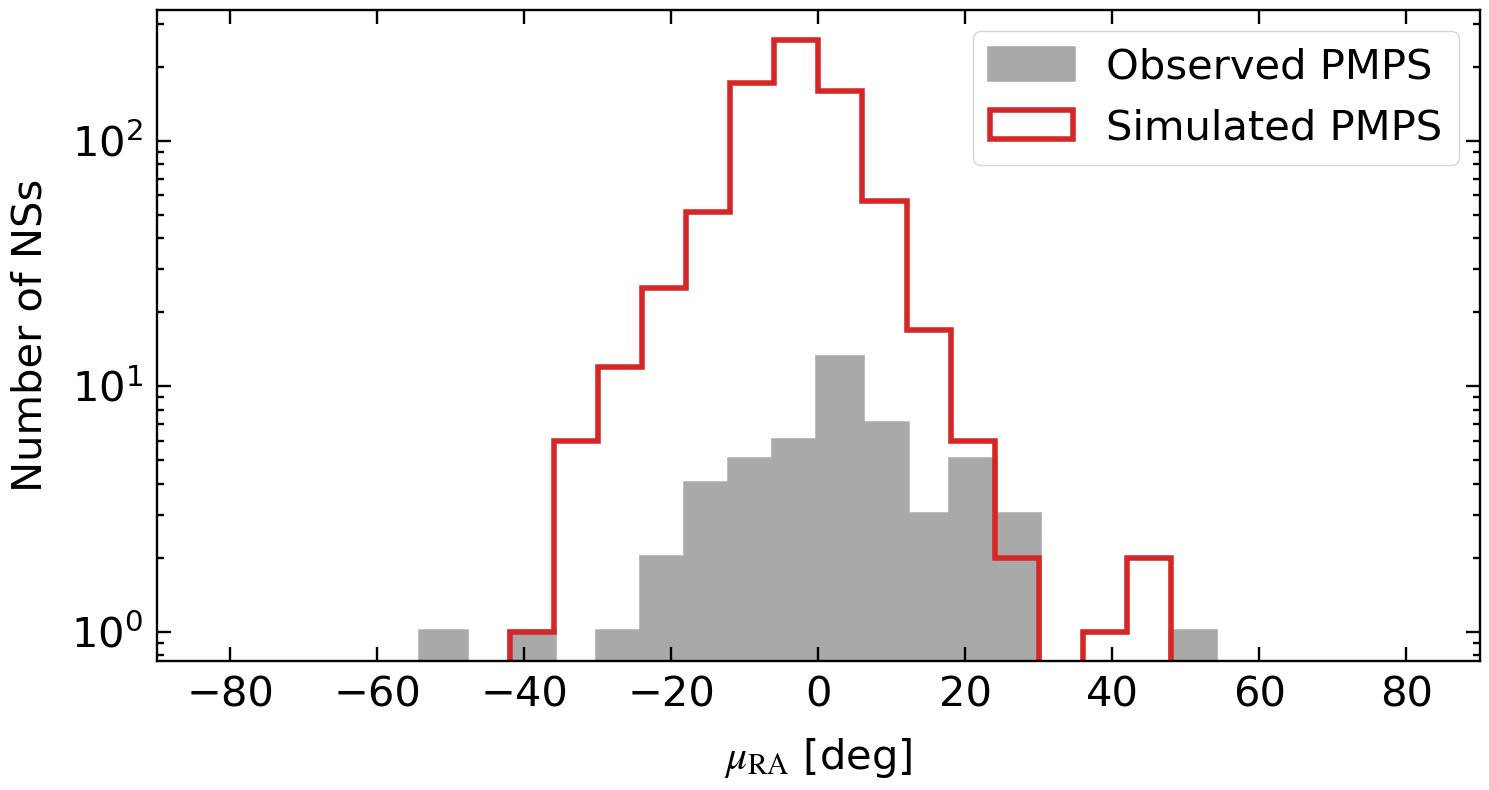

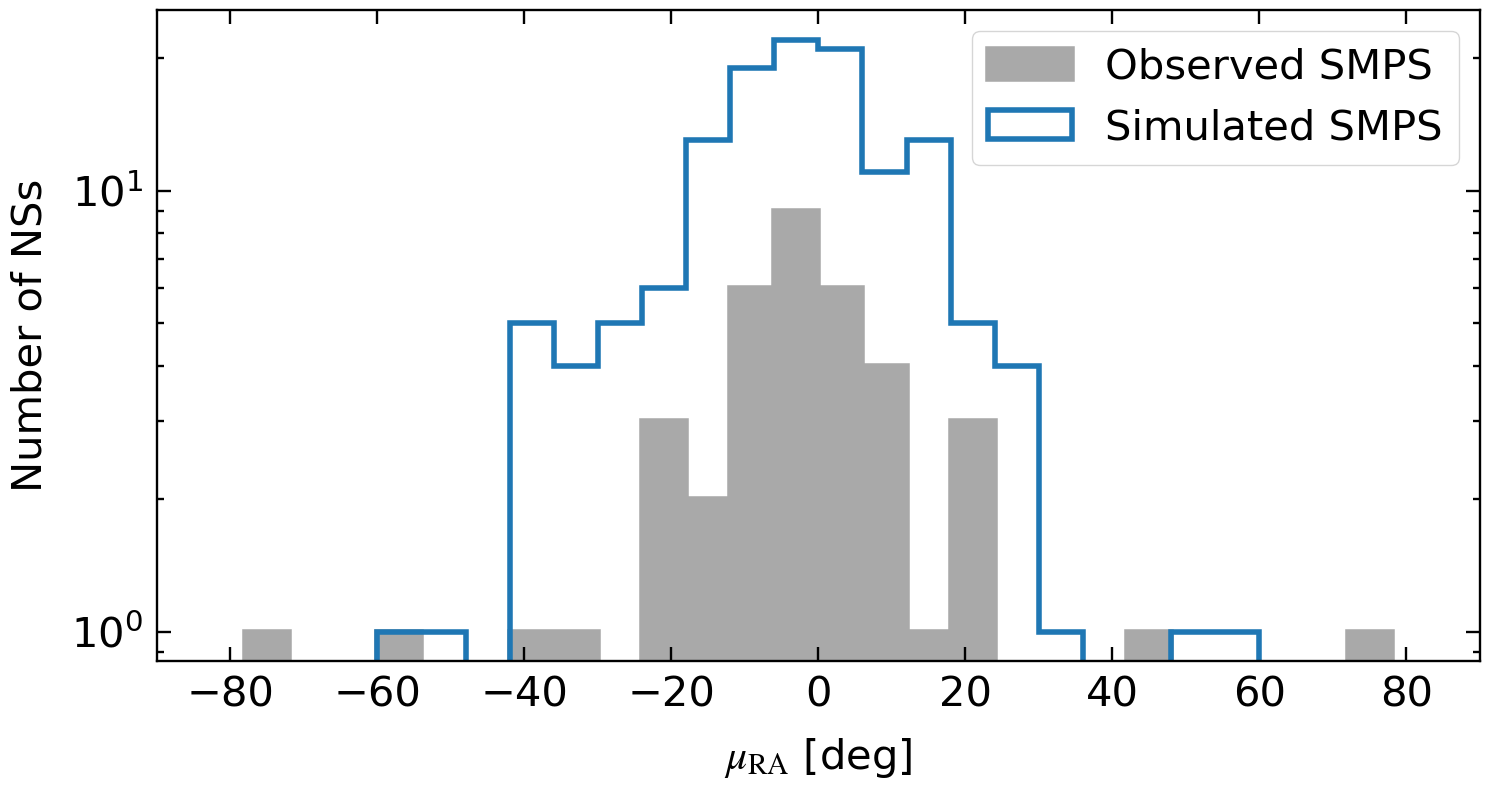

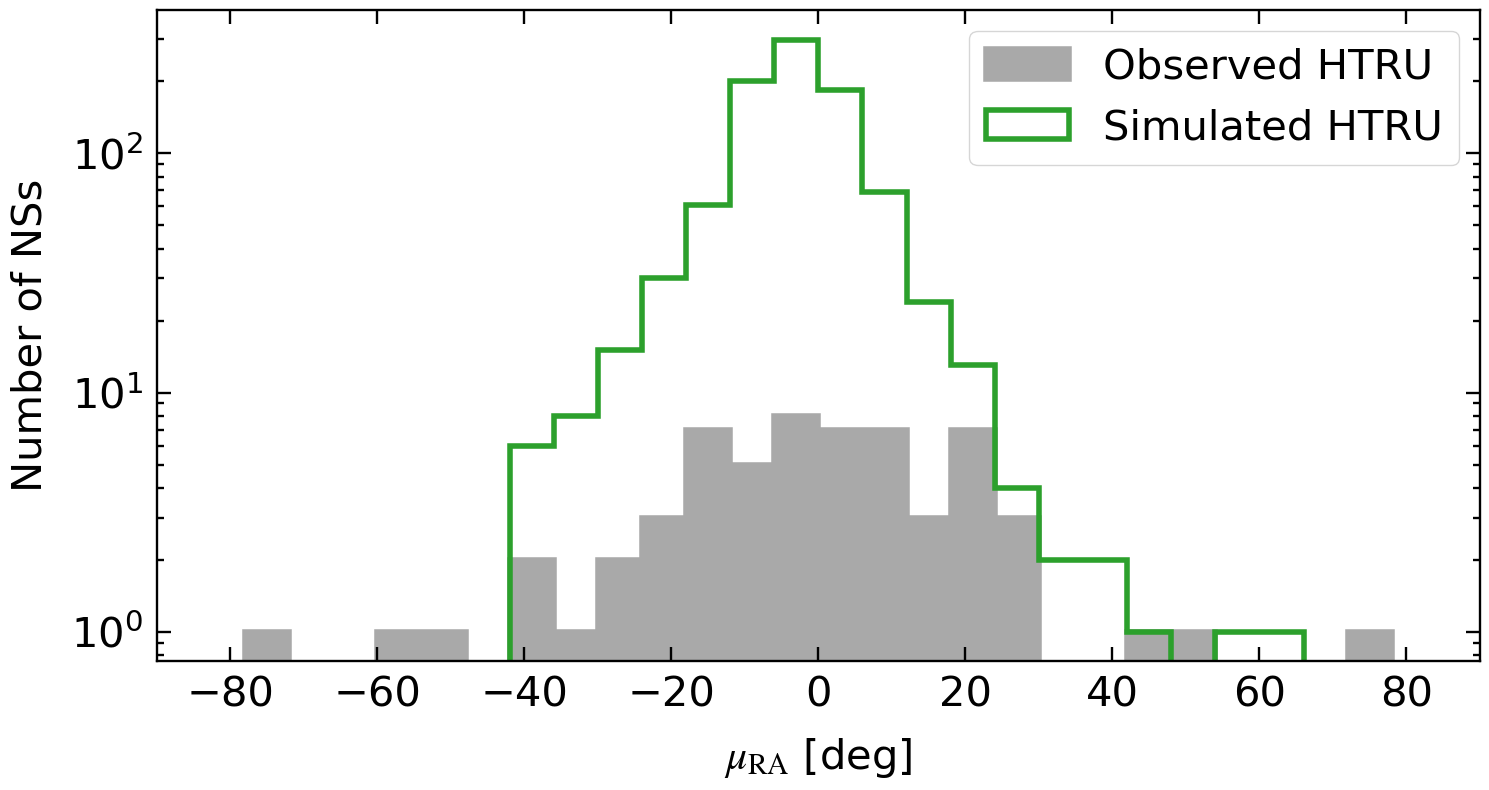

In [44]:
pmRA_edges = np.linspace(-90.0, 90.0, 31)

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    pmRA_pk_obs,
    bins=pmRA_edges,
    histtype="stepfilled",
    edgecolor="darkgray",
    facecolor="darkgray",
    lw=4,
    alpha=1,
    label=r"Observed PMPS",
)
ax.hist(
    pmRA_pk_sim,
    bins=pmRA_edges,
    histtype="step",
    edgecolor="tab:red",
    lw=4,
    alpha=1,
    label=r"Simulated PMPS",
)
ax.set_xlabel(r"$\mu_{\rm RA}$ [deg]")
ax.set_ylabel(r"Number of NSs")
ax.set_yscale("log")
ax.set_xlim(-90.0, 90.0)
ax.legend(frameon=True, loc=0)

plt.show()

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    pmRA_sw_obs,
    bins=pmRA_edges,
    histtype="stepfilled",
    edgecolor="darkgray",
    facecolor="darkgray",
    lw=4,
    alpha=1,
    label=r"Observed SMPS",
)
ax.hist(
    pmRA_sw_sim,
    bins=pmRA_edges,
    histtype="step",
    edgecolor="tab:blue",
    lw=4,
    alpha=1,
    label=r"Simulated SMPS",
)
ax.set_xlabel(r"$\mu_{\rm RA}$ [deg]")
ax.set_ylabel(r"Number of NSs")
ax.set_yscale("log")
ax.set_xlim(-90.0, 90.0)
ax.legend(frameon=True, loc=0)

plt.show()


fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    pmRA_htru_obs,
    bins=pmRA_edges,
    histtype="stepfilled",
    edgecolor="darkgray",
    facecolor="darkgray",
    lw=4,
    alpha=1,
    label=r"Observed HTRU",
)
ax.hist(
    pmRA_htru_sim,
    bins=pmRA_edges,
    histtype="step",
    edgecolor="tab:green",
    lw=4,
    alpha=1,
    label=r"Simulated HTRU",
)
ax.set_xlabel(r"$\mu_{\rm RA}$ [deg]")
ax.set_ylabel(r"Number of NSs")
ax.set_yscale("log")
ax.set_xlim(-90.0, 90.0)
ax.legend(frameon=True, loc=0)

plt.show()

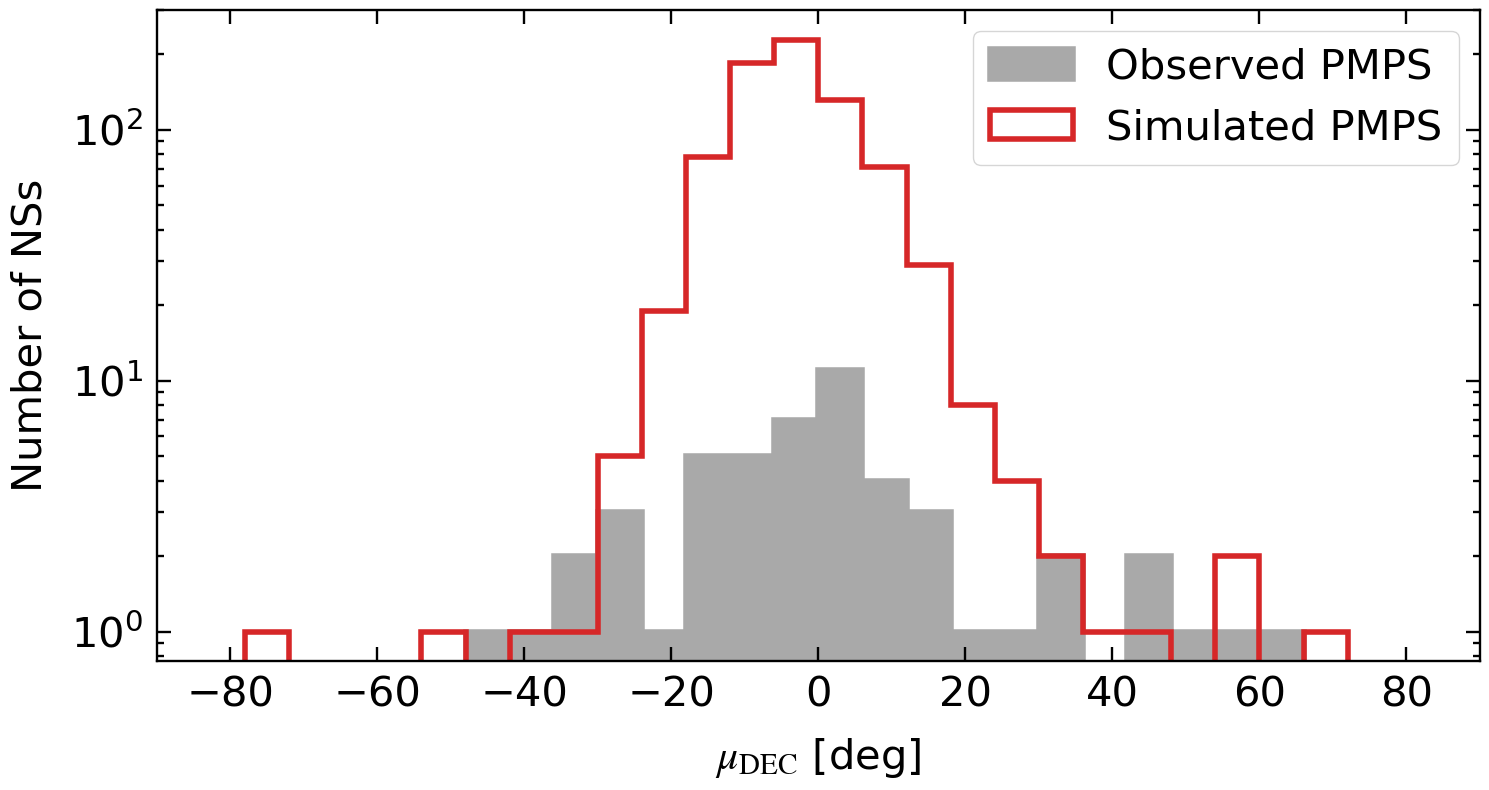

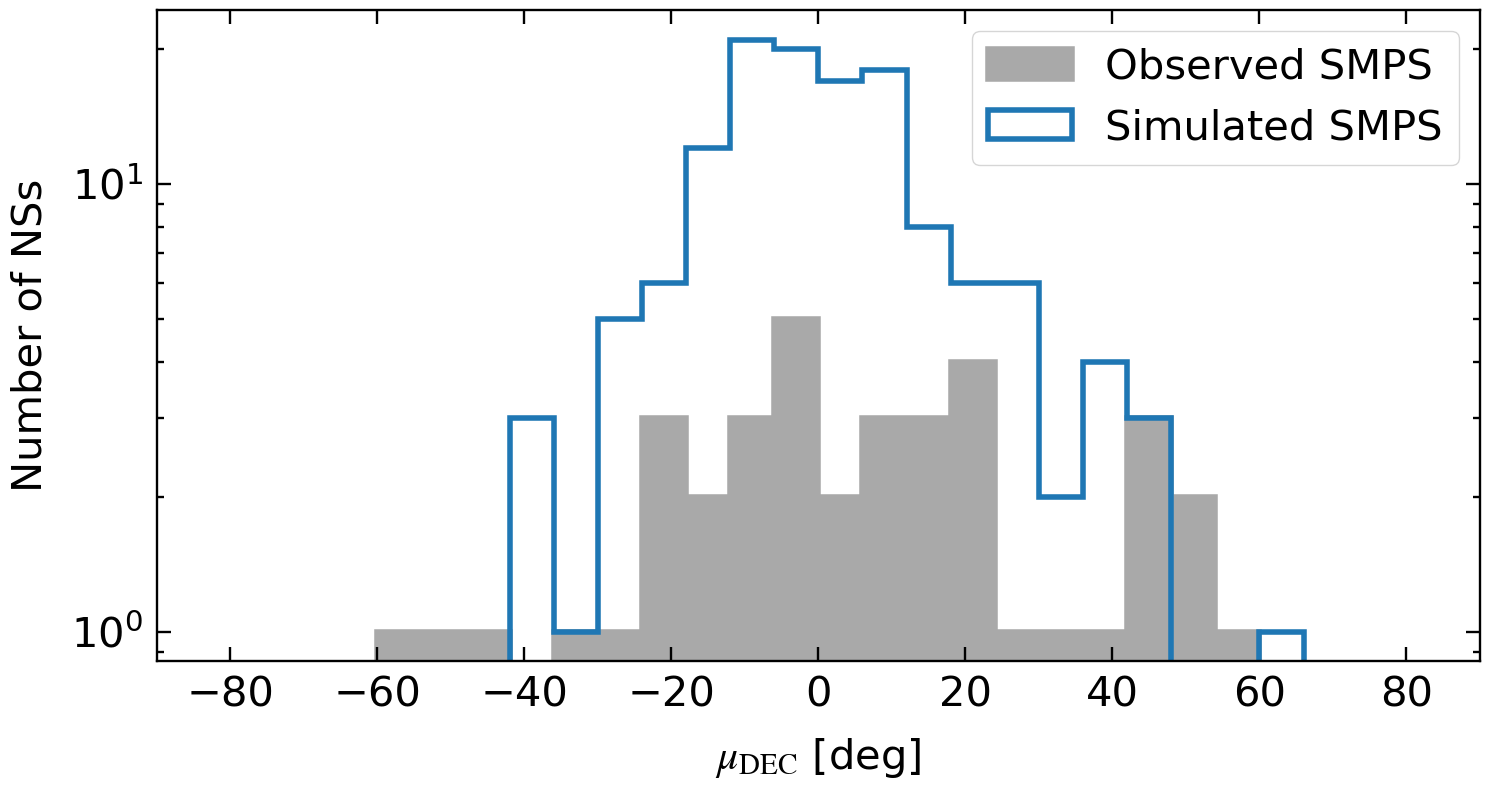

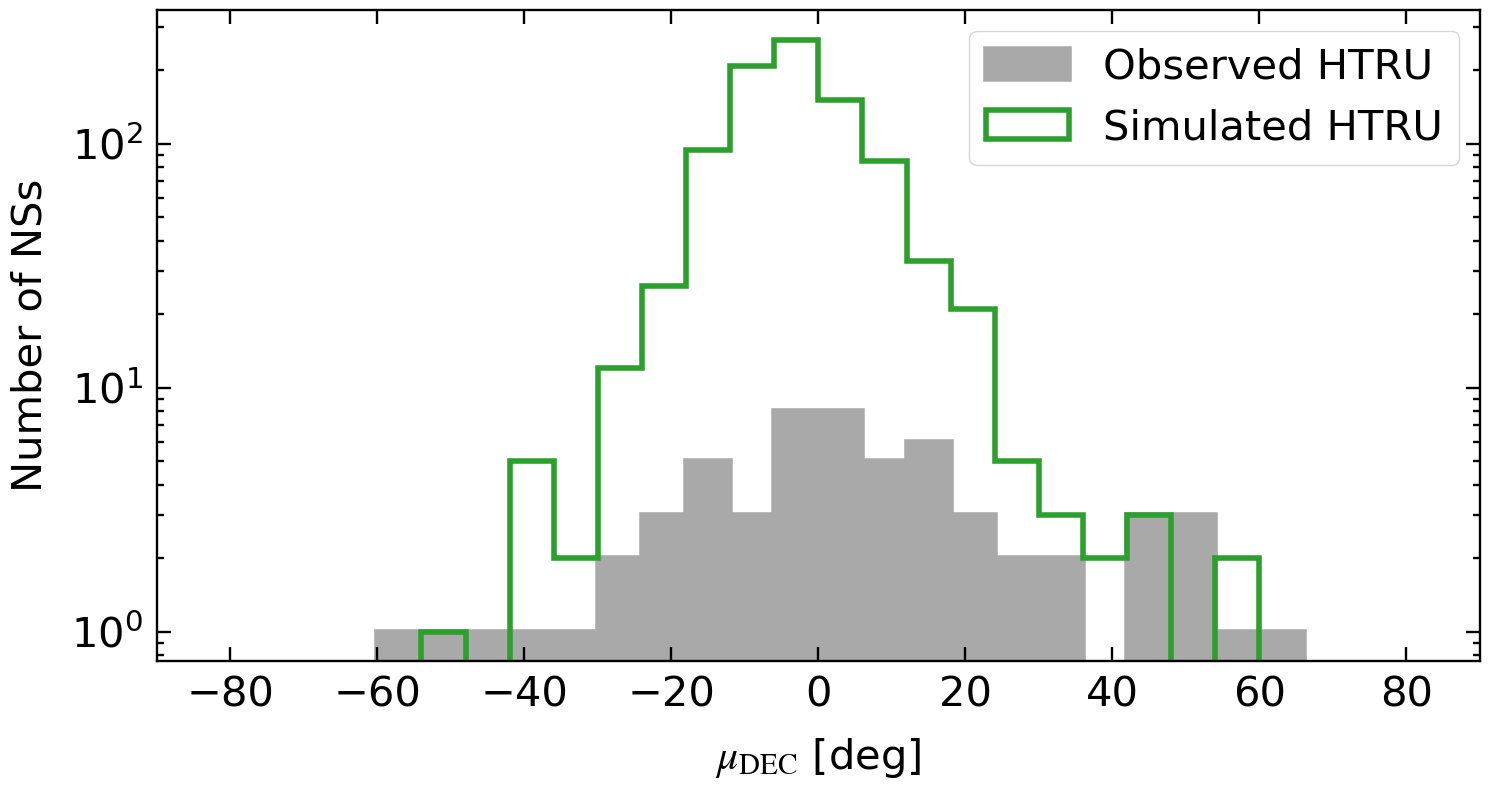

In [45]:
pmDEC_edges = np.linspace(-90.0, 90.0, 31)

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    pmDEC_pk_obs,
    bins=pmDEC_edges,
    histtype="stepfilled",
    edgecolor="darkgray",
    facecolor="darkgray",
    lw=4,
    alpha=1,
    label=r"Observed PMPS",
)
ax.hist(
    pmDEC_pk_sim,
    bins=pmDEC_edges,
    histtype="step",
    edgecolor="tab:red",
    lw=4,
    alpha=1,
    label=r"Simulated PMPS",
)
ax.set_xlabel(r"$\mu_{\rm DEC}$ [deg]")
ax.set_ylabel(r"Number of NSs")
ax.set_yscale("log")
ax.set_xlim(-90.0, 90.0)
ax.legend(frameon=True, loc=0)

plt.show()

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    pmDEC_sw_obs,
    bins=pmDEC_edges,
    histtype="stepfilled",
    edgecolor="darkgray",
    facecolor="darkgray",
    lw=4,
    alpha=1,
    label=r"Observed SMPS",
)
ax.hist(
    pmDEC_sw_sim,
    bins=pmDEC_edges,
    histtype="step",
    edgecolor="tab:blue",
    lw=4,
    alpha=1,
    label=r"Simulated SMPS",
)
ax.set_xlabel(r"$\mu_{\rm DEC}$ [deg]")
ax.set_ylabel(r"Number of NSs")
ax.set_yscale("log")
ax.set_xlim(-90.0, 90.0)
ax.legend(frameon=True, loc=0)

plt.show()

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    pmDEC_htru_obs,
    bins=pmDEC_edges,
    histtype="stepfilled",
    edgecolor="darkgray",
    facecolor="darkgray",
    lw=4,
    alpha=1,
    label=r"Observed HTRU",
)
ax.hist(
    pmDEC_htru_sim,
    bins=pmDEC_edges,
    histtype="step",
    edgecolor="tab:green",
    lw=4,
    alpha=1,
    label=r"Simulated HTRU",
)
ax.set_xlabel(r"$\mu_{\rm DEC}$ [deg]")
ax.set_ylabel(r"Number of NSs")
ax.set_yscale("log")
ax.set_xlim(-90.0, 90.0)
ax.legend(frameon=True, loc=0)

plt.show()

Compare DM distributions.

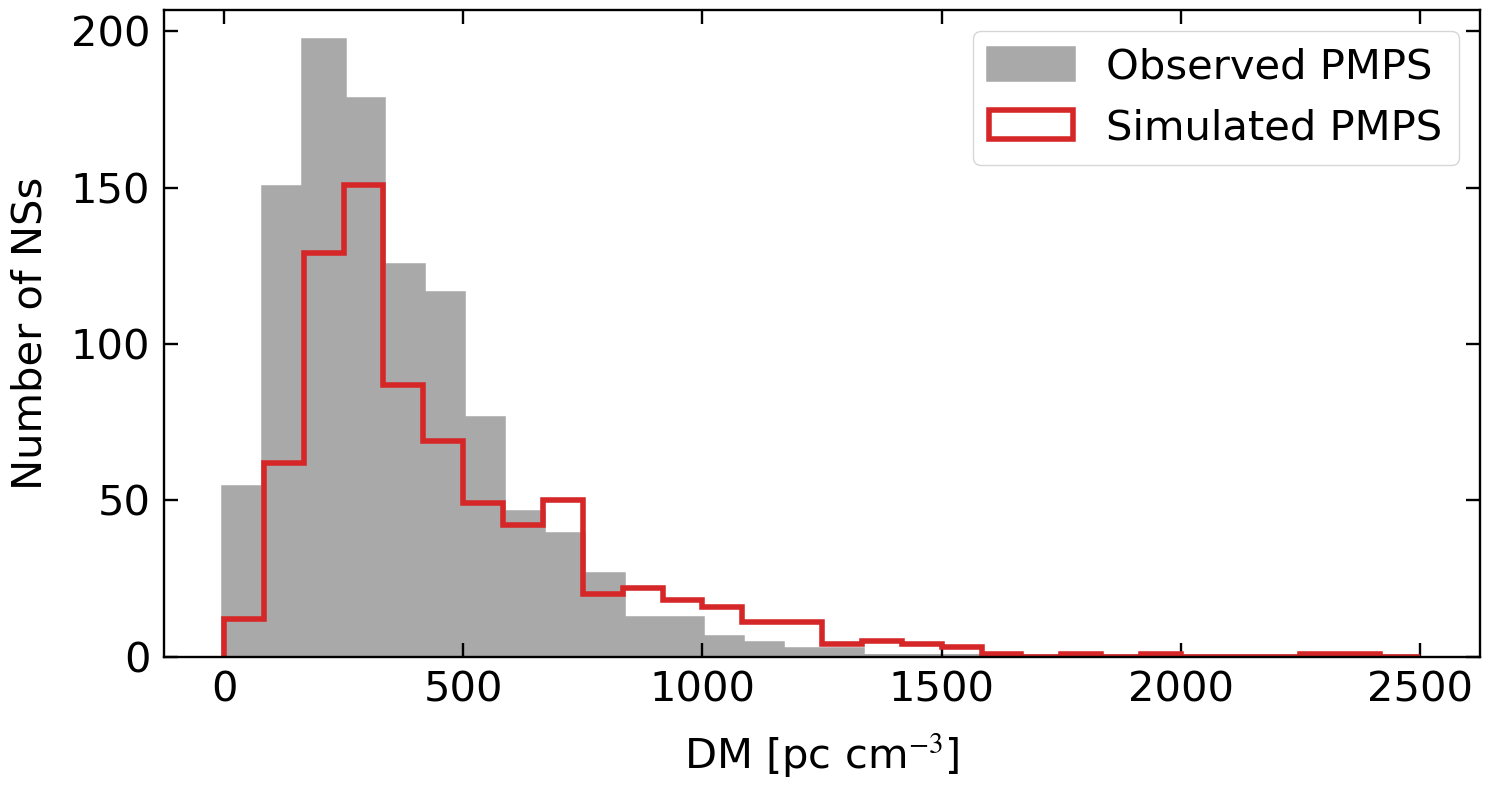

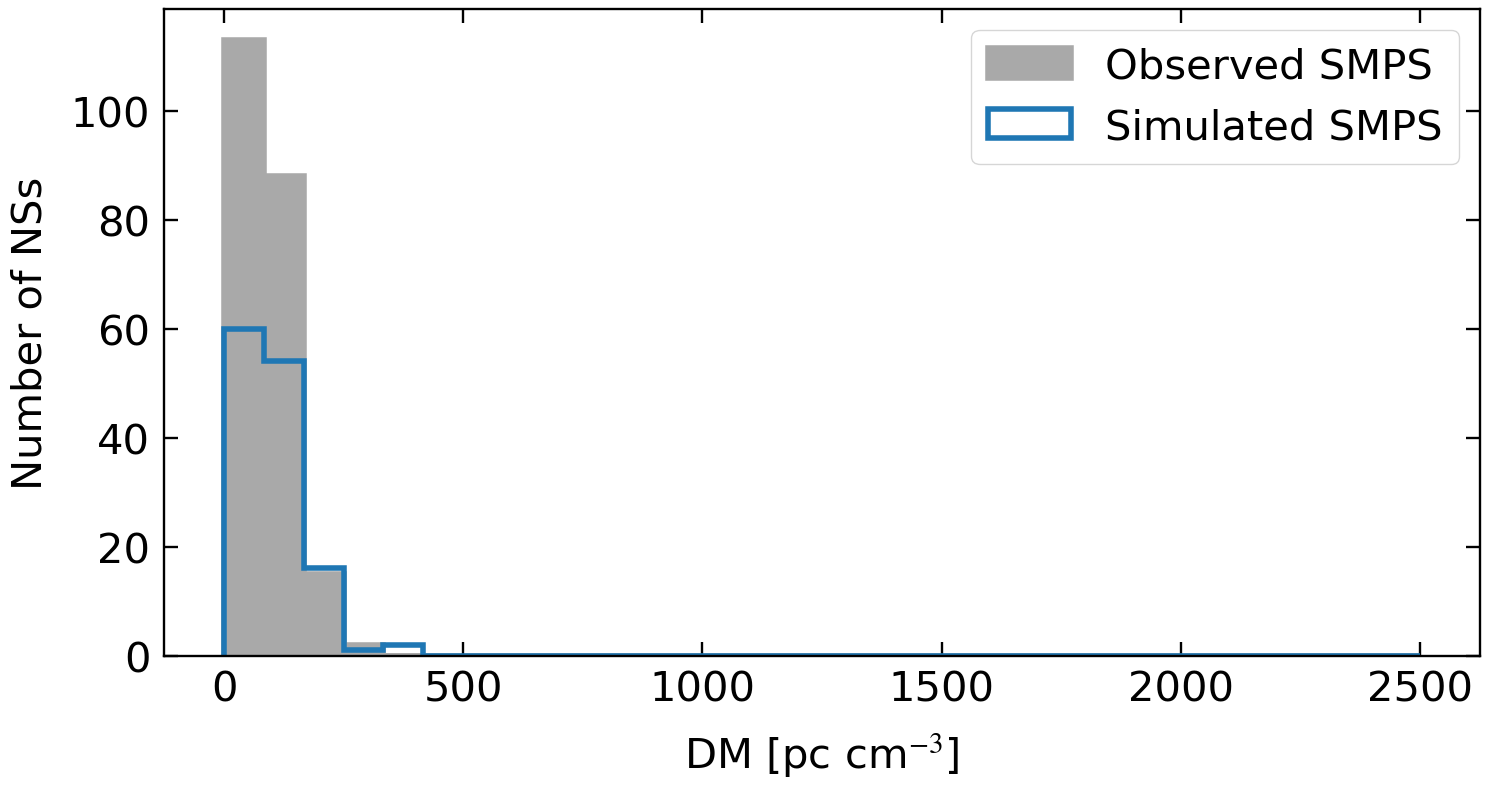

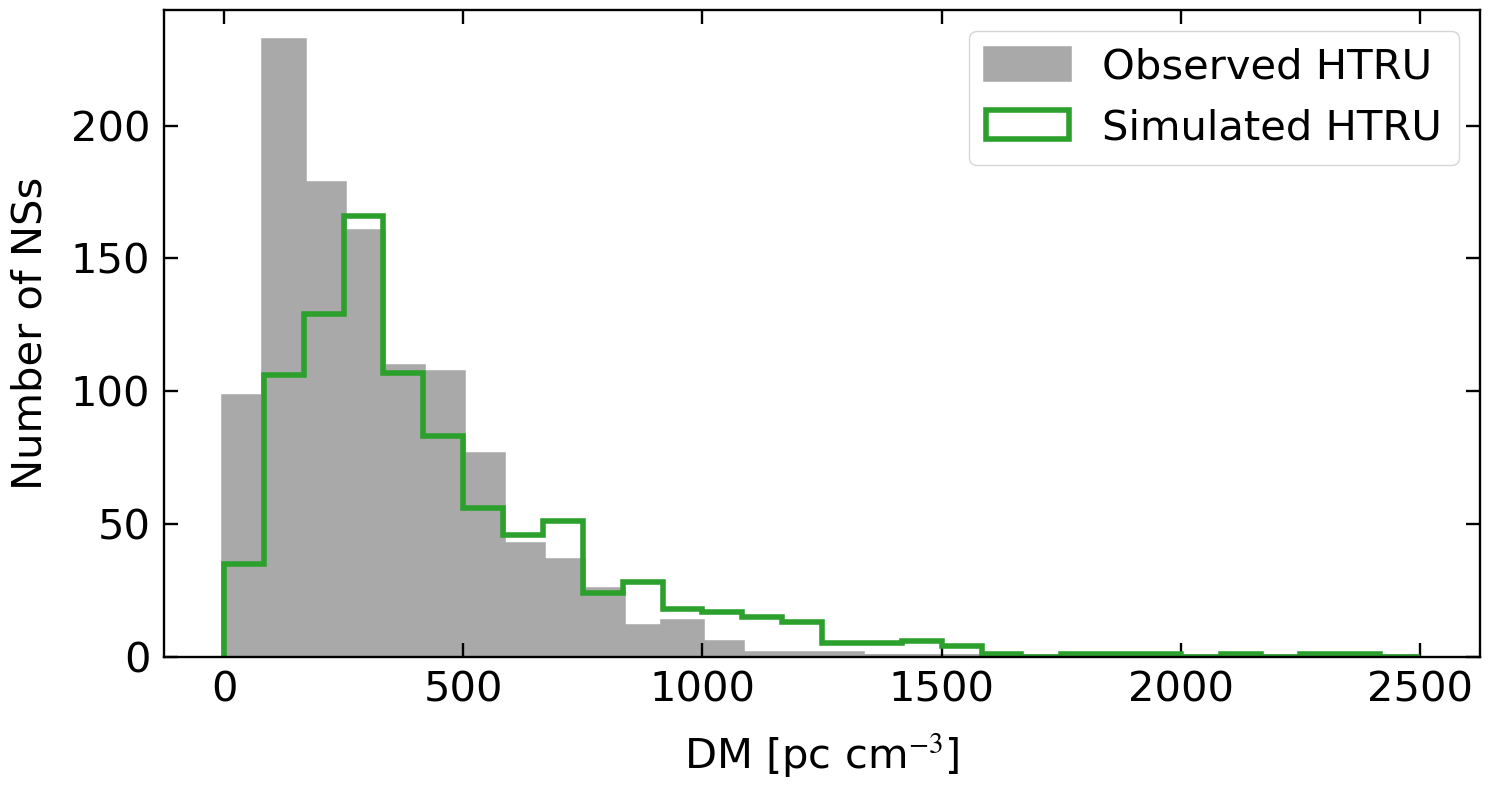

In [46]:
dm_edges = np.linspace(0, 2500, 31)

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    DM_pk_obs,
    bins=dm_edges,
    histtype="stepfilled",
    edgecolor="darkgray",
    facecolor="darkgray",
    lw=4,
    alpha=1.0,
    label=r"Observed PMPS",
    rasterized=True,
)
ax.hist(
    DM_pk_sim,
    bins=dm_edges,
    histtype="step",
    edgecolor="tab:red",
    lw=4,
    alpha=1.0,
    label=r"Simulated PMPS",
    rasterized=True,
)
ax.set_xlabel(r"DM [pc cm$^{-3}$]")
ax.set_ylabel("Number of NSs")
# ax.set_yscale("log")
ax.legend(frameon=True, loc=0)

plt.show()

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    DM_sw_obs,
    bins=dm_edges,
    histtype="stepfilled",
    edgecolor="darkgray",
    facecolor="darkgray",
    lw=4,
    alpha=1.0,
    label=r"Observed SMPS",
    rasterized=True,
)
ax.hist(
    DM_sw_sim,
    bins=dm_edges,
    histtype="step",
    edgecolor="tab:blue",
    lw=4,
    alpha=1.0,
    label=r"Simulated SMPS",
    rasterized=True,
)
ax.set_xlabel(r"DM [pc cm$^{-3}$]")
ax.set_ylabel("Number of NSs")
# ax.set_yscale("log")
ax.legend(frameon=True, loc=0)

plt.show()


fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    DM_htru_obs,
    bins=dm_edges,
    histtype="stepfilled",
    edgecolor="darkgray",
    facecolor="darkgray",
    lw=4,
    alpha=1.0,
    label=r"Observed HTRU",
    rasterized=True,
)
ax.hist(
    DM_htru_sim,
    bins=dm_edges,
    histtype="step",
    edgecolor="tab:green",
    lw=4,
    alpha=1.0,
    label=r"Simulated HTRU",
    rasterized=True,
)
ax.set_xlabel(r"DM [pc cm$^{-3}$]")
ax.set_ylabel("Number of NSs")
# ax.set_yscale("log")
ax.legend(frameon=True, loc=0)

plt.show()

Compare distance distributions.

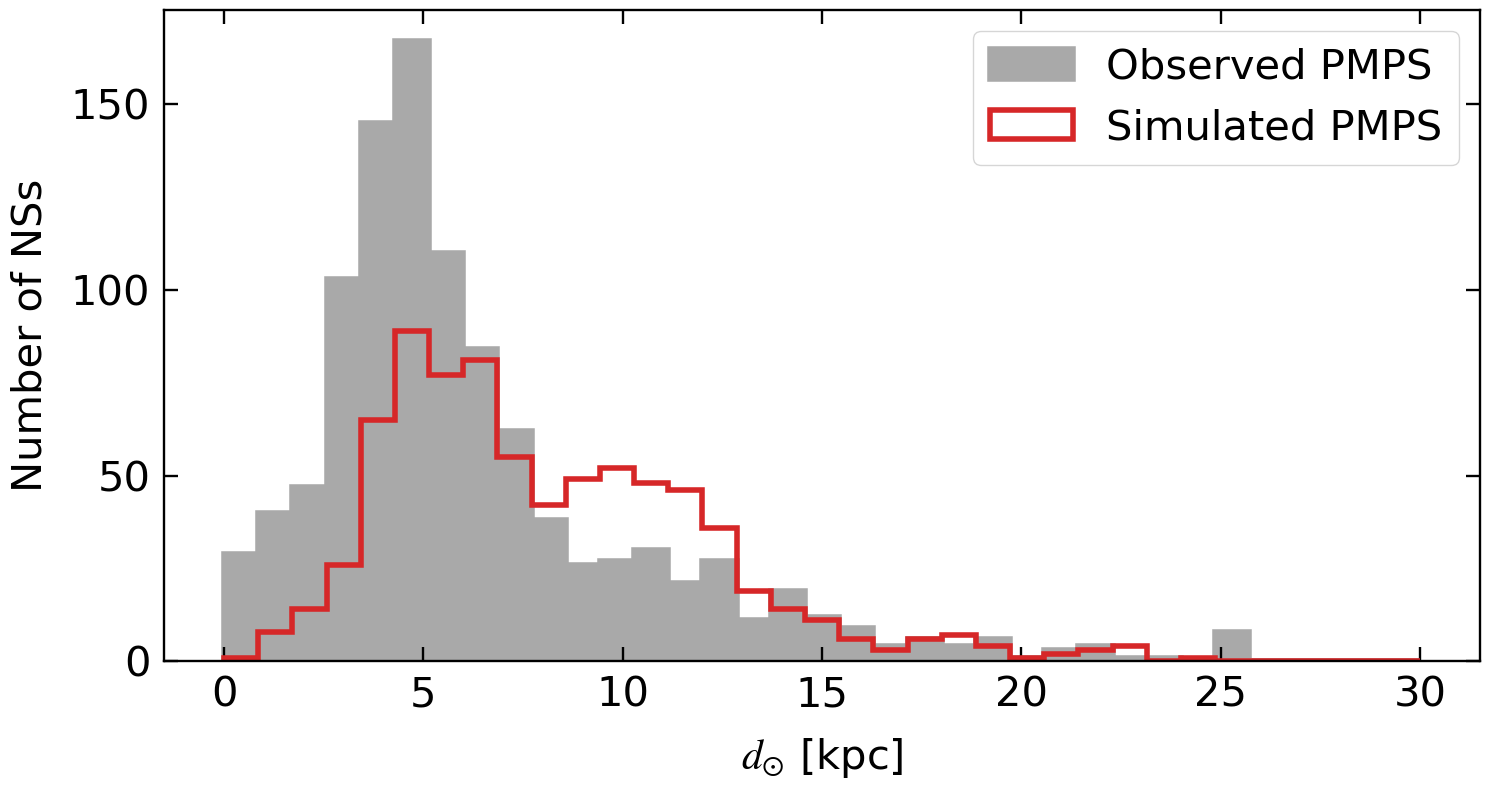

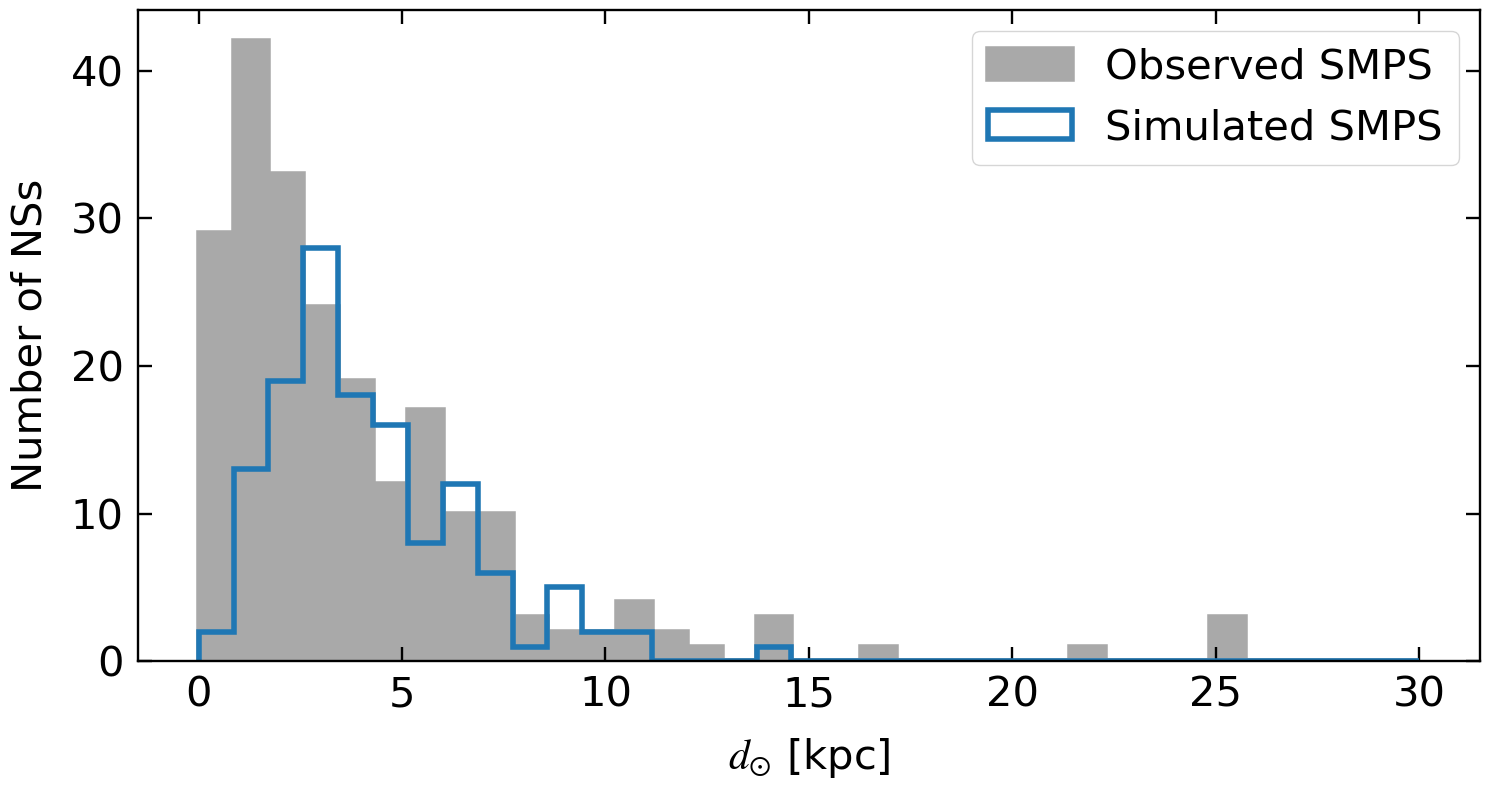

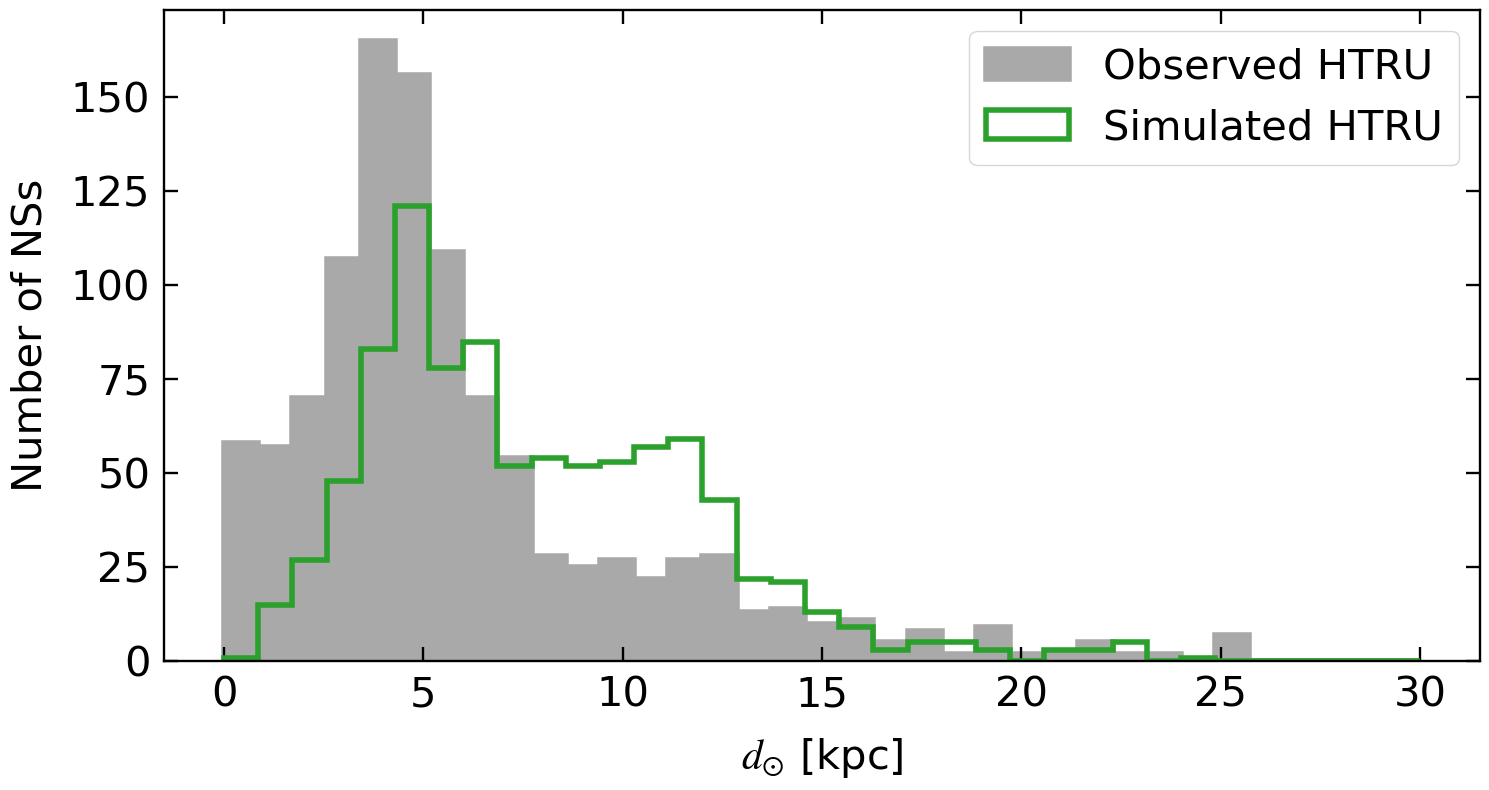

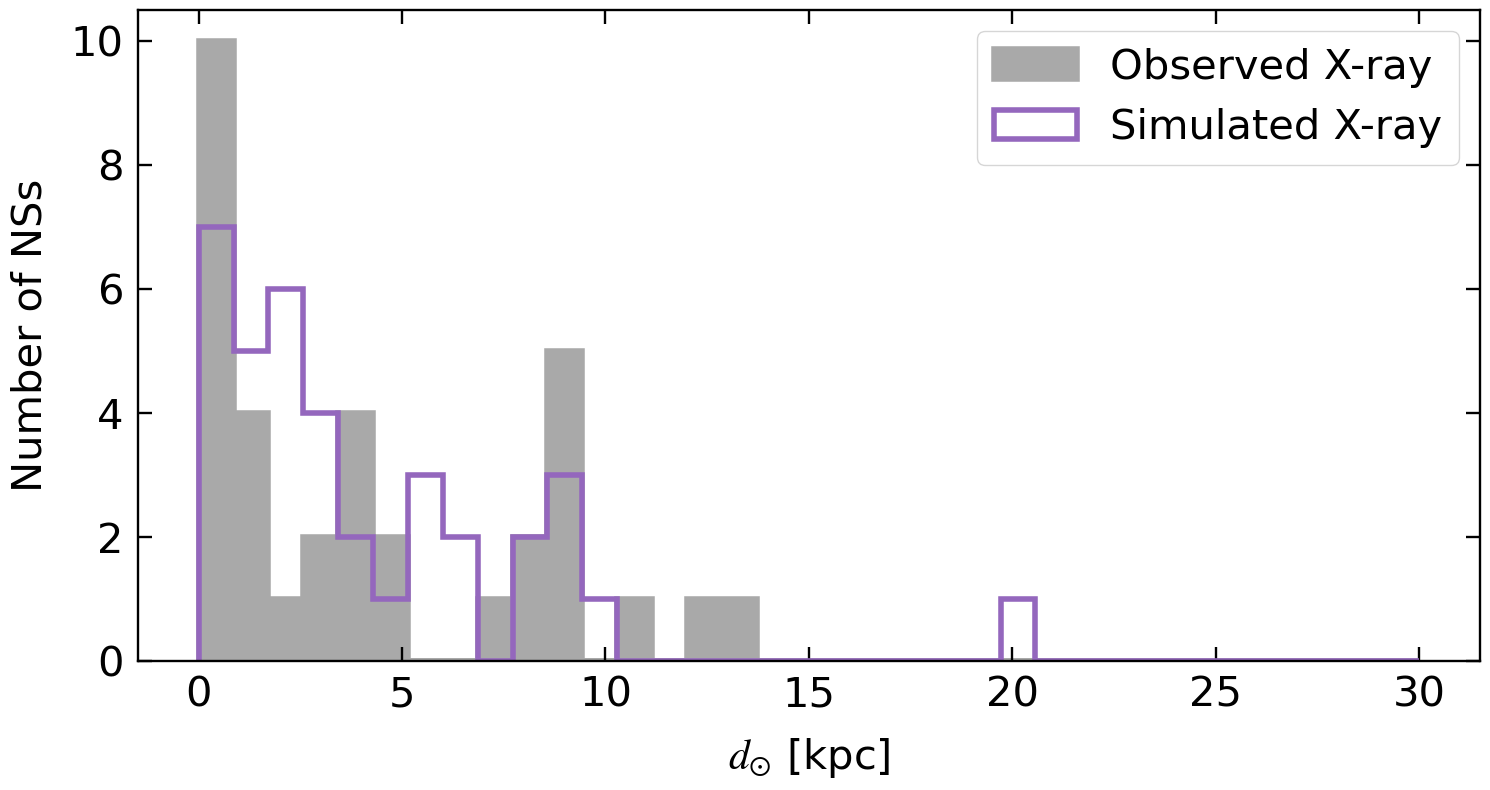

In [47]:
d_edges = np.linspace(0, 30, 36)

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    dist_pk_obs,
    bins=d_edges,
    histtype="stepfilled",
    edgecolor="darkgray",
    facecolor="darkgray",
    lw=4,
    alpha=1.0,
    label=r"Observed PMPS",
    rasterized=True,
)
ax.hist(
    dist_pk_sim,
    bins=d_edges,
    histtype="step",
    edgecolor="tab:red",
    lw=4,
    alpha=1.0,
    label=r"Simulated PMPS",
    rasterized=True,
)
ax.set_xlabel(r"$d_{\odot}$ [kpc]")
ax.set_ylabel("Number of NSs")
ax.legend(frameon=True, loc=0)

plt.show()

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    dist_sw_obs,
    bins=d_edges,
    histtype="stepfilled",
    edgecolor="darkgray",
    facecolor="darkgray",
    lw=4,
    alpha=1.0,
    label=r"Observed SMPS",
    rasterized=True,
)
ax.hist(
    dist_sw_sim,
    bins=d_edges,
    histtype="step",
    edgecolor="tab:blue",
    lw=4,
    alpha=1.0,
    label=r"Simulated SMPS",
    rasterized=True,
)
ax.set_xlabel(r"$d_{\odot}$ [kpc]")
ax.set_ylabel("Number of NSs")
ax.legend(frameon=True, loc=0)

plt.show()


fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    dist_htru_obs,
    bins=d_edges,
    histtype="stepfilled",
    edgecolor="darkgray",
    facecolor="darkgray",
    lw=4,
    alpha=1.0,
    label=r"Observed HTRU",
    rasterized=True,
)
ax.hist(
    dist_htru_sim,
    bins=d_edges,
    histtype="step",
    edgecolor="tab:green",
    lw=4,
    alpha=1.0,
    label=r"Simulated HTRU",
    rasterized=True,
)
ax.set_xlabel(r"$d_{\odot}$ [kpc]")
ax.set_ylabel("Number of NSs")
ax.legend(frameon=True, loc=0)

plt.show()

if survey_x:
    fig, ax = plt.subplots(figsize=(15, 8))

    ax.hist(
        dist_x_obs,
        bins=d_edges,
        histtype="stepfilled",
        edgecolor="darkgray",
        facecolor="darkgray",
        lw=4,
        alpha=1.0,
        label=r"Observed X-ray",
        rasterized=True,
    )
    ax.hist(
        dist_x_sim,
        bins=d_edges,
        histtype="step",
        edgecolor="tab:purple",
        lw=4,
        alpha=1.0,
        label=r"Simulated X-ray",
        rasterized=True,
    )
    ax.set_xlabel(r"$d_{\odot}$ [kpc]")
    ax.set_ylabel("Number of NSs")
    ax.legend(frameon=True, loc=0)

    plt.show()

Comparing the spin-period and spin-period-derivative distributions.

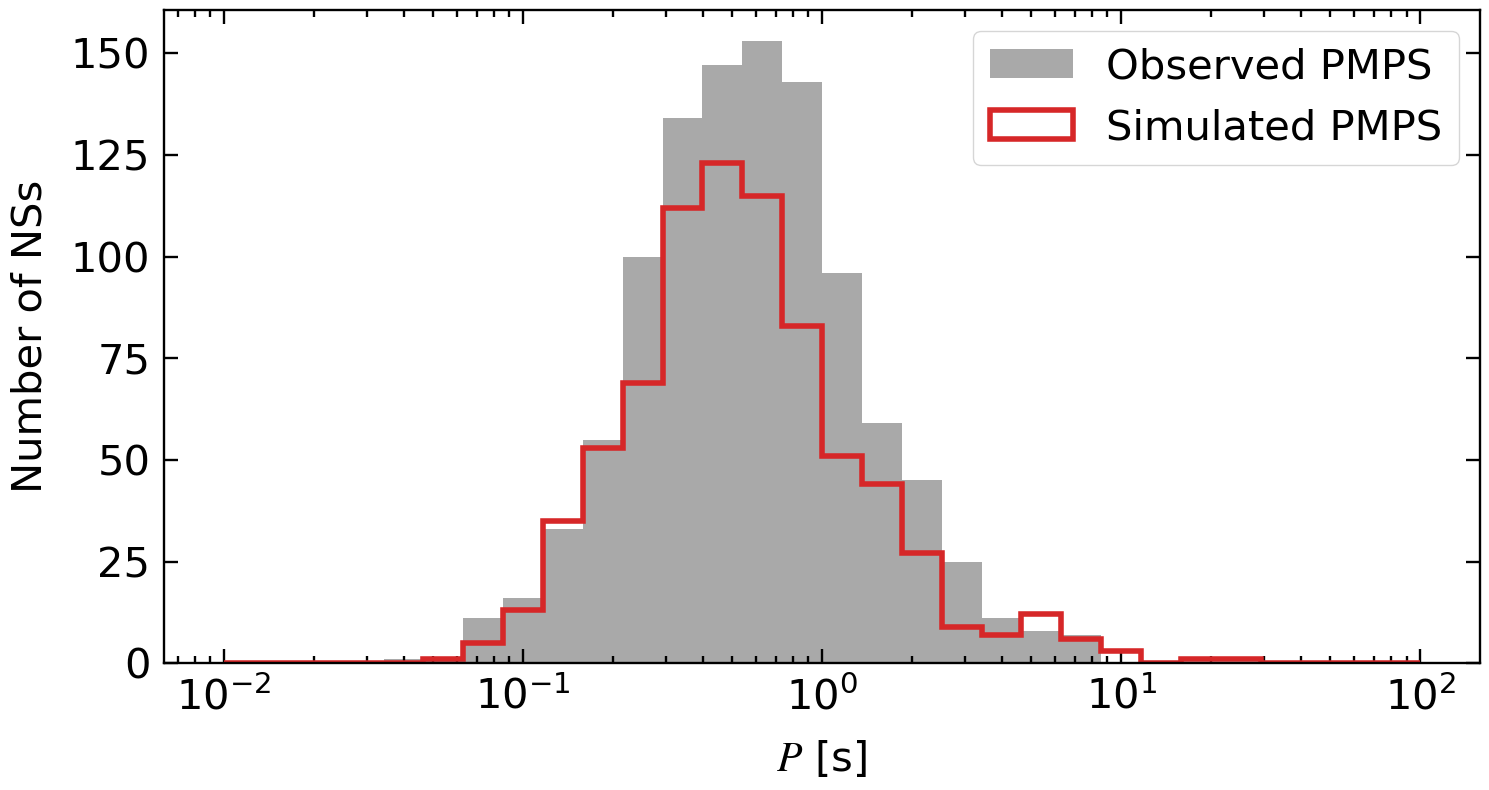

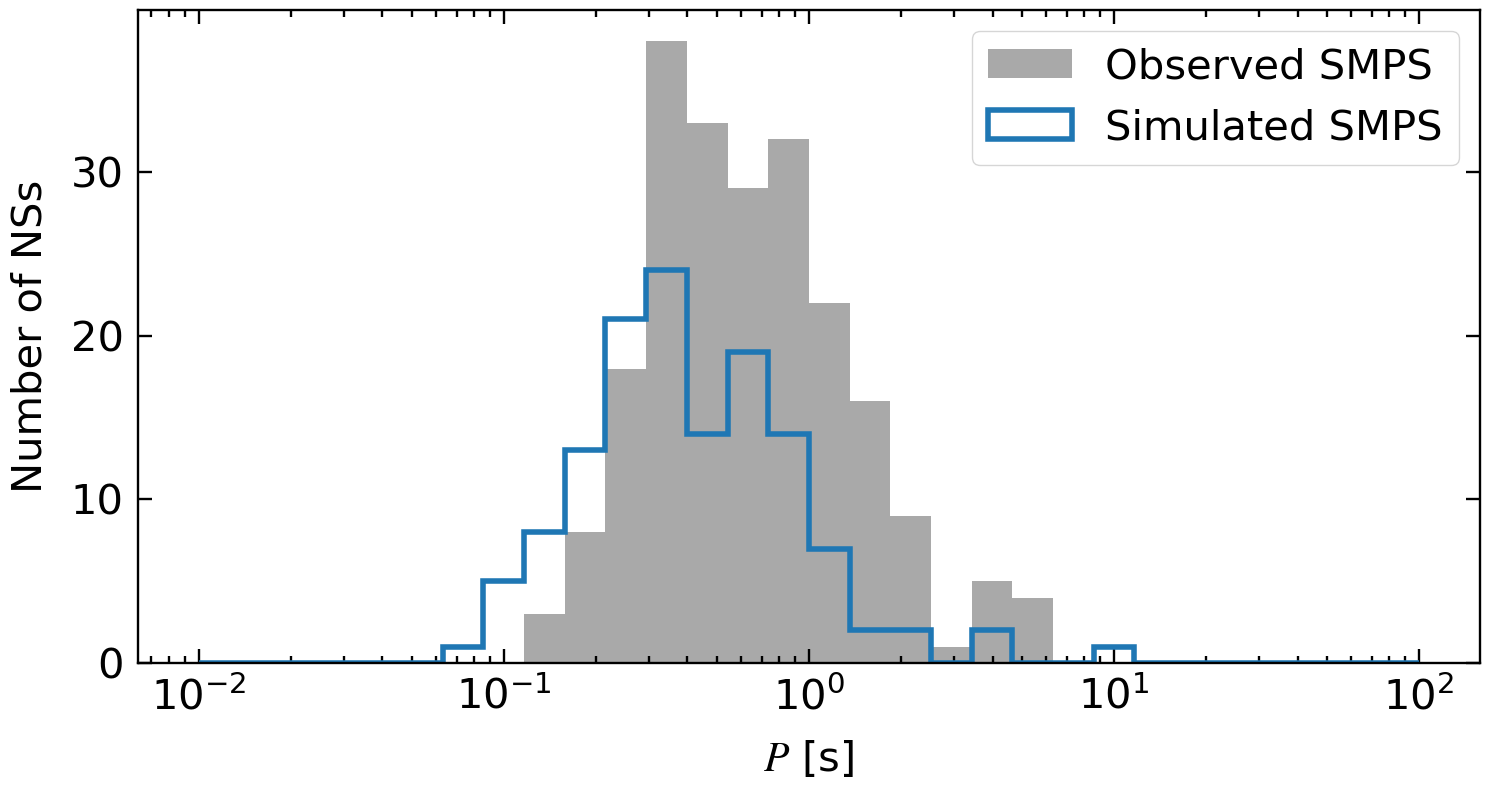

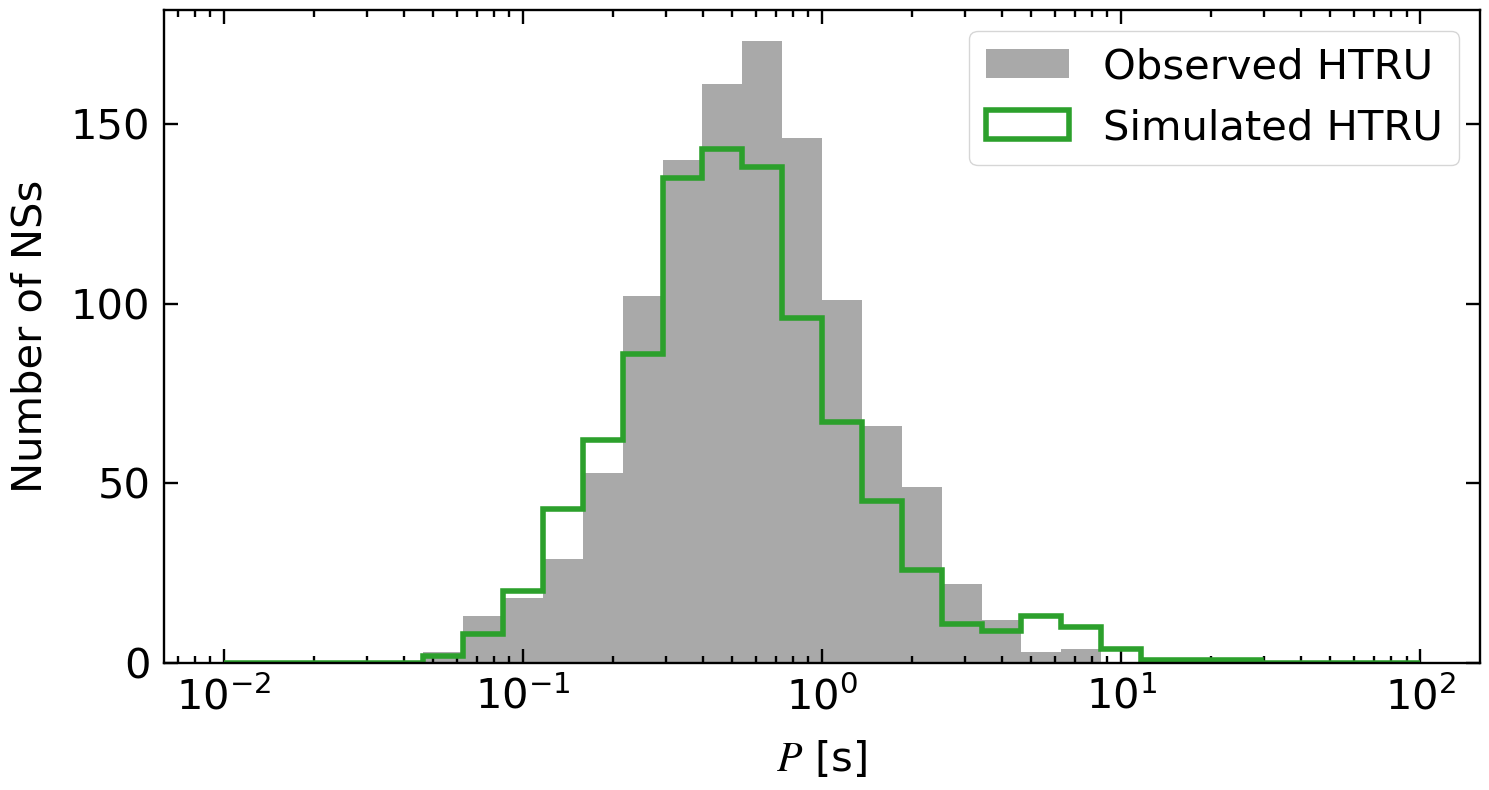

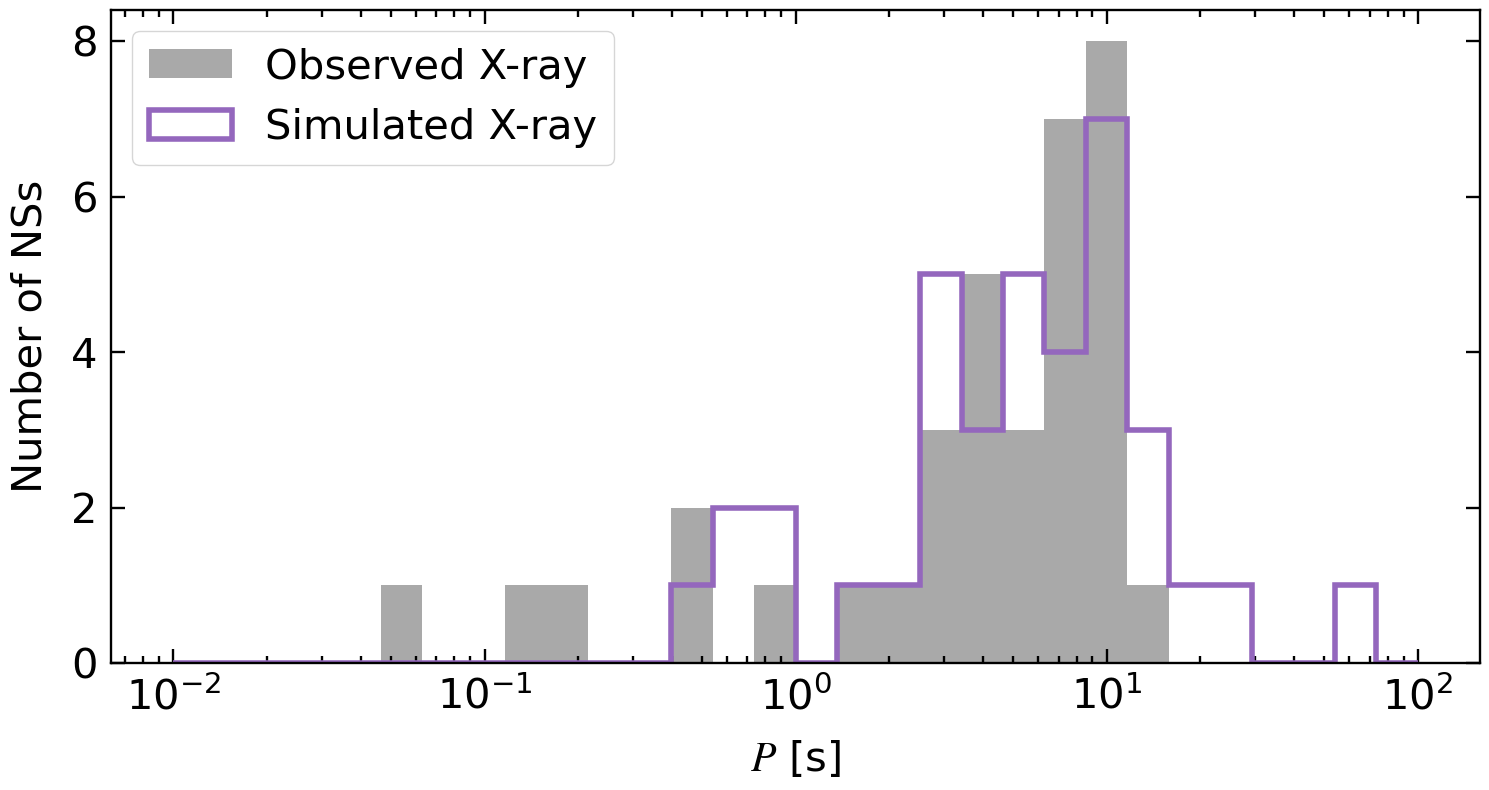

In [48]:
P_bins = np.logspace(-2.0, 2.0, 31)

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    P_pk_obs,
    bins=P_bins,
    histtype="stepfilled",
    color="darkgray",
    lw=4,
    label="Observed PMPS",
)
ax.hist(
    P_pk_sim,
    bins=P_bins,
    histtype="step",
    edgecolor="tab:red",
    lw=4,
    label="Simulated PMPS",
)

plt.xlabel(r"$P$ [s]")
plt.ylabel(r"Number of NSs")
plt.xscale("log")
ax.legend(frameon=True, loc=0)

plt.show()

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    P_sw_obs,
    bins=P_bins,
    histtype="stepfilled",
    color="darkgray",
    lw=4,
    label="Observed SMPS",
)
ax.hist(
    P_sw_sim,
    bins=P_bins,
    histtype="step",
    edgecolor="tab:blue",
    lw=4,
    label="Simulated SMPS",
)

plt.xlabel(r"$P$ [s]")
plt.ylabel(r"Number of NSs")
plt.xscale("log")
ax.legend(frameon=True, loc=0)

plt.show()

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    P_htru_obs,
    bins=P_bins,
    histtype="stepfilled",
    color="darkgray",
    lw=4,
    label="Observed HTRU",
)
ax.hist(
    P_htru_sim,
    bins=P_bins,
    histtype="step",
    edgecolor="tab:green",
    lw=4,
    label="Simulated HTRU",
)

plt.xlabel(r"$P$ [s]")
plt.ylabel(r"Number of NSs")
plt.xscale("log")
ax.legend(frameon=True, loc=0)

plt.show()

if survey_x:
    fig, ax = plt.subplots(figsize=(15, 8))

    ax.hist(
        P_x_obs,
        bins=P_bins,
        histtype="stepfilled",
        color="darkgray",
        lw=4,
        label="Observed X-ray",
    )
    ax.hist(
        P_x_sim,
        bins=P_bins,
        histtype="step",
        edgecolor="tab:purple",
        lw=4,
        label="Simulated X-ray",
    )

    plt.xlabel(r"$P$ [s]")
    plt.ylabel(r"Number of NSs")
    plt.xscale("log")
    ax.legend(frameon=True, loc=0)

    plt.show()

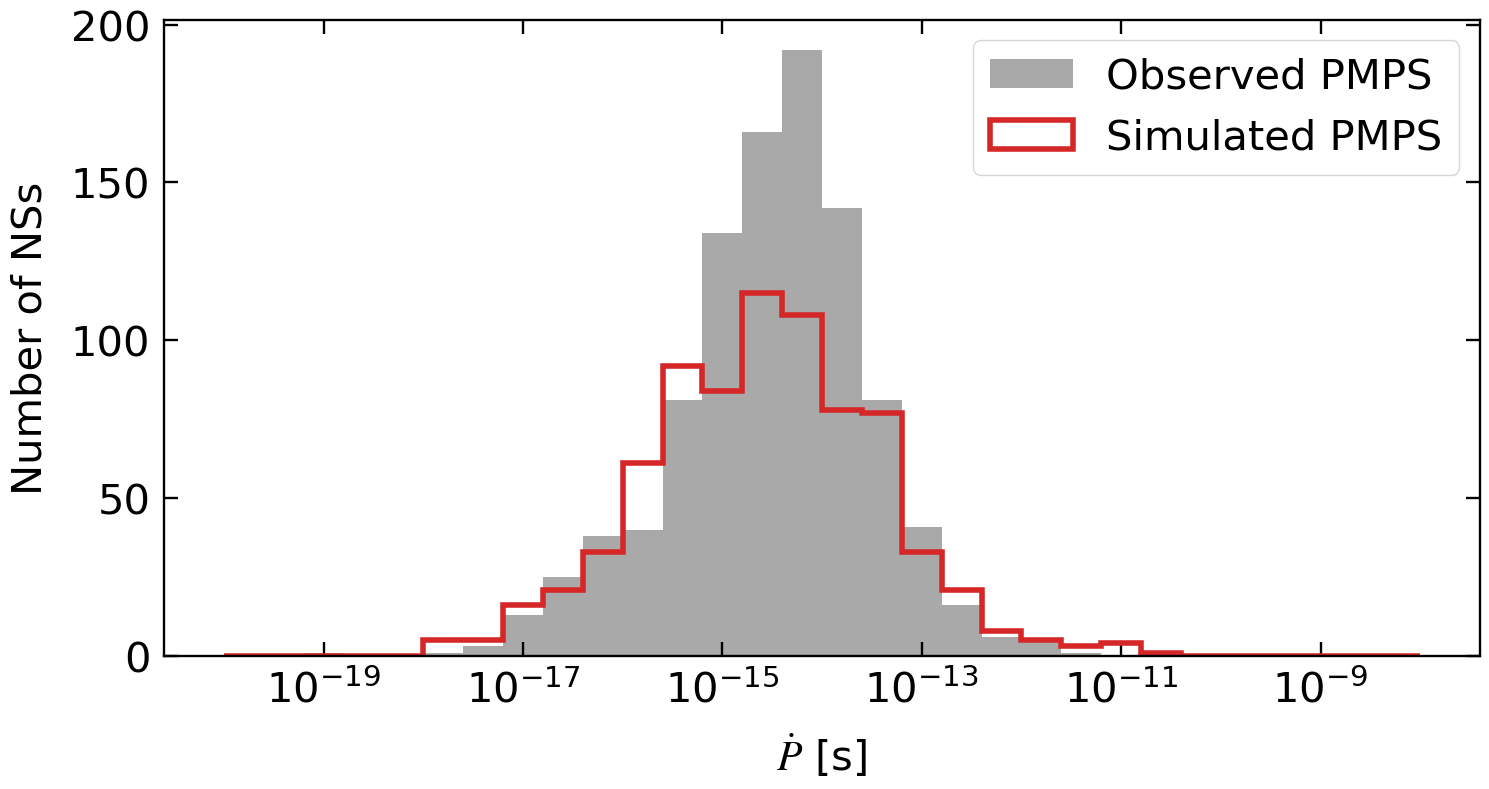

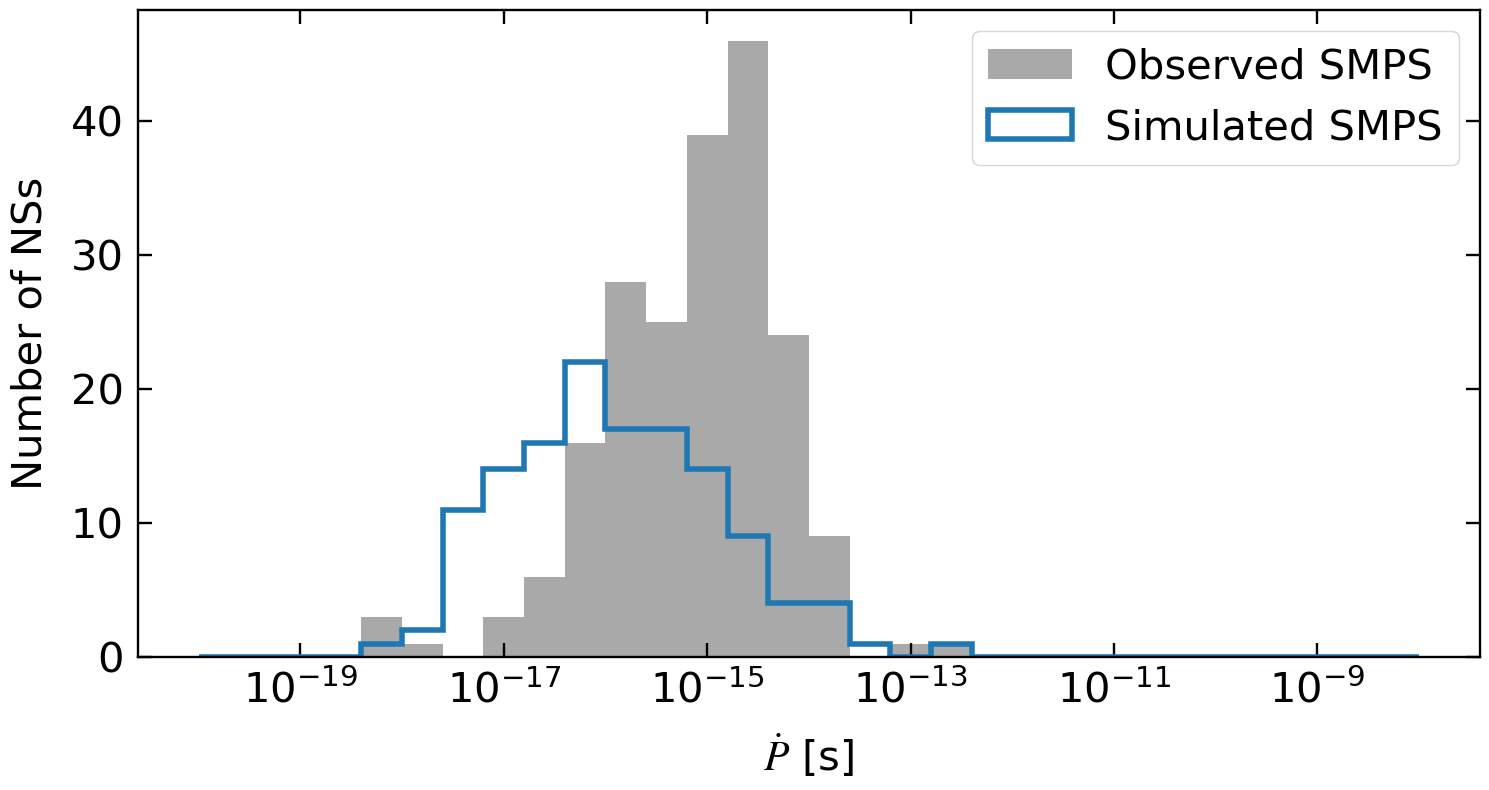

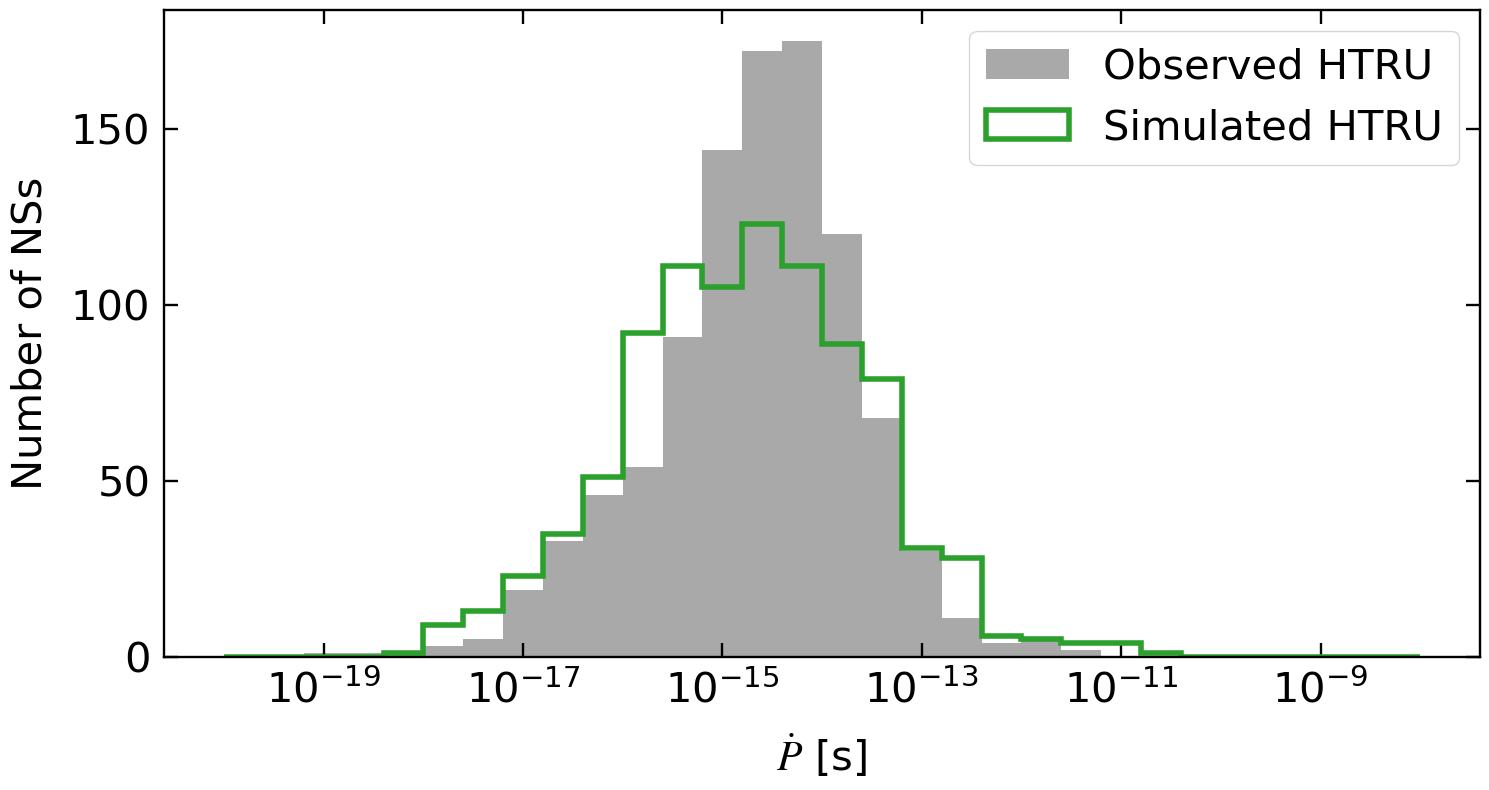

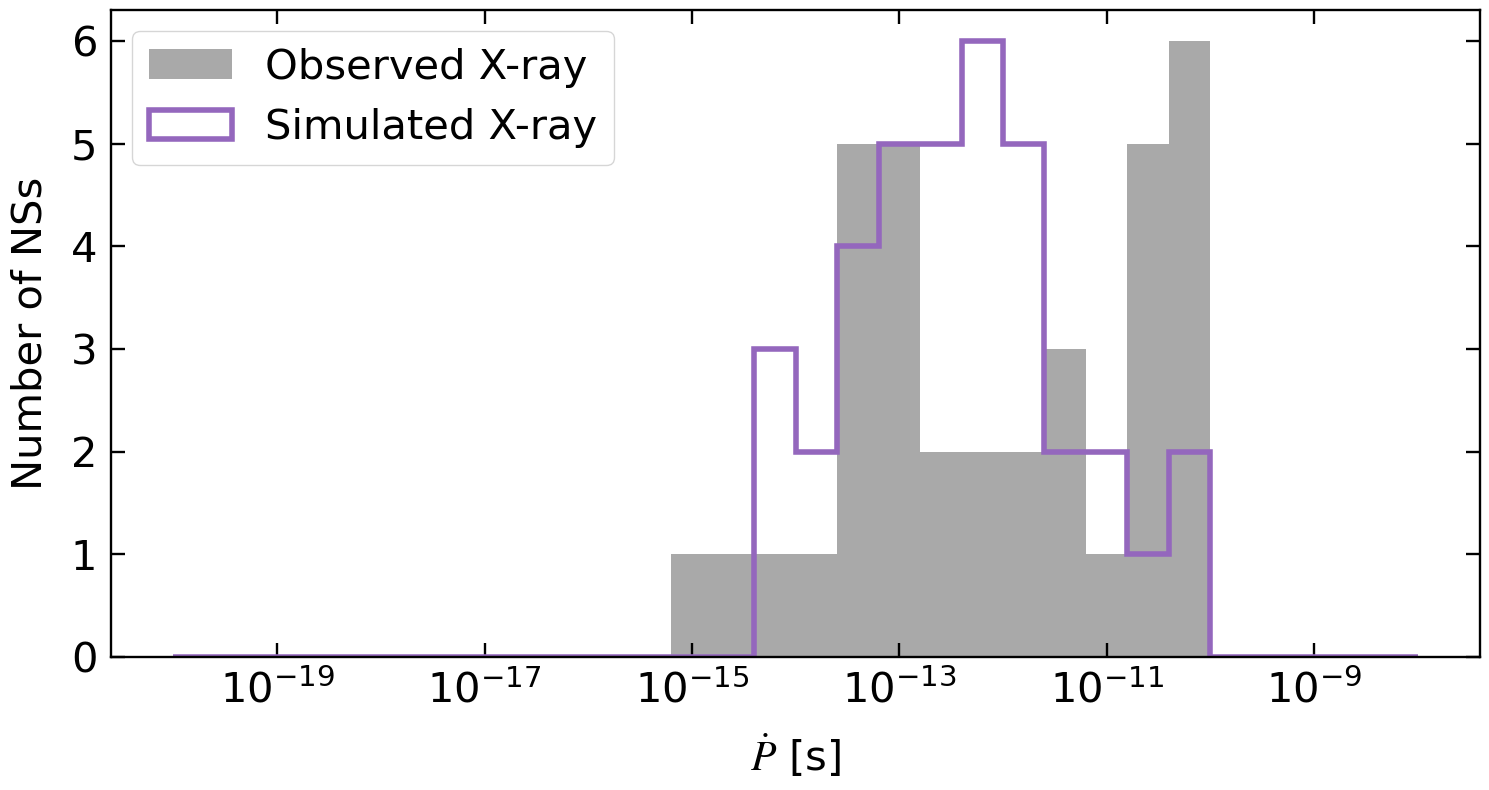

In [49]:
Pdot_bins = np.logspace(-20.0, -8.0, 31)

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    Pdot_pk_obs,
    bins=Pdot_bins,
    histtype="stepfilled",
    color="darkgray",
    lw=4,
    label="Observed PMPS",
)
ax.hist(
    Pdot_pk_sim,
    bins=Pdot_bins,
    histtype="step",
    edgecolor="tab:red",
    lw=4,
    label="Simulated PMPS",
)

plt.xlabel(r"$\dot{P}$ [s]")
plt.ylabel(r"Number of NSs")
plt.xscale("log")
ax.legend(frameon=True, loc=0)

plt.show()

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    Pdot_sw_obs,
    bins=Pdot_bins,
    histtype="stepfilled",
    color="darkgray",
    lw=4,
    label="Observed SMPS",
)
ax.hist(
    Pdot_sw_sim,
    bins=Pdot_bins,
    histtype="step",
    edgecolor="tab:blue",
    lw=4,
    label="Simulated SMPS",
)

plt.xlabel(r"$\dot{P}$ [s]")
plt.ylabel(r"Number of NSs")
plt.xscale("log")
ax.legend(frameon=True, loc=0)

plt.show()

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    Pdot_htru_obs,
    bins=Pdot_bins,
    histtype="stepfilled",
    color="darkgray",
    lw=4,
    label="Observed HTRU",
)
ax.hist(
    Pdot_htru_sim,
    bins=Pdot_bins,
    histtype="step",
    edgecolor="tab:green",
    lw=4,
    label="Simulated HTRU",
)

plt.xlabel(r"$\dot{P}$ [s]")
plt.ylabel(r"Number of NSs")
plt.xscale("log")
ax.legend(frameon=True, loc=0)

plt.show()

if survey_x:
    fig, ax = plt.subplots(figsize=(15, 8))

    ax.hist(
        Pdot_x_obs,
        bins=Pdot_bins,
        histtype="stepfilled",
        color="darkgray",
        lw=4,
        label="Observed X-ray",
    )
    ax.hist(
        Pdot_x_sim,
        bins=Pdot_bins,
        histtype="step",
        edgecolor="tab:purple",
        lw=4,
        label="Simulated X-ray",
    )

    plt.xlabel(r"$\dot{P}$ [s]")
    plt.ylabel(r"Number of NSs")
    plt.xscale("log")
    ax.legend(frameon=True, loc=0)

    plt.show()

Comparing PPdot diagrams.

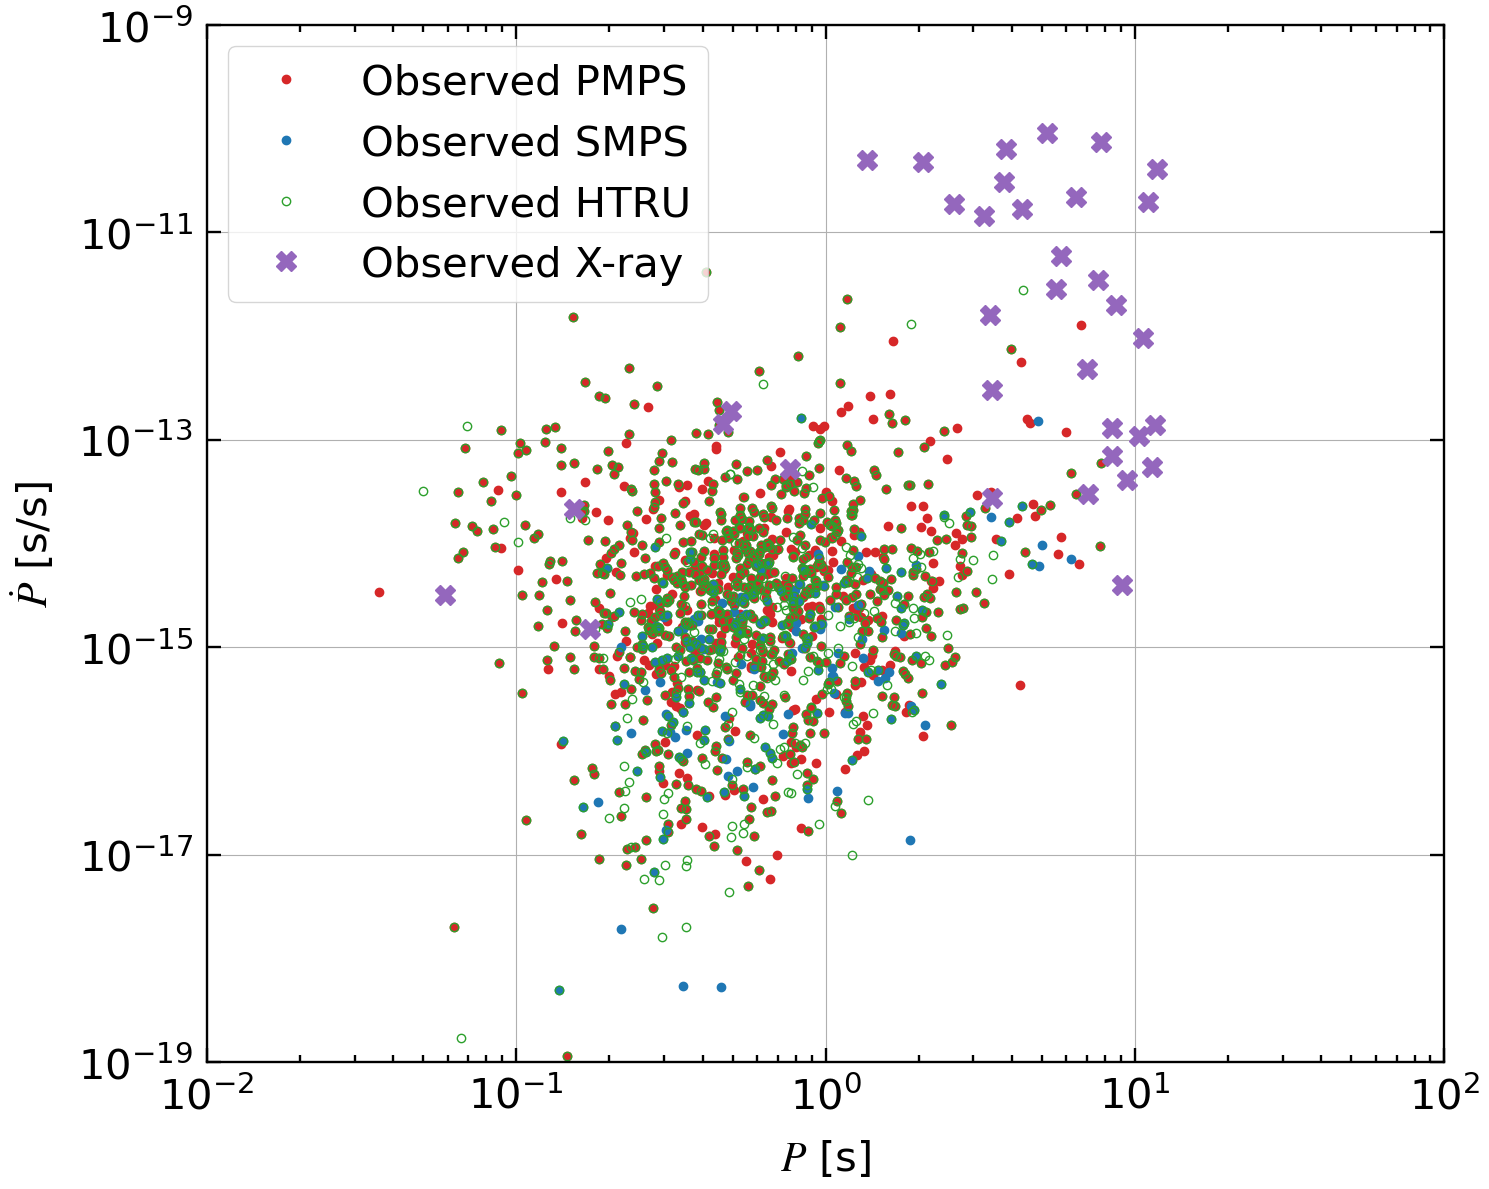

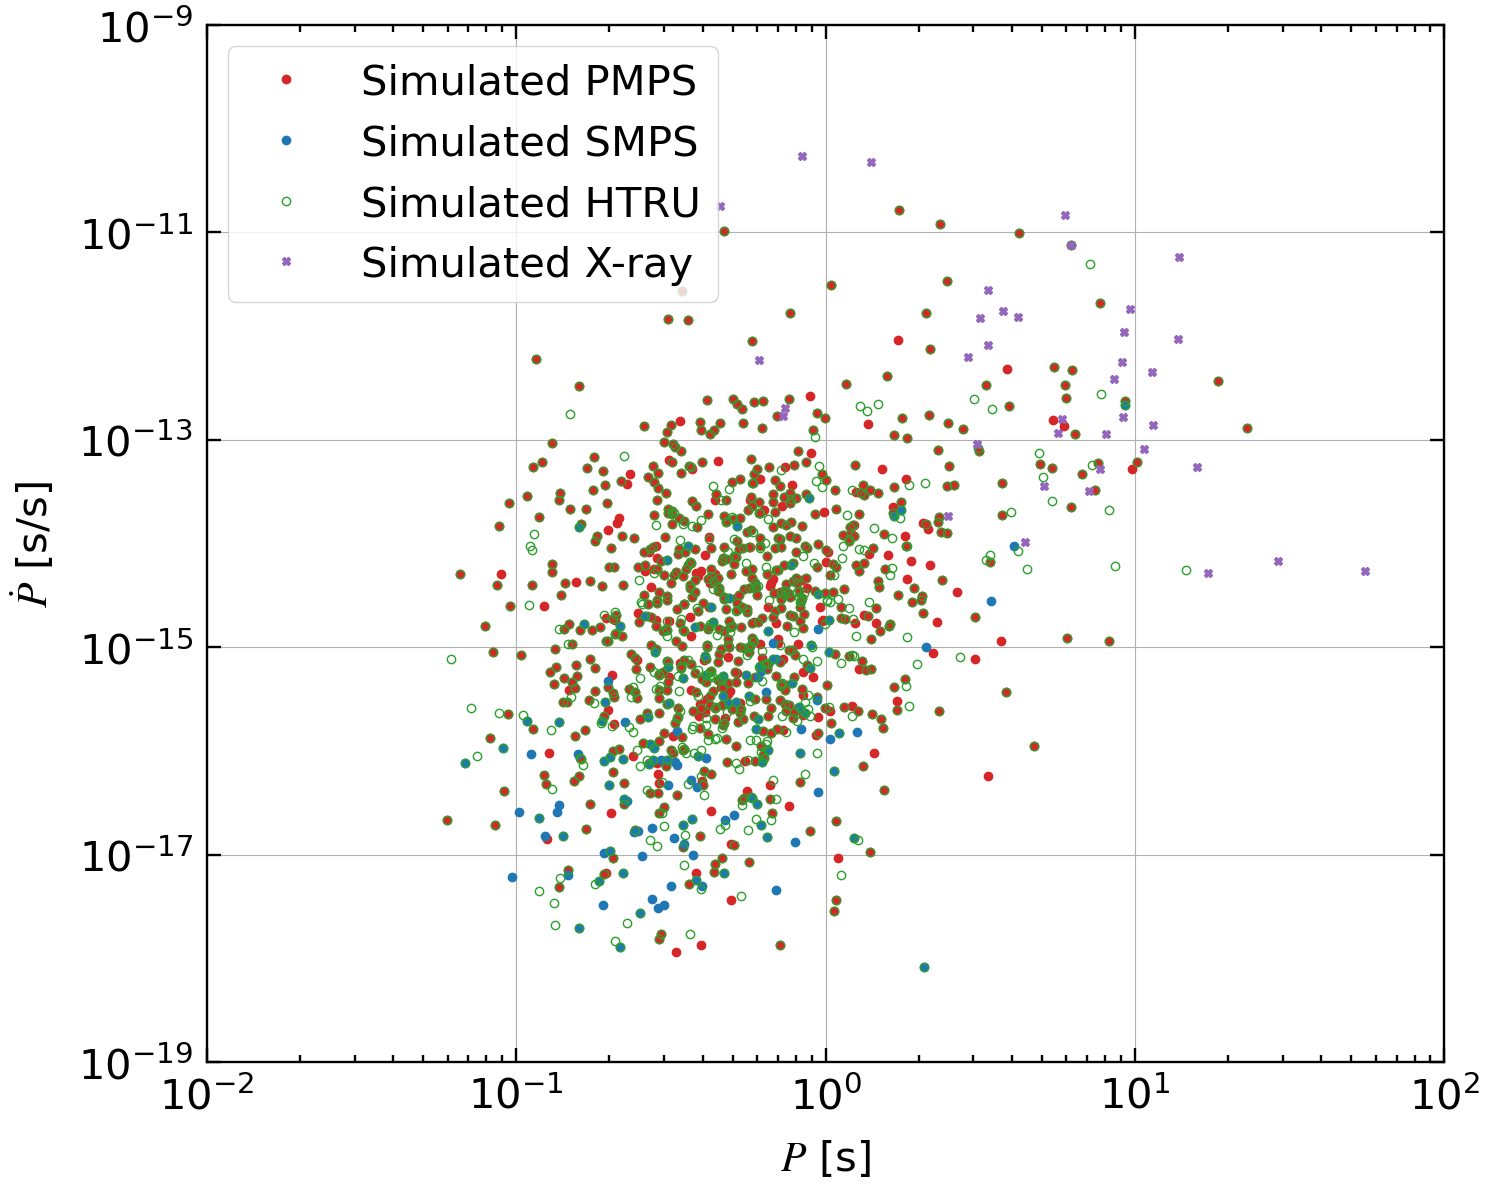

In [50]:
fig, ax = plt.subplots(figsize=(15, 12))

ax.plot(
    P_pk_obs,
    Pdot_pk_obs,
    linestyle="None",
    marker="o",
    color="tab:red",
    markersize=6,
    alpha=1.0,
    rasterized=True,
    label=r"Observed PMPS",
)
ax.plot(
    P_sw_obs,
    Pdot_sw_obs,
    linestyle="None",
    marker="o",
    color="tab:blue",
    markersize=6,
    alpha=1.0,
    rasterized=True,
    label=r"Observed SMPS",
)
ax.plot(
    P_htru_obs,
    Pdot_htru_obs,
    linestyle="None",
    marker="o",
    fillstyle="none",
    color="tab:green",
    markersize=6,
    alpha=1.0,
    rasterized=True,
    label=r"Observed HTRU",
)

if survey_x:
    ax.plot(
        P_x_obs,
        Pdot_x_obs,
        linestyle="None",
        marker="X",
        color="tab:purple",
        markersize=15,
        alpha=1.0,
        rasterized=True,
        label=r"Observed X-ray",
    )


ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1.0e-2, 100.0)
ax.set_ylim(1.0e-19, 1.0e-11)

plt.xlabel(r"$P$ [s]")
plt.ylabel(r"$\dot{P}$ [s/s]")
ax.set_ylim(1.0e-19, 1.0e-9)
ax.legend(frameon=True, loc=2)

plt.grid()

fig, ax = plt.subplots(figsize=(15, 12))

ax.plot(
    P_pk_sim,
    Pdot_pk_sim,
    linestyle="None",
    marker="o",
    color="tab:red",
    markersize=6,
    alpha=1.0,
    rasterized=True,
    label=r"Simulated PMPS",
)
ax.plot(
    P_sw_sim,
    Pdot_sw_sim,
    linestyle="None",
    marker="o",
    color="tab:blue",
    markersize=6,
    alpha=1.0,
    rasterized=True,
    label=r"Simulated SMPS",
)
ax.plot(
    P_htru_sim,
    Pdot_htru_sim,
    linestyle="None",
    marker="o",
    fillstyle="none",
    color="tab:green",
    markersize=6,
    alpha=1.0,
    rasterized=True,
    label=r"Simulated HTRU",
)

if survey_x:
    ax.plot(
        P_x_sim,
        Pdot_x_sim,
        linestyle="None",
        marker="X",
        color="tab:purple",
        markersize=6,
        alpha=1.0,
        rasterized=True,
        label=r"Simulated X-ray",
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1.0e-2, 100.0)
ax.set_ylim(1.0e-19, 1.0e-9)

plt.xlabel(r"$P$ [s]")
plt.ylabel(r"$\dot{P}$ [s/s]")
ax.legend(frameon=True, loc=2)

plt.grid()

Comparing the spin-down power distributions.

In [51]:
# Canonical neutron star moment of inertia in [g cm^2] assuming a perfect solid sphere.
NS_inertia = 2.0 / 5.0 * cfg["NS_mass"] * cfg["NS_radius"] ** 2

# Computing the spin-down power.
Erot_dot_pk_sim = (
    NS_inertia * (2.0 * np.pi) ** 2 * Pdot_pk_sim / (P_pk_sim**3)
)
Erot_dot_sw_sim = (
    NS_inertia * (2.0 * np.pi) ** 2 * Pdot_sw_sim / (P_sw_sim**3)
)
Erot_dot_htru_sim = (
    NS_inertia * (2.0 * np.pi) ** 2 * Pdot_htru_sim / (P_htru_sim**3)
)
if survey_x:
    Erot_dot_x_sim = (
        NS_inertia * (2.0 * np.pi) ** 2 * Pdot_x_sim / (P_x_sim**3)
    )

Erot_dot_pk_obs = (
    NS_inertia * (2.0 * np.pi) ** 2 * Pdot_pk_obs / (P_pk_obs**3)
)
Erot_dot_sw_obs = (
    NS_inertia * (2.0 * np.pi) ** 2 * Pdot_sw_obs / (P_sw_obs**3)
)
Erot_dot_htru_obs = (
    NS_inertia * (2.0 * np.pi) ** 2 * Pdot_htru_obs / (P_htru_obs**3)
)
if survey_x:
    Erot_dot_x_obs = NS_inertia * (2.0 * np.pi) ** 2 * Pdot_x_obs / (P_x_obs**3)

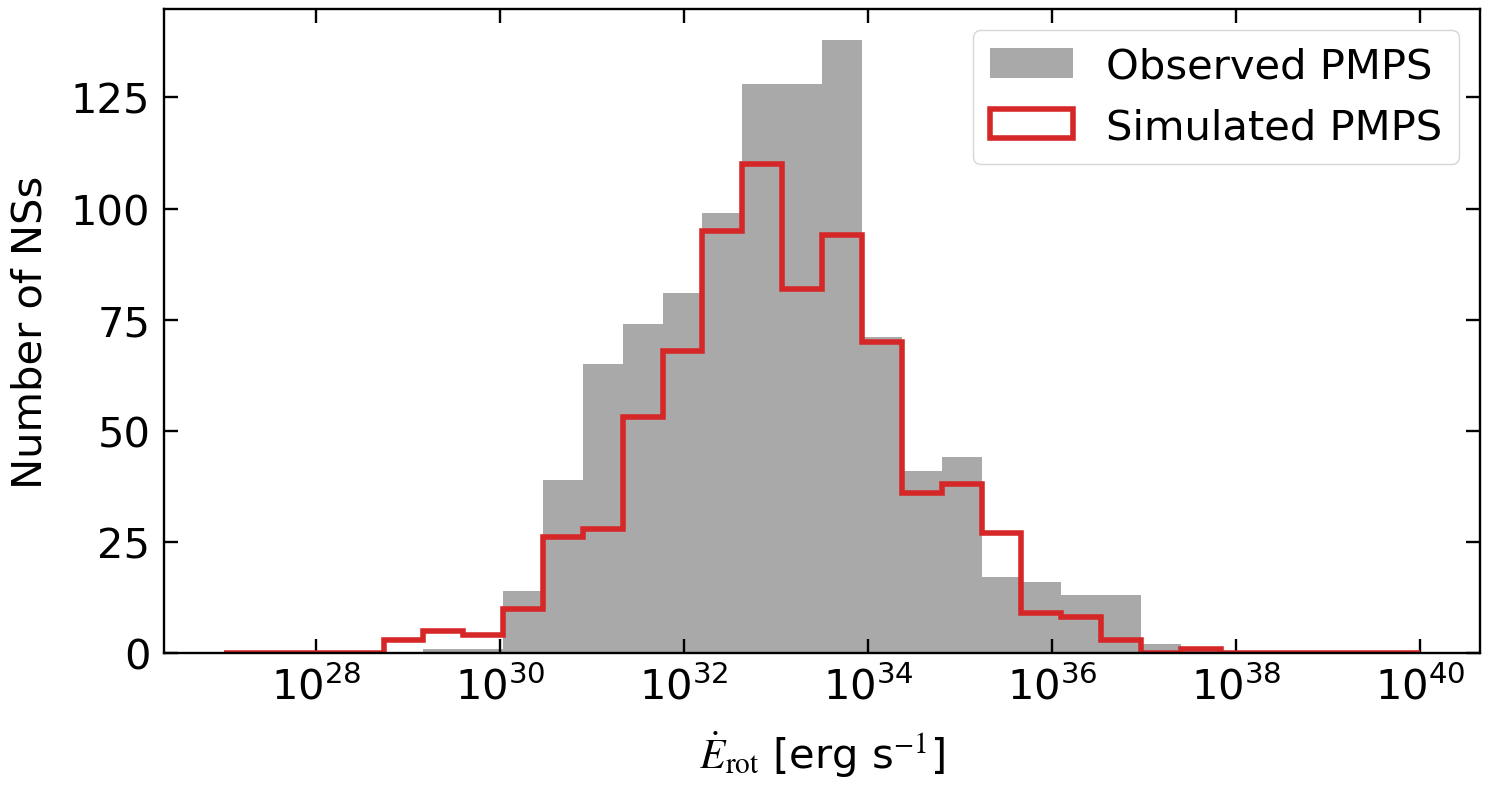

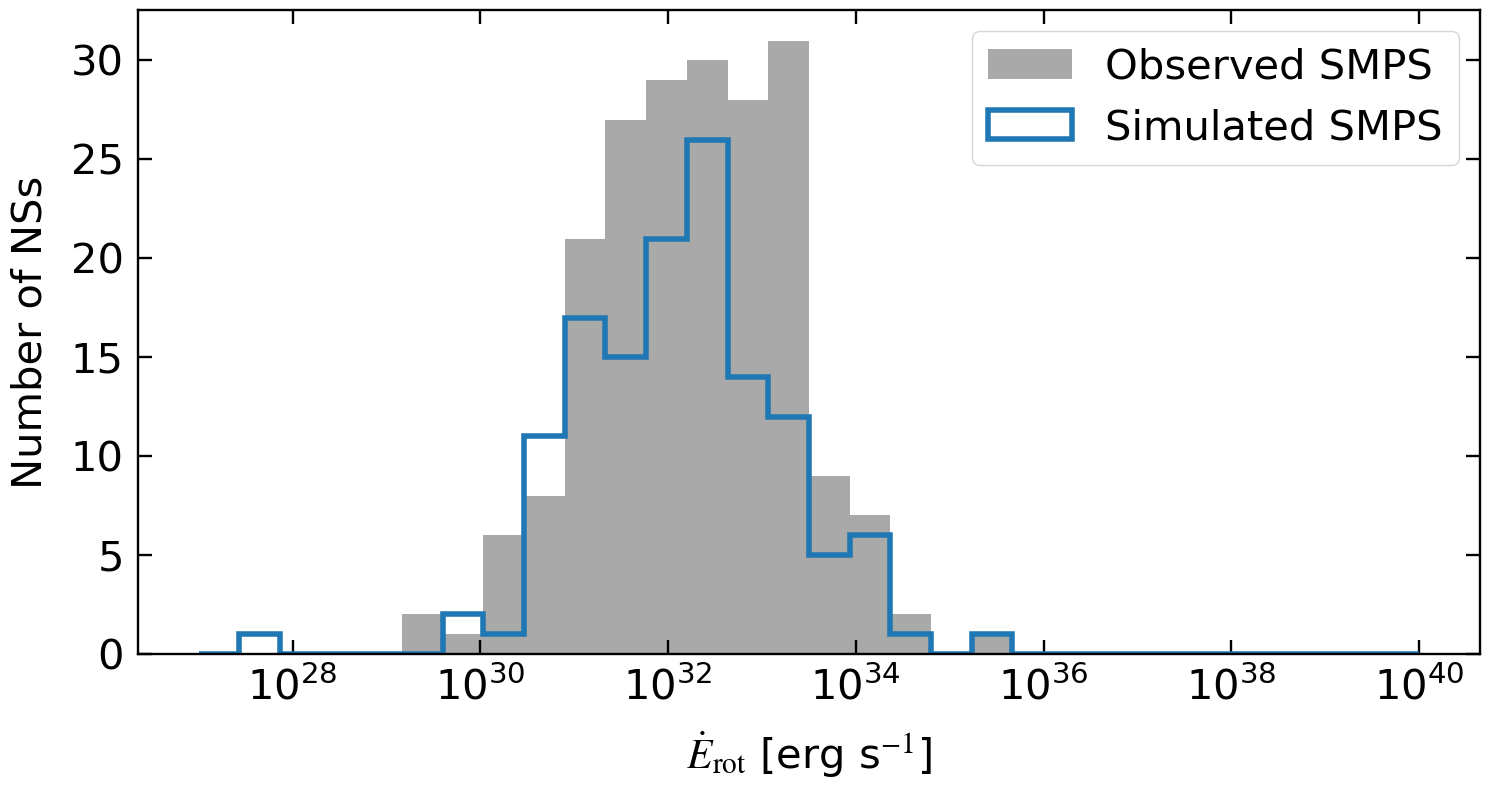

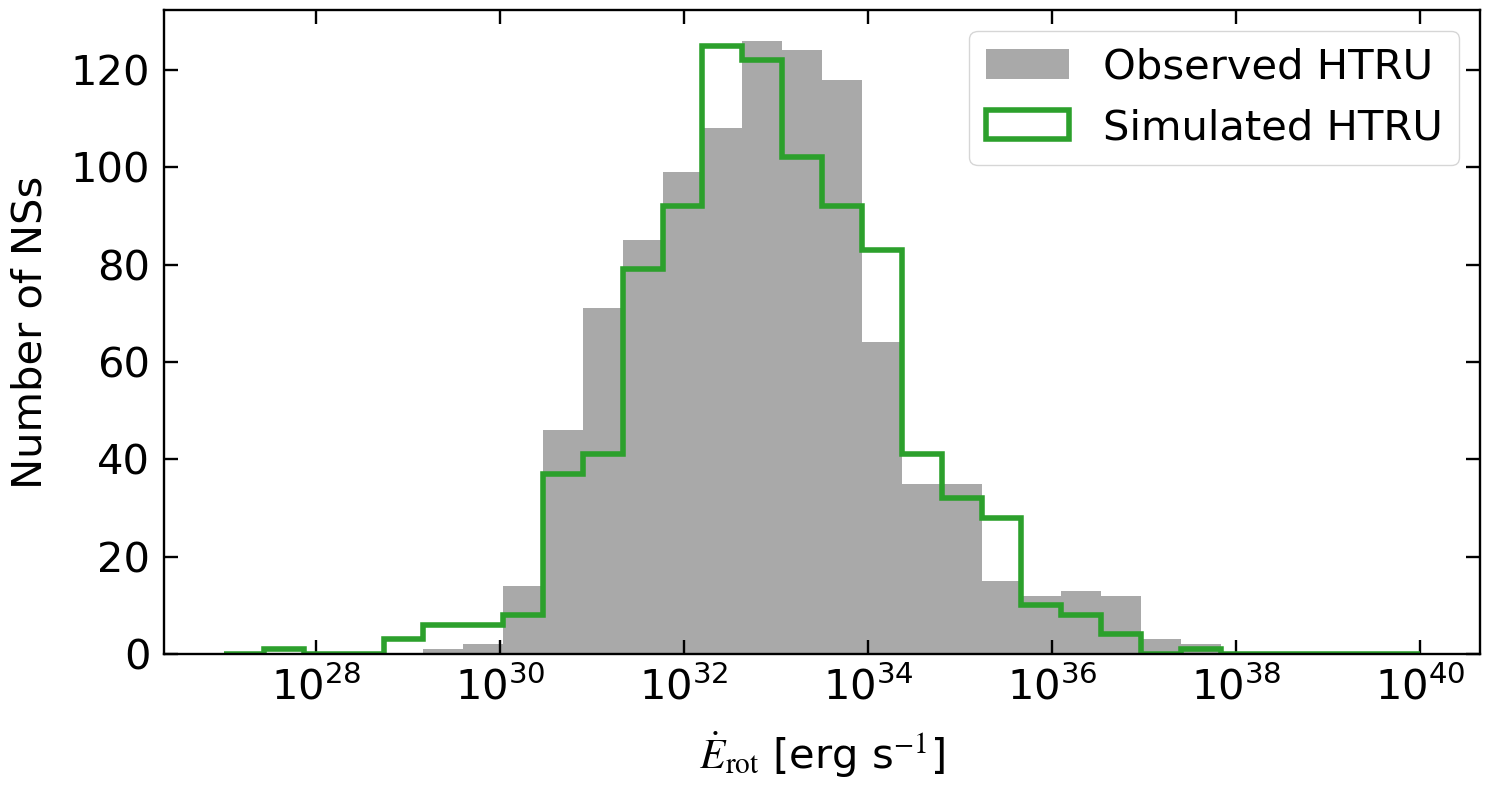

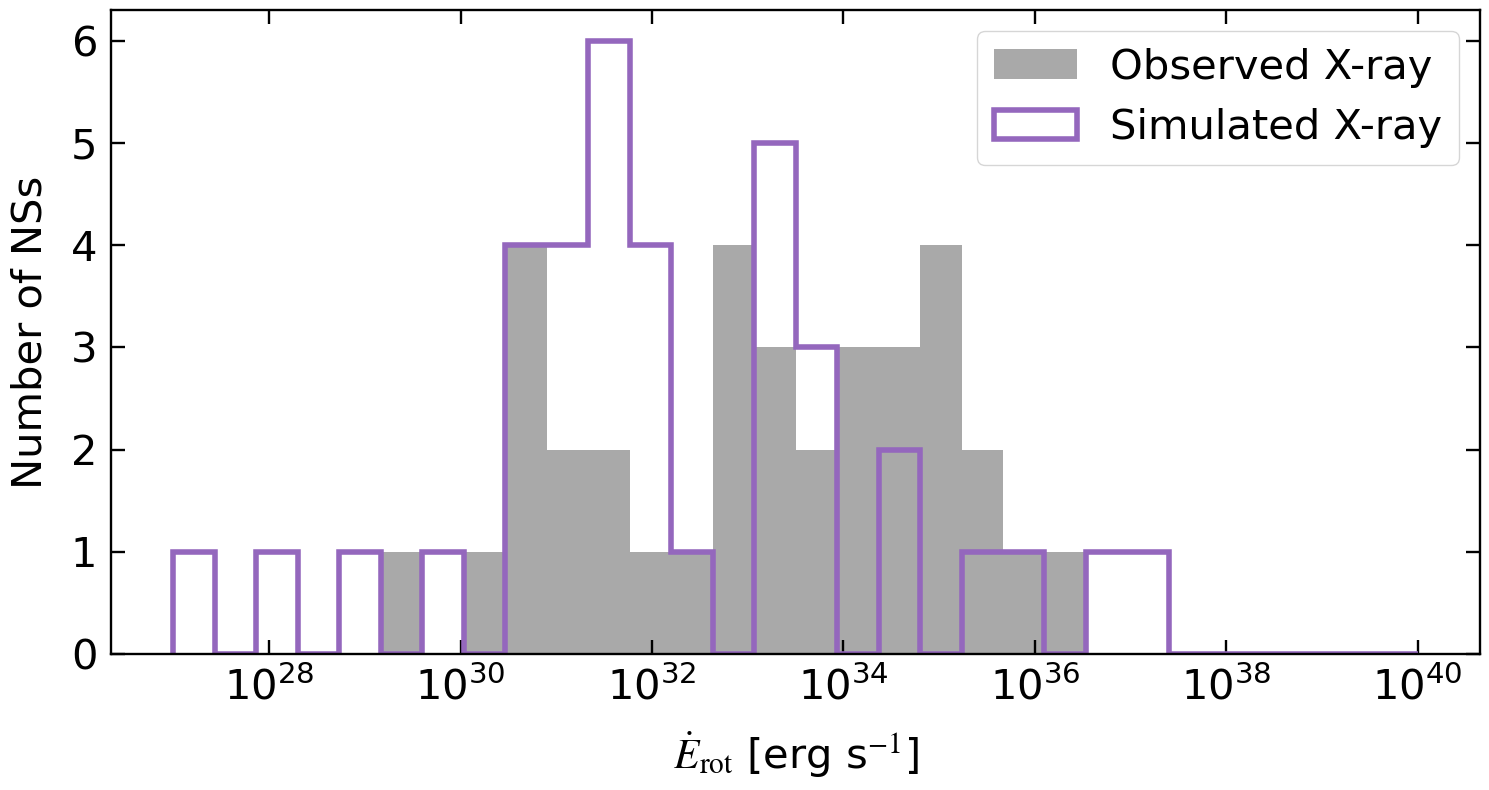

In [52]:
Erot_dot_bins = np.logspace(27.0, 40.0, 31)

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    Erot_dot_pk_obs,
    bins=Erot_dot_bins,
    histtype="stepfilled",
    color="darkgray",
    lw=4,
    label="Observed PMPS",
)
ax.hist(
    Erot_dot_pk_sim,
    bins=Erot_dot_bins,
    histtype="step",
    edgecolor="tab:red",
    lw=4,
    label="Simulated PMPS",
)
plt.xlabel(r"$\dot{E}_{\rm rot}$ [erg s$^{-1}$]")
plt.ylabel(r"Number of NSs")
ax.set_xscale("log")
ax.legend(frameon=True, loc=0)

plt.show()

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    Erot_dot_sw_obs,
    bins=Erot_dot_bins,
    histtype="stepfilled",
    color="darkgray",
    lw=4,
    label="Observed SMPS",
)
ax.hist(
    Erot_dot_sw_sim,
    bins=Erot_dot_bins,
    histtype="step",
    edgecolor="tab:blue",
    lw=4,
    label="Simulated SMPS",
)
plt.xlabel(r"$\dot{E}_{\rm rot}$ [erg s$^{-1}$]")
plt.ylabel(r"Number of NSs")
ax.set_xscale("log")
ax.legend(frameon=True, loc=0)

plt.show()

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    Erot_dot_htru_obs,
    bins=Erot_dot_bins,
    histtype="stepfilled",
    color="darkgray",
    lw=4,
    label="Observed HTRU",
)
ax.hist(
    Erot_dot_htru_sim,
    bins=Erot_dot_bins,
    histtype="step",
    edgecolor="tab:green",
    lw=4,
    label="Simulated HTRU",
)
plt.xlabel(r"$\dot{E}_{\rm rot}$ [erg s$^{-1}$]")
plt.ylabel(r"Number of NSs")
ax.set_xscale("log")
ax.legend(frameon=True, loc=0)

plt.show()

if survey_x:
    fig, ax = plt.subplots(figsize=(15, 8))

    ax.hist(
        Erot_dot_x_obs,
        bins=Erot_dot_bins,
        histtype="stepfilled",
        color="darkgray",
        lw=4,
        label="Observed X-ray",
    )
    ax.hist(
        Erot_dot_x_sim,
        bins=Erot_dot_bins,
        histtype="step",
        edgecolor="tab:purple",
        lw=4,
        label="Simulated X-ray",
    )
    plt.xlabel(r"$\dot{E}_{\rm rot}$ [erg s$^{-1}$]")
    plt.ylabel(r"Number of NSs")
    ax.set_xscale("log")
    ax.legend(frameon=True, loc=0)

    plt.show()

Comparing the characteristic age distributions.

In [53]:
age_char_pk_obs = P_pk_obs / (2 * Pdot_pk_obs) / const.YR_TO_S
age_char_sw_obs = P_sw_obs / (2 * Pdot_sw_obs) / const.YR_TO_S
age_char_htru_obs = P_htru_obs / (2 * Pdot_htru_obs) / const.YR_TO_S
age_char_x_obs = P_x_obs / (2 * Pdot_x_obs) / const.YR_TO_S

age_char_pk_sim = P_pk_sim / (2 * Pdot_pk_sim) / const.YR_TO_S
age_char_sw_sim = P_sw_sim / (2 * Pdot_sw_sim) / const.YR_TO_S
age_char_htru_sim = P_htru_sim / (2 * Pdot_htru_sim) / const.YR_TO_S

if survey_x:
    age_char_x_sim = P_x_sim / (2 * Pdot_x_sim) / const.YR_TO_S

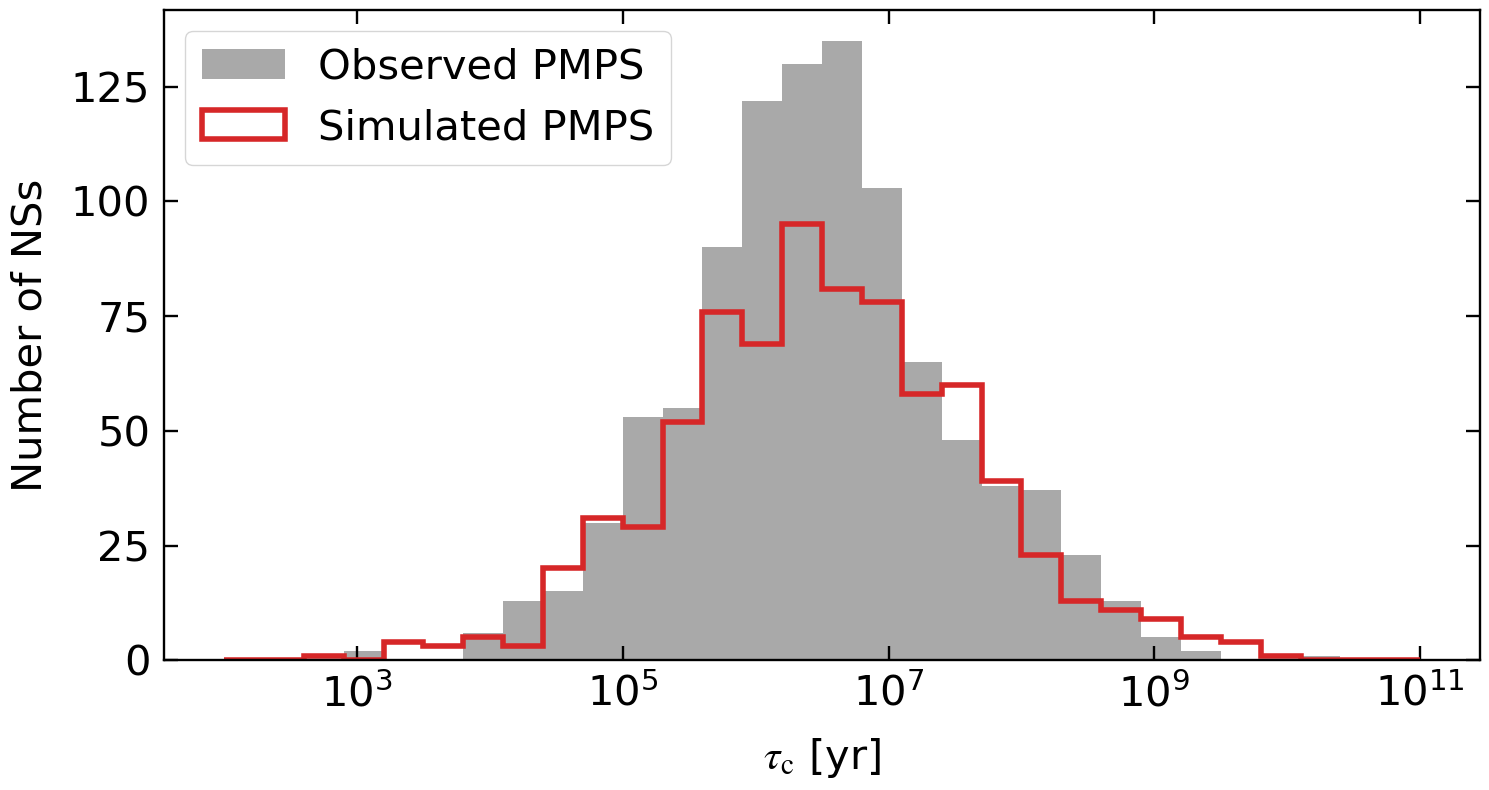

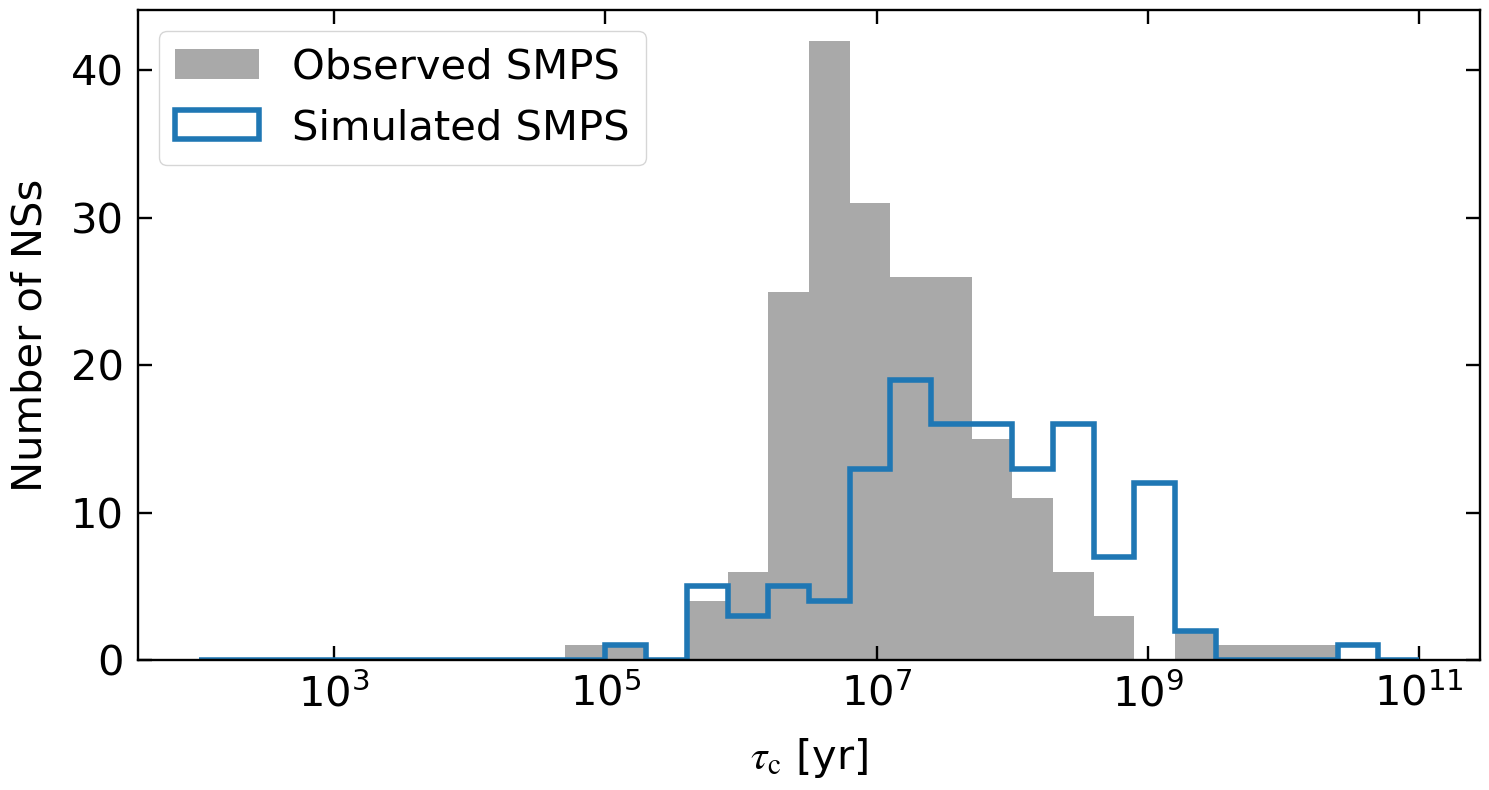

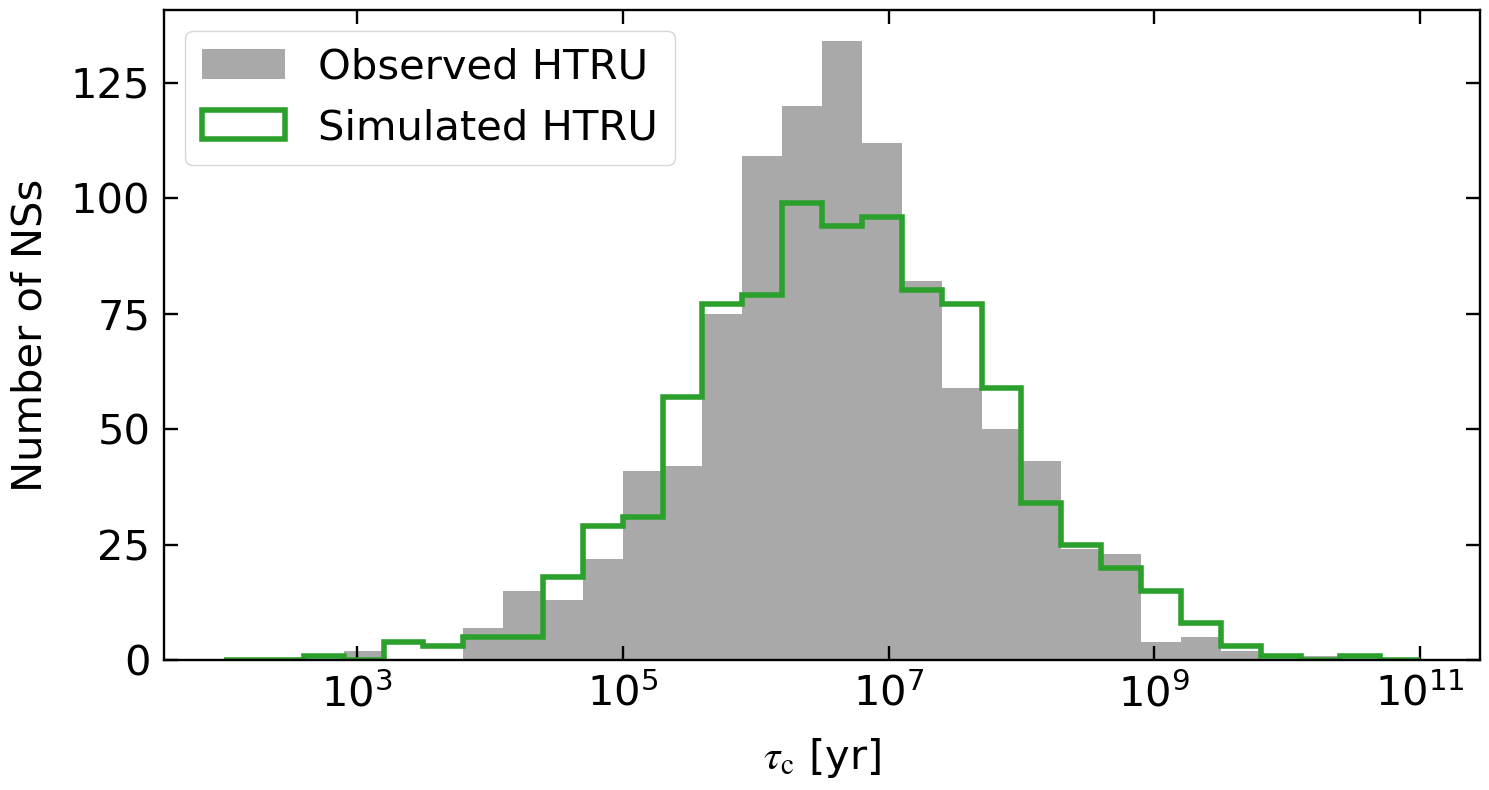

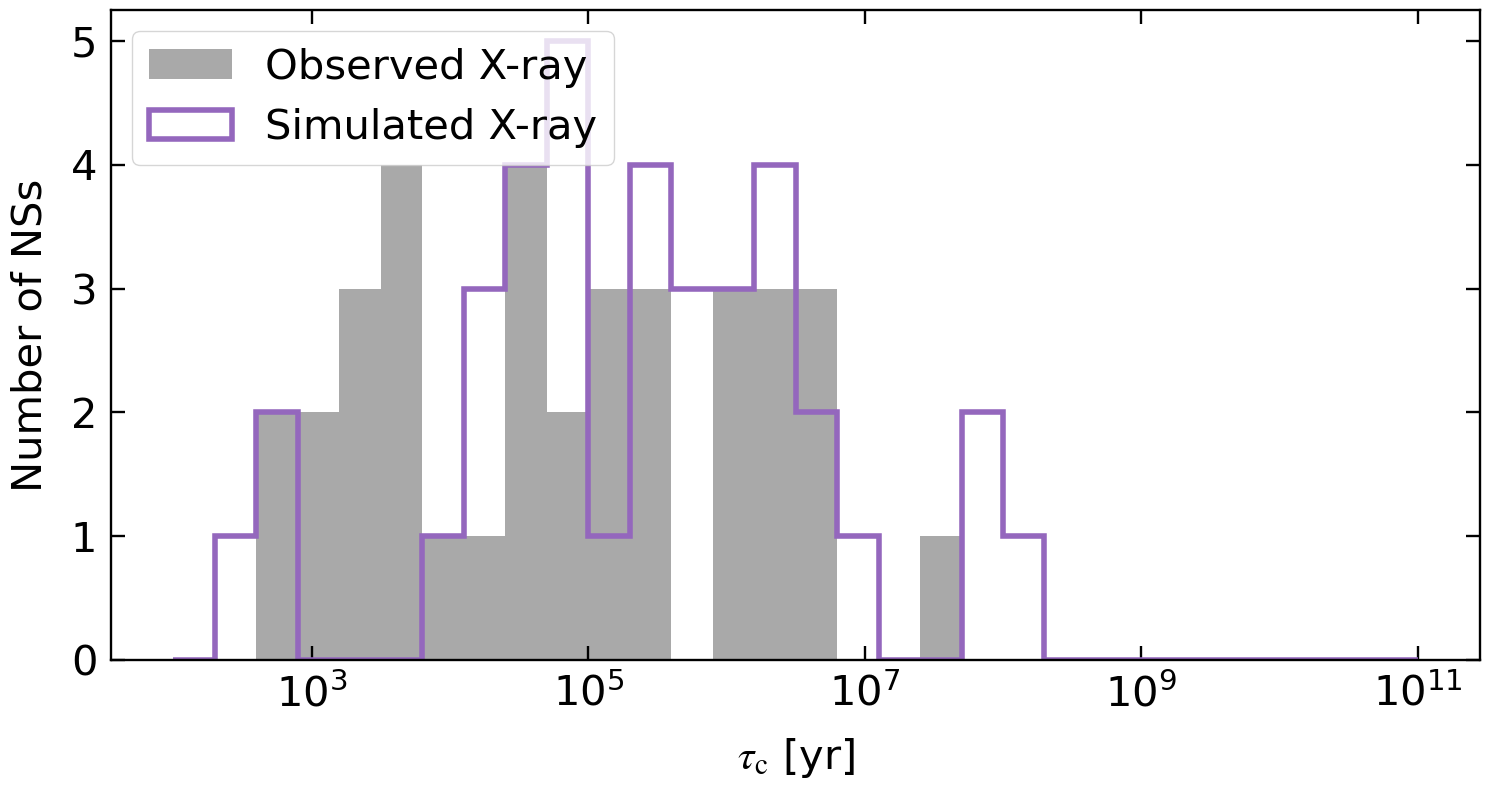

In [54]:
age_char_bins = np.logspace(2, 11.0, 31)

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    age_char_pk_obs,
    bins=age_char_bins,
    histtype="stepfilled",
    color="darkgray",
    lw=4,
    label="Observed PMPS",
)
ax.hist(
    age_char_pk_sim,
    bins=age_char_bins,
    histtype="step",
    edgecolor="tab:red",
    lw=4,
    label="Simulated PMPS",
)
plt.xlabel(r"$\tau_{\rm c}$ [yr]")
plt.ylabel(r"Number of NSs")
ax.set_xscale("log")
ax.legend(frameon=True, loc=2)

plt.show()

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    age_char_sw_obs,
    bins=age_char_bins,
    histtype="stepfilled",
    color="darkgray",
    lw=4,
    label="Observed SMPS",
)
ax.hist(
    age_char_sw_sim,
    bins=age_char_bins,
    histtype="step",
    edgecolor="tab:blue",
    lw=4,
    label="Simulated SMPS",
)
plt.xlabel(r"$\tau_{\rm c}$ [yr]")
plt.ylabel(r"Number of NSs")
ax.set_xscale("log")
ax.legend(frameon=True, loc=2)

plt.show()

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    age_char_htru_obs,
    bins=age_char_bins,
    histtype="stepfilled",
    color="darkgray",
    lw=4,
    label="Observed HTRU",
)
ax.hist(
    age_char_htru_sim,
    bins=age_char_bins,
    histtype="step",
    edgecolor="tab:green",
    lw=4,
    label="Simulated HTRU",
)
plt.xlabel(r"$\tau_{\rm c}$ [yr]")
plt.ylabel(r"Number of NSs")
ax.set_xscale("log")
ax.legend(frameon=True, loc=2)

plt.show()

if survey_x:
    fig, ax = plt.subplots(figsize=(15, 8))

    ax.hist(
        age_char_x_obs,
        bins=age_char_bins,
        histtype="stepfilled",
        color="darkgray",
        lw=4,
        label="Observed X-ray",
    )
    ax.hist(
        age_char_x_sim,
        bins=age_char_bins,
        histtype="step",
        edgecolor="tab:purple",
        lw=4,
        label="Simulated X-ray",
    )
    plt.xlabel(r"$\tau_{\rm c}$ [yr]")
    plt.ylabel(r"Number of NSs")
    ax.set_xscale("log")
    ax.legend(frameon=True, loc=2)

    plt.show()

Comparing the magnetic field distributions assuming inclination angle $\chi = 0$ deg.

In [55]:
B_pk_obs = np.sqrt(1.0 / beta_1 * P_pk_obs * Pdot_pk_obs)
B_sw_obs = np.sqrt(1.0 / beta_1 * P_sw_obs * Pdot_sw_obs)
B_htru_obs = np.sqrt(1.0 / beta_1 * P_htru_obs * Pdot_htru_obs)
B_x_obs = np.sqrt(1.0 / beta_1 * P_x_obs * Pdot_x_obs)

B_pk_sim = np.sqrt(1.0 / beta_1 * P_pk_sim * Pdot_pk_sim)
B_sw_sim = np.sqrt(1.0 / beta_1 * P_sw_sim * Pdot_sw_sim)
B_htru_sim = np.sqrt(1.0 / beta_1 * P_htru_sim * Pdot_htru_sim)
if survey_x:
    B_x_sim = np.sqrt(1.0 / beta_1 * P_x_sim * Pdot_x_sim)

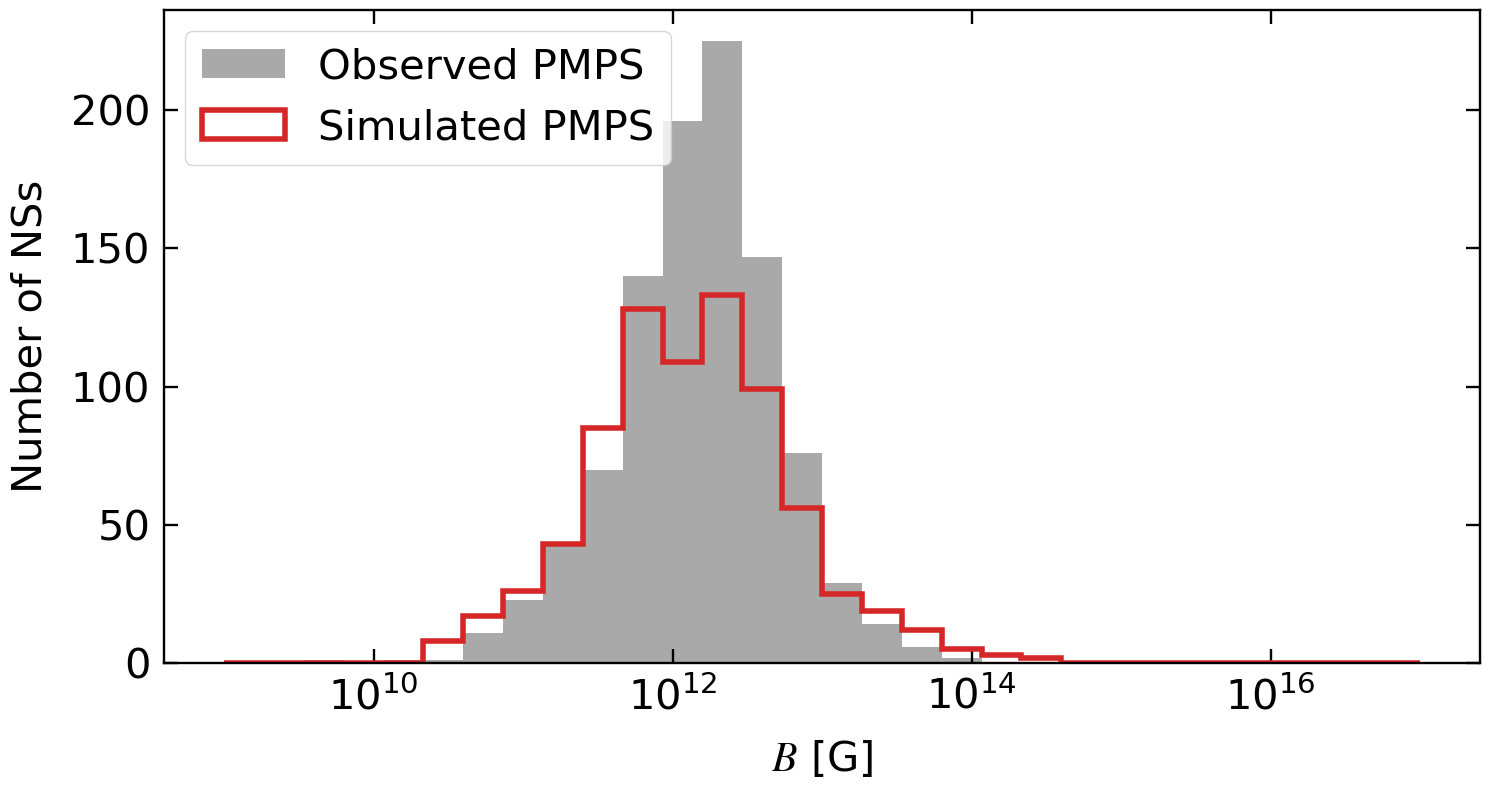

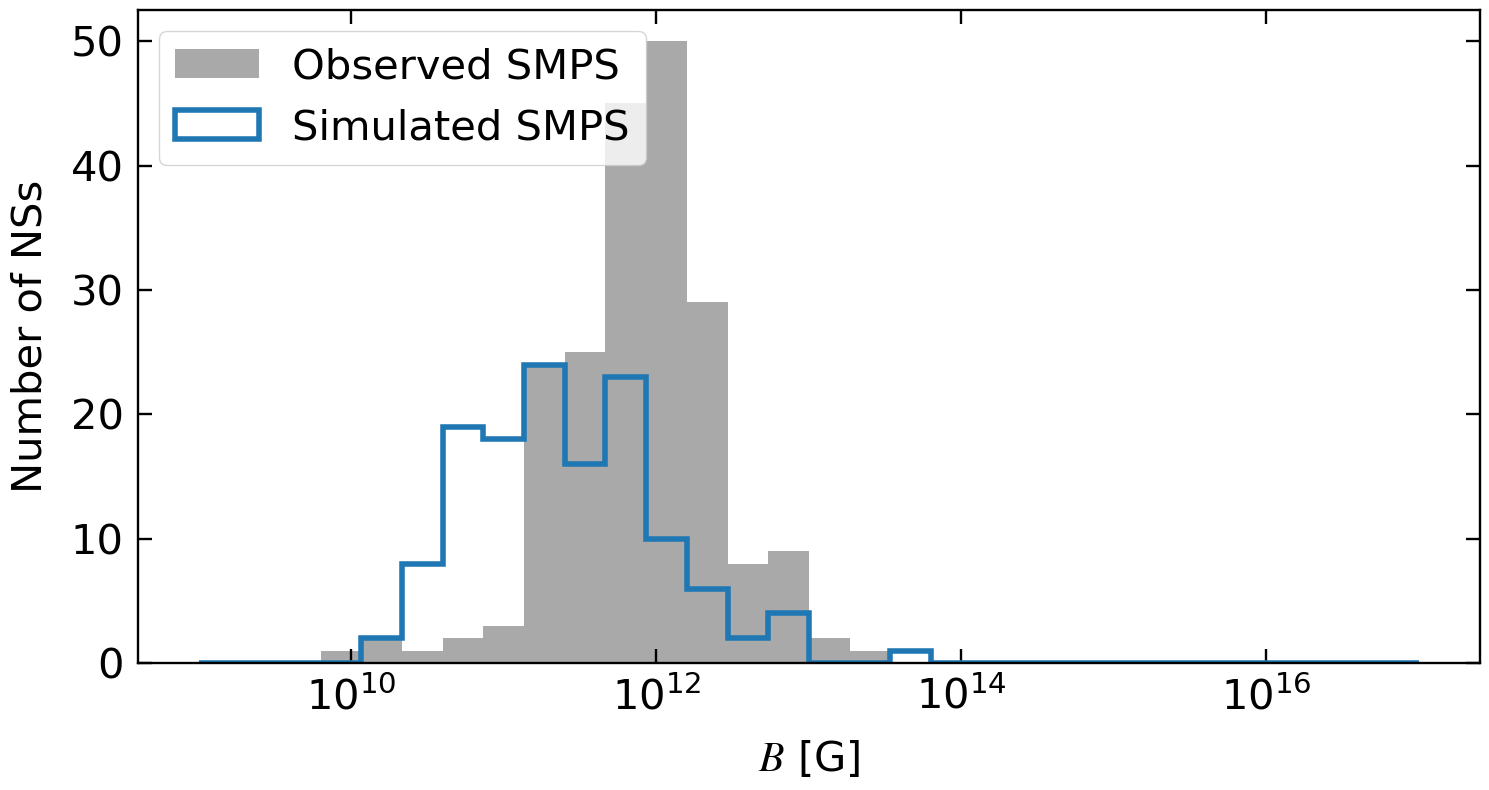

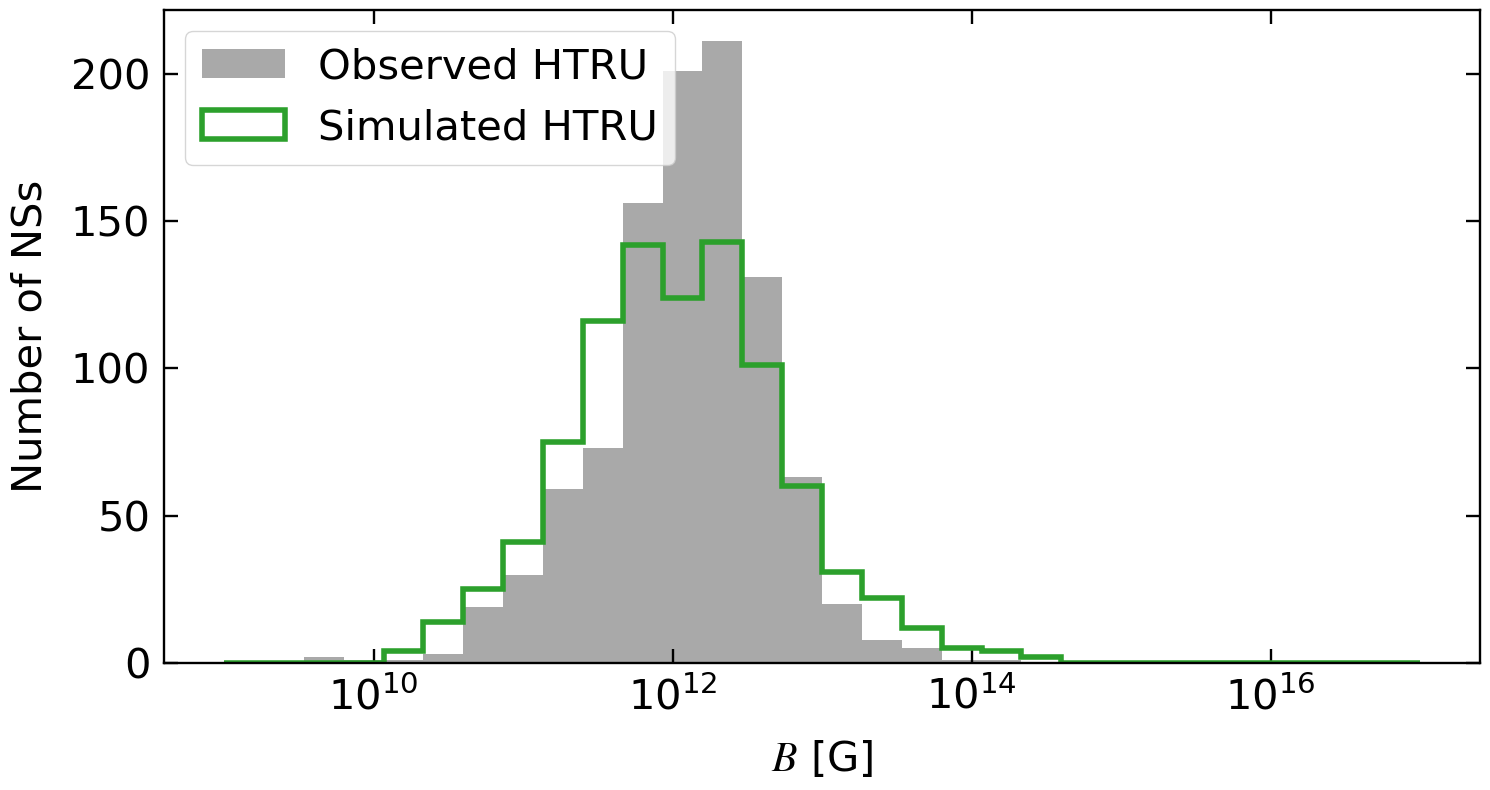

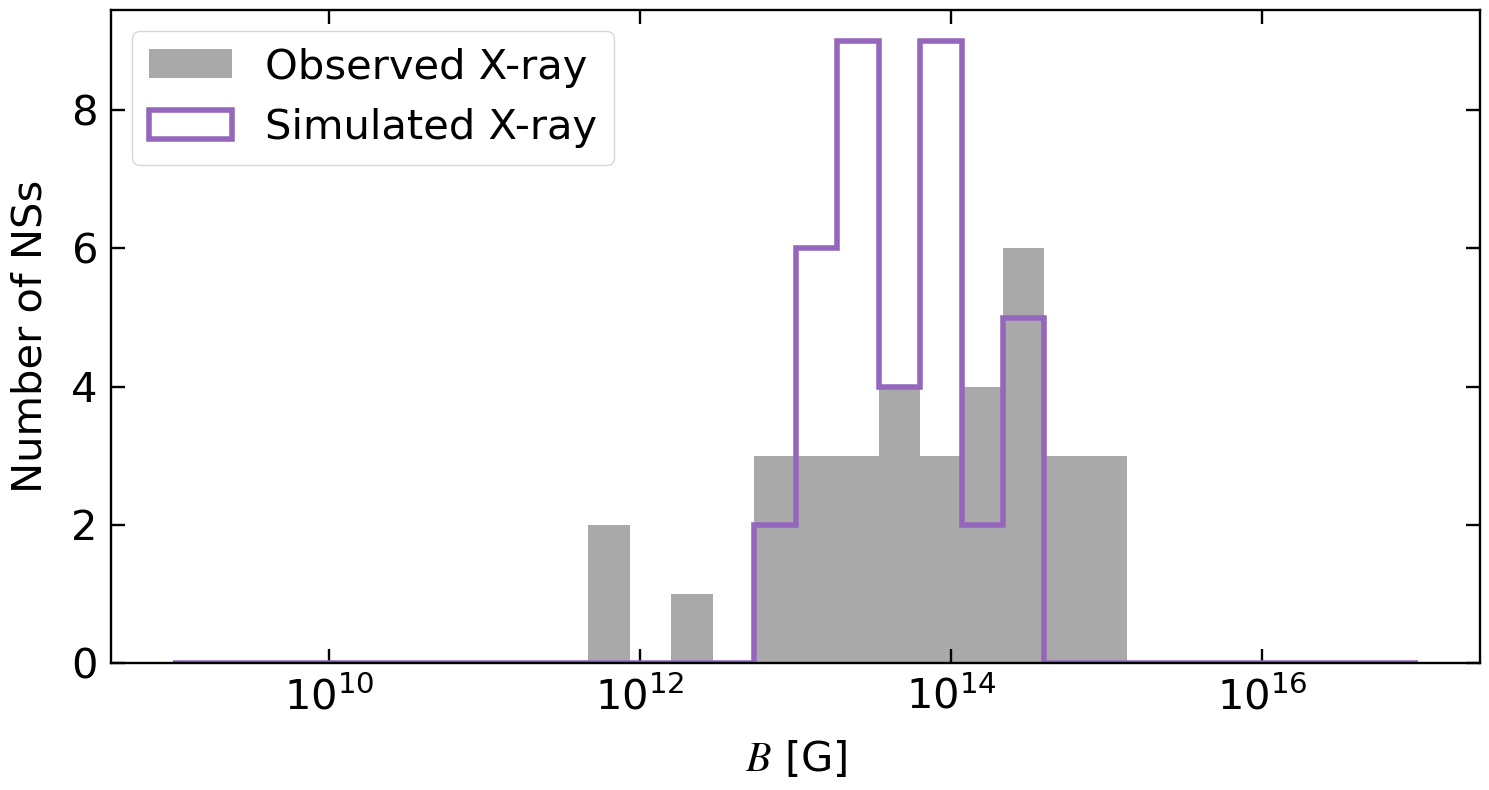

In [56]:
B_bins = np.logspace(9.0, 17.0, 31)

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    B_pk_obs,
    bins=B_bins,
    histtype="stepfilled",
    color="darkgray",
    lw=4,
    label="Observed PMPS",
)
ax.hist(
    B_pk_sim,
    bins=B_bins,
    histtype="step",
    edgecolor="tab:red",
    lw=4,
    label="Simulated PMPS",
)
plt.xlabel(r"$B$ [G]")
plt.ylabel(r"Number of NSs")
ax.set_xscale("log")
ax.legend(frameon=True, loc=2)

plt.show()

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    B_sw_obs,
    bins=B_bins,
    histtype="stepfilled",
    color="darkgray",
    lw=4,
    label="Observed SMPS",
)
ax.hist(
    B_sw_sim,
    bins=B_bins,
    histtype="step",
    edgecolor="tab:blue",
    lw=4,
    label="Simulated SMPS",
)
plt.xlabel(r"$B$ [G]")
plt.ylabel(r"Number of NSs")
ax.set_xscale("log")
ax.legend(frameon=True, loc=2)

plt.show()

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    B_htru_obs,
    bins=B_bins,
    histtype="stepfilled",
    color="darkgray",
    lw=4,
    label="Observed HTRU",
)
ax.hist(
    B_htru_sim,
    bins=B_bins,
    histtype="step",
    edgecolor="tab:green",
    lw=4,
    label="Simulated HTRU",
)
plt.xlabel(r"$B$ [G]")
plt.ylabel(r"Number of NSs")
ax.set_xscale("log")
ax.legend(frameon=True, loc=2)

plt.show()

if survey_x:
    fig, ax = plt.subplots(figsize=(15, 8))

    ax.hist(
        B_x_obs,
        bins=B_bins,
        histtype="stepfilled",
        color="darkgray",
        lw=4,
        label="Observed X-ray",
    )
    ax.hist(
        B_x_sim,
        bins=B_bins,
        histtype="step",
        edgecolor="tab:purple",
        lw=4,
        label="Simulated X-ray",
    )
    plt.xlabel(r"$B$ [G]")
    plt.ylabel(r"Number of NSs")
    ax.set_xscale("log")
    ax.legend(frameon=True, loc=2)

    plt.show()

Comparing the radio-flux distributions.

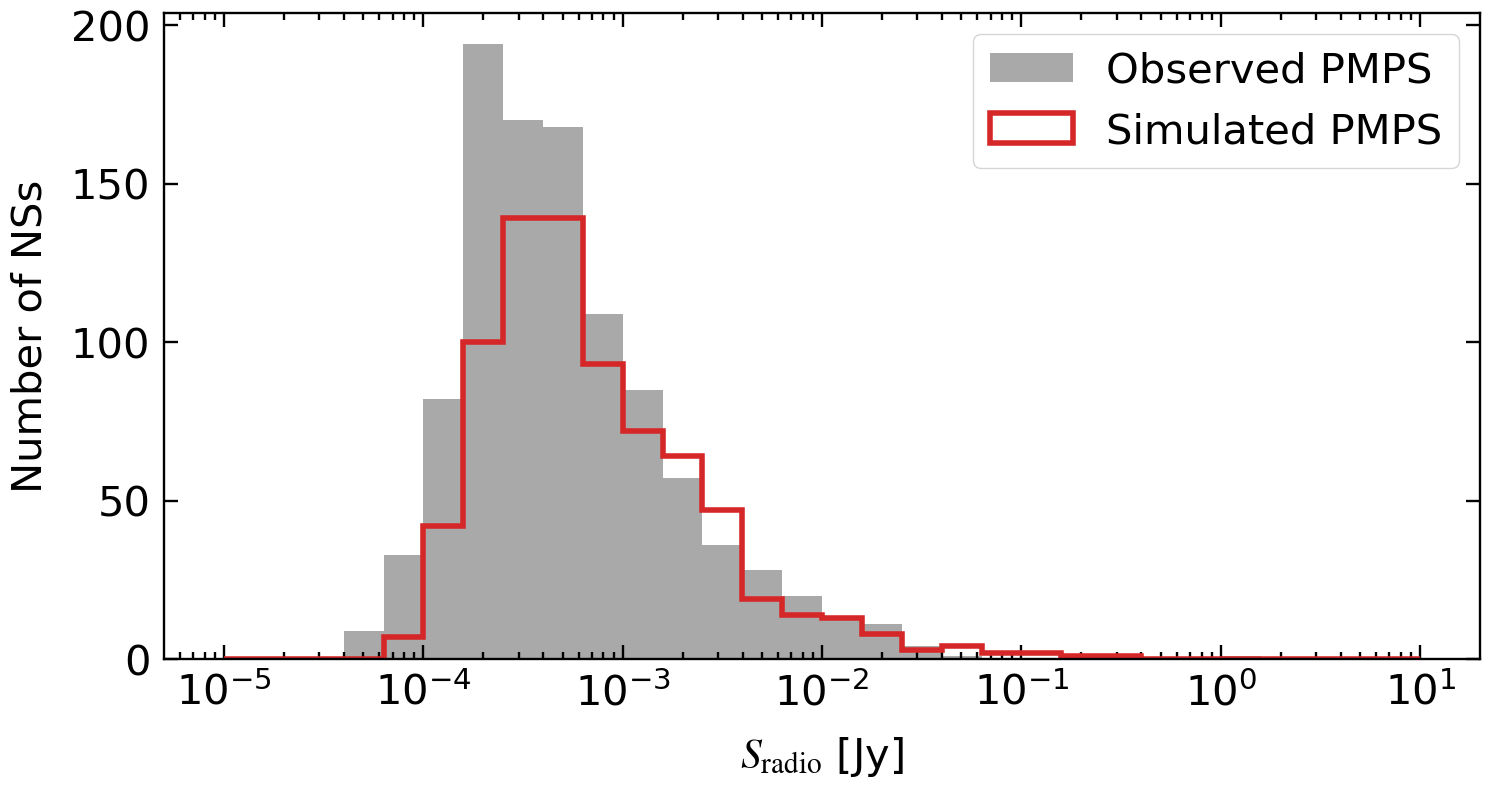

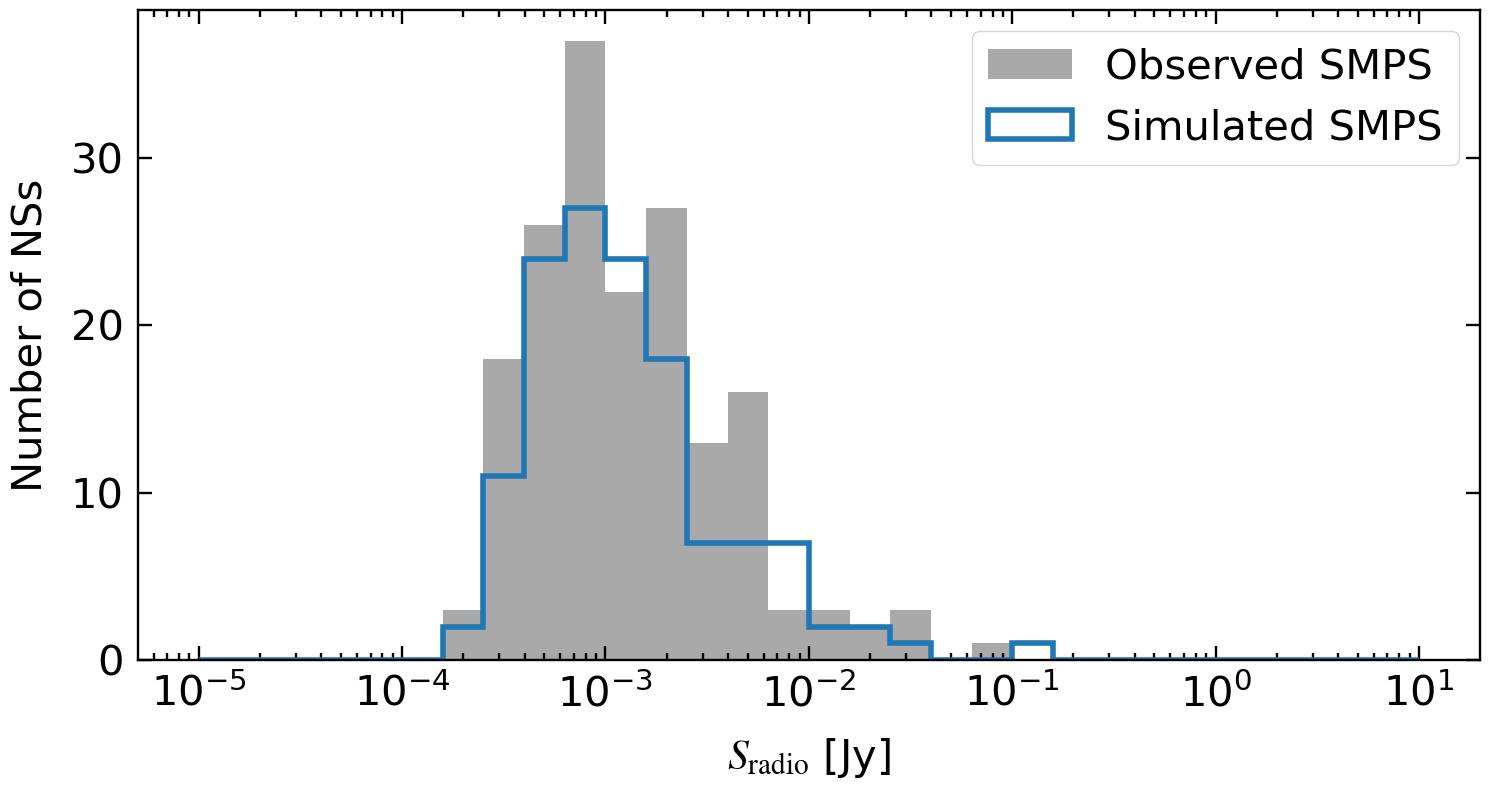

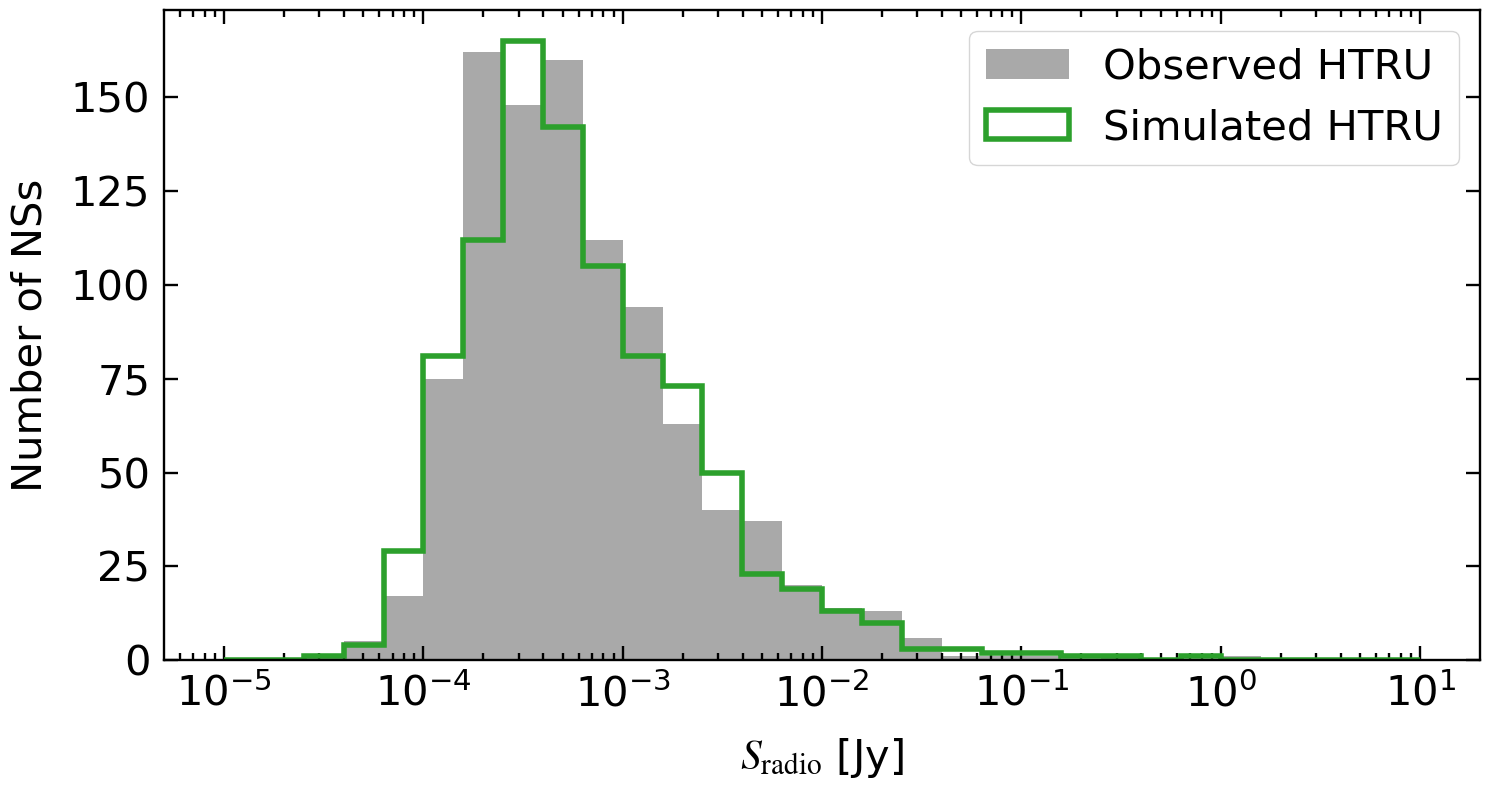

In [57]:
S_radio_bins = np.logspace(-5, 1, 31)

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    S1400_pk_obs / 1000.0,
    bins=S_radio_bins,
    histtype="stepfilled",
    color="darkgray",
    lw=4,
    label="Observed PMPS",
)
ax.hist(
    S1400_pk_sim,
    bins=S_radio_bins,
    histtype="step",
    edgecolor="tab:red",
    lw=4,
    label="Simulated PMPS",
)
plt.xlabel(r"$S_{\rm radio}$ [Jy]")
plt.ylabel(r"Number of NSs")
ax.set_xscale("log")
ax.legend(frameon=True, loc=0)

plt.show()

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    S1400_sw_obs / 1000.0,
    bins=S_radio_bins,
    histtype="stepfilled",
    color="darkgray",
    lw=4,
    label="Observed SMPS",
)
ax.hist(
    S1400_sw_sim,
    bins=S_radio_bins,
    histtype="step",
    edgecolor="tab:blue",
    lw=4,
    label="Simulated SMPS",
)
plt.xlabel(r"$S_{\rm radio}$ [Jy]")
plt.ylabel(r"Number of NSs")
ax.set_xscale("log")
ax.legend(frameon=True, loc=0)

plt.show()

fig, ax = plt.subplots(figsize=(15, 8))

ax.hist(
    S1400_htru_obs / 1000.0,
    bins=S_radio_bins,
    histtype="stepfilled",
    color="darkgray",
    lw=4,
    label="Observed HTRU",
)
ax.hist(
    S1400_htru_sim,
    bins=S_radio_bins,
    histtype="step",
    edgecolor="tab:green",
    lw=4,
    label="Simulated HTRU",
)
plt.xlabel(r"$S_{\rm radio}$ [Jy]")
plt.ylabel(r"Number of NSs")
ax.set_xscale("log")
ax.legend(frameon=True, loc=0)

plt.show()

In [58]:
L_pseudo_radio_pk_obs = (
    S1400_pk_obs
    * const.MILLIJY_TO_ERG
    * (dist_pk_obs * const.KPC_TO_CM) ** 2
    * 1.374e9
)
L_pseudo_radio_sw_obs = (
    S1400_sw_obs
    * const.MILLIJY_TO_ERG
    * (dist_sw_obs * const.KPC_TO_CM) ** 2
    * 1.374e9
)
L_pseudo_radio_htru_obs = (
    S1400_htru_obs
    * const.MILLIJY_TO_ERG
    * (dist_htru_obs * const.KPC_TO_CM) ** 2
    * 1.374e9
)

L_pseudo_radio_pk_sim = (
    S1400_pk_sim
    * 1000
    * const.MILLIJY_TO_ERG
    * (dist_pk_sim * const.KPC_TO_CM) ** 2
    * 1.374e9
)
L_pseudo_radio_sw_sim = (
    S1400_sw_sim
    * 1000
    * const.MILLIJY_TO_ERG
    * (dist_sw_sim * const.KPC_TO_CM) ** 2
    * 1.374e9
)
L_pseudo_radio_htru_sim = (
    S1400_htru_sim
    * 1000
    * const.MILLIJY_TO_ERG
    * (dist_htru_sim * const.KPC_TO_CM) ** 2
    * 1.374e9
)

eff_radio_pk_obs = L_pseudo_radio_pk_obs / Erot_dot_pk_obs
eff_radio_sw_obs = L_pseudo_radio_sw_obs / Erot_dot_sw_obs
eff_radio_htru_obs = L_pseudo_radio_htru_obs / Erot_dot_htru_obs

eff_radio_pk_sim = L_pseudo_radio_pk_sim / Erot_dot_pk_sim
eff_radio_sw_sim = L_pseudo_radio_sw_sim / Erot_dot_sw_sim
eff_radio_htru_sim = L_pseudo_radio_htru_sim / Erot_dot_htru_sim

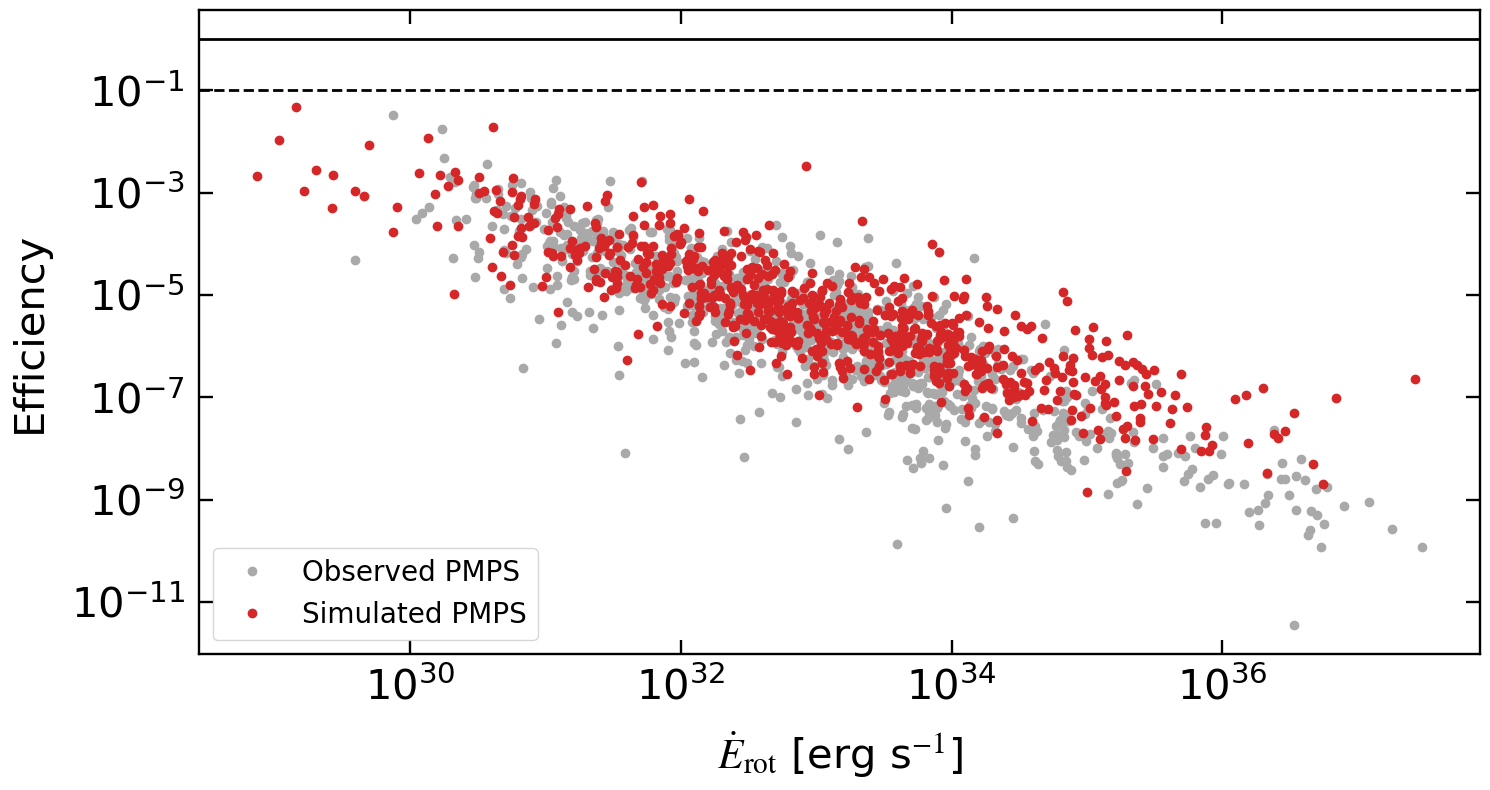

In [59]:
fig, ax = plt.subplots(figsize=(15, 8))
ax.set_xlabel(r"$\dot{E}_{\rm rot}$ [erg s$^{-1}$]")
ax.set_ylabel(r"Efficiency")

ax.loglog(
    Erot_dot_pk_obs,
    eff_radio_pk_obs,
    "o",
    color="darkgray",
    ms=6,
    alpha=1,
    rasterized=True,
    label="Observed PMPS",
)
ax.loglog(
    Erot_dot_pk_sim,
    eff_radio_pk_sim,
    "o",
    color="tab:red",
    ms=6,
    alpha=1,
    rasterized=True,
    label="Simulated PMPS",
)

ax.axhline(y=1, color="black", linestyle="-", linewidth=2)
ax.axhline(y=0.1, color="black", linestyle="--", linewidth=2)

plt.legend(frameon=True, loc=0, fontsize=20)

plt.show()

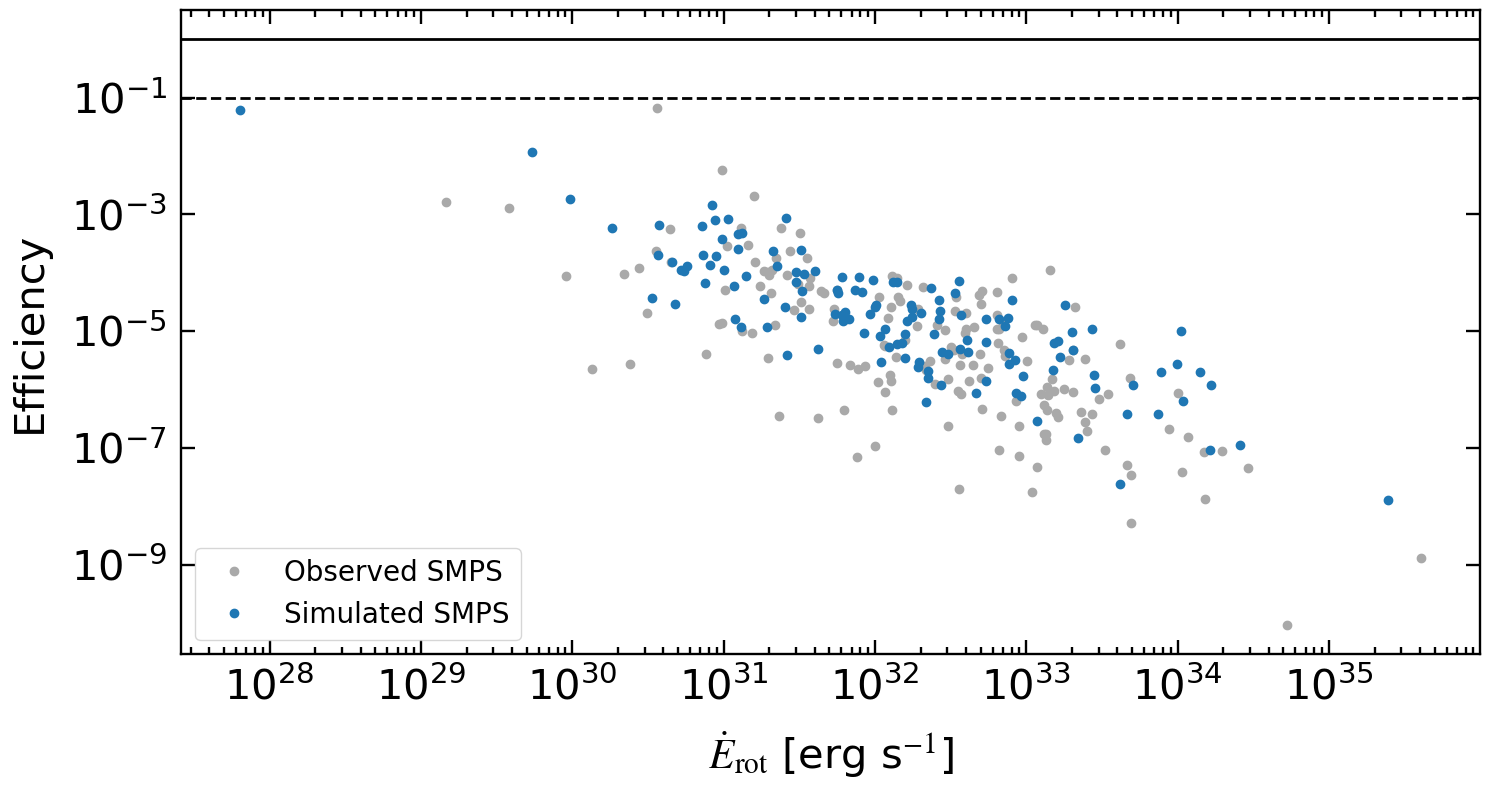

In [60]:
fig, ax = plt.subplots(figsize=(15, 8))
ax.set_xlabel(r"$\dot{E}_{\rm rot}$ [erg s$^{-1}$]")
ax.set_ylabel(r"Efficiency")

ax.loglog(
    Erot_dot_sw_obs,
    eff_radio_sw_obs,
    "o",
    color="darkgray",
    ms=6,
    alpha=1,
    rasterized=True,
    label="Observed SMPS",
)
ax.loglog(
    Erot_dot_sw_sim,
    eff_radio_sw_sim,
    "o",
    color="tab:blue",
    ms=6,
    alpha=1,
    rasterized=True,
    label="Simulated SMPS",
)
ax.axhline(y=1, color="black", linestyle="-", linewidth=2)
ax.axhline(y=0.1, color="black", linestyle="--", linewidth=2)

plt.legend(frameon=True, loc=0, fontsize=20)

plt.show()

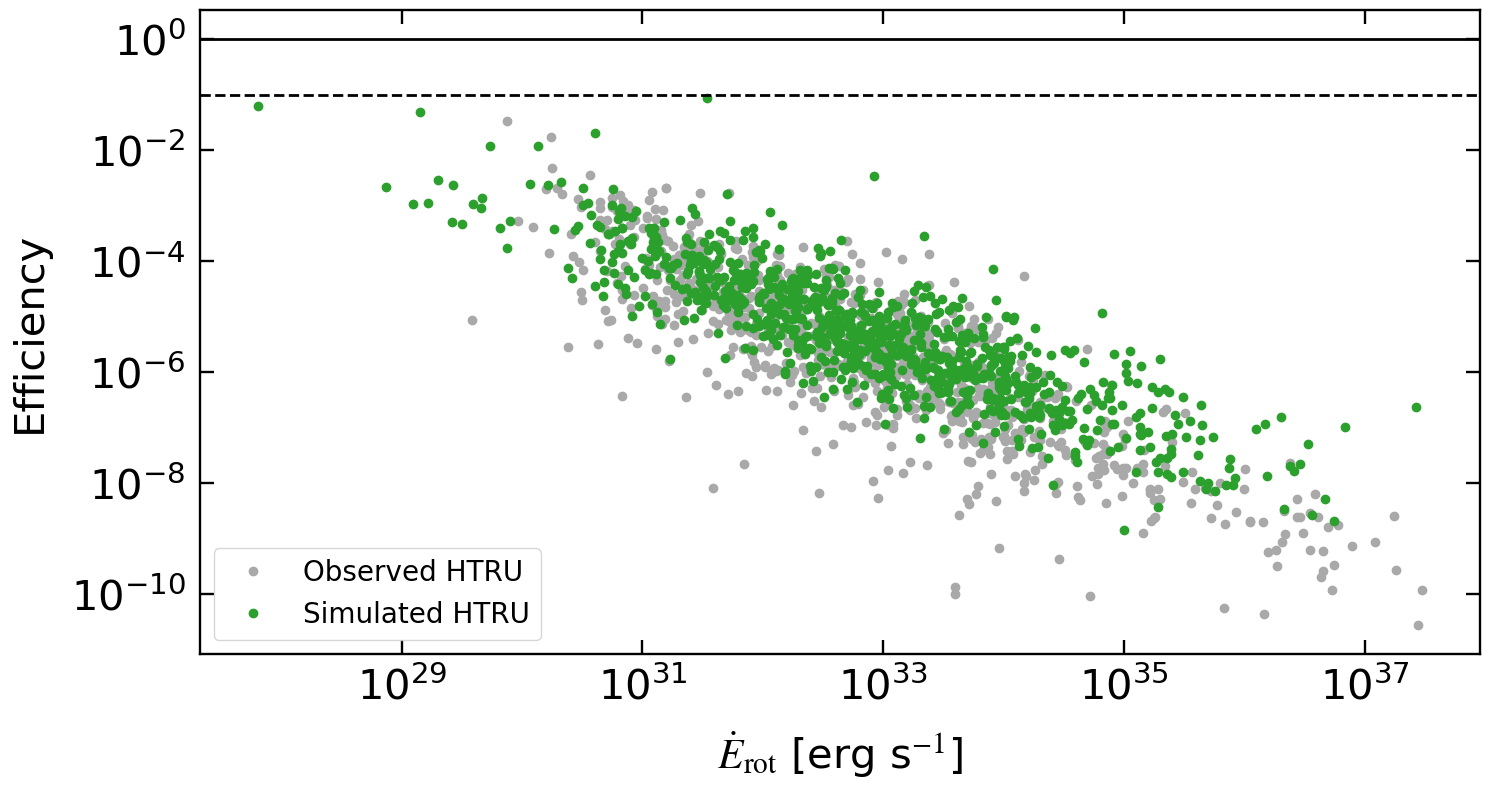

In [61]:
fig, ax = plt.subplots(figsize=(15, 8))
ax.set_xlabel(r"$\dot{E}_{\rm rot}$ [erg s$^{-1}$]")
ax.set_ylabel(r"Efficiency")

ax.loglog(
    Erot_dot_htru_obs,
    eff_radio_htru_obs,
    "o",
    color="darkgray",
    ms=6,
    alpha=1,
    rasterized=True,
    label="Observed HTRU",
)
ax.loglog(
    Erot_dot_htru_sim,
    eff_radio_htru_sim,
    "o",
    color="tab:green",
    ms=6,
    alpha=1,
    rasterized=True,
    label="Simulated HTRU",
)

ax.axhline(y=1, color="black", linestyle="-", linewidth=2)
ax.axhline(y=0.1, color="black", linestyle="--", linewidth=2)

plt.legend(frameon=True, loc=0, fontsize=20)

plt.show()

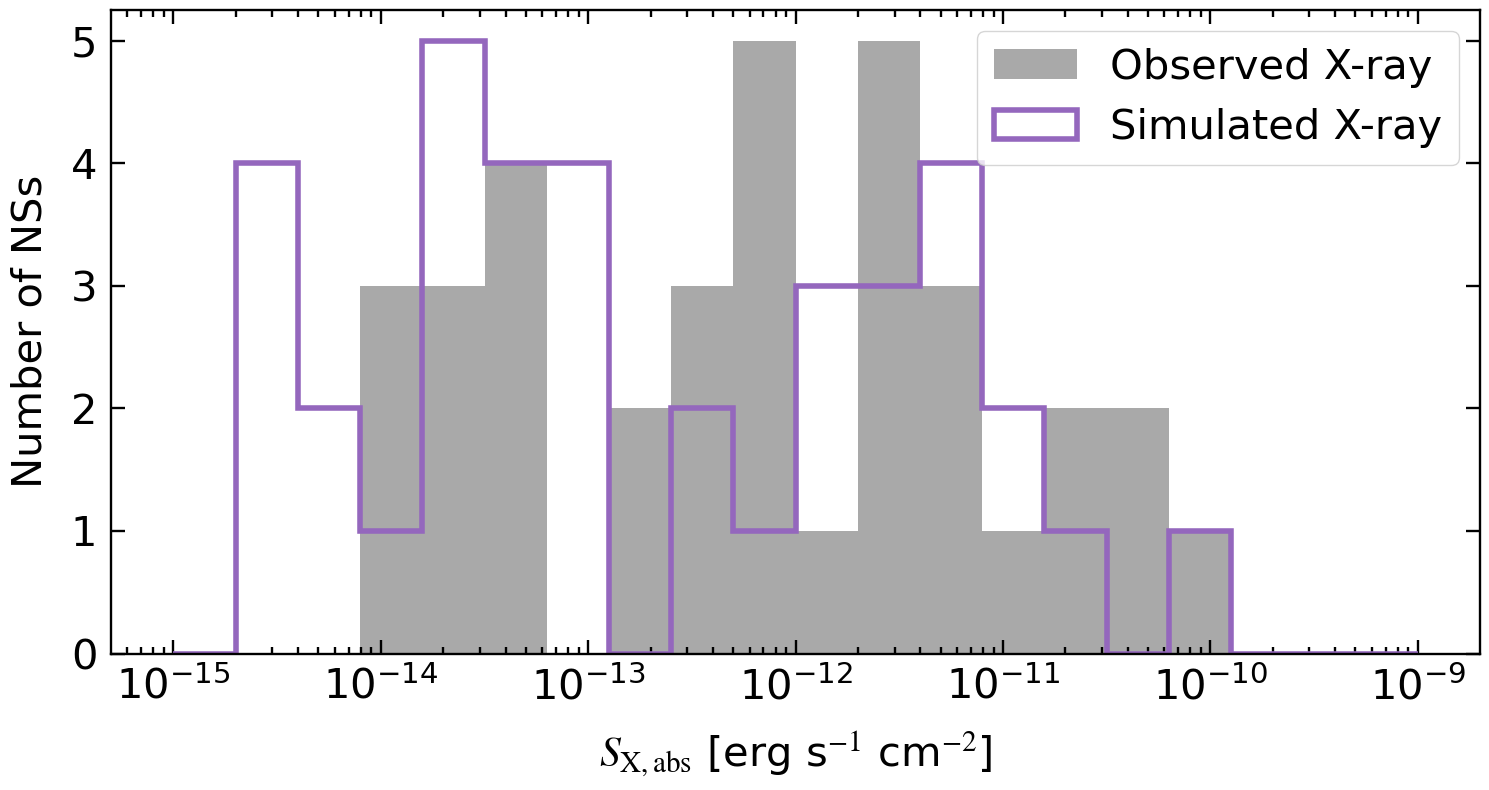

In [62]:
if survey_x:
    S_x_bins = np.logspace(-15.0, -9, 21)

    fig, ax = plt.subplots(figsize=(15, 8))

    ax.hist(
        S_x_abs_obs,
        bins=S_x_bins,
        histtype="stepfilled",
        color="darkgray",
        lw=4,
        label="Observed X-ray",
    )
    ax.hist(
        S_x_rcs_abs_sim,
        bins=S_x_bins,
        histtype="step",
        edgecolor="tab:purple",
        lw=4,
        label="Simulated X-ray",
    )
    plt.xlabel(r"$S_{\rm X, abs}$ [erg s$^{-1}$ cm$^{-2}$]")
    plt.ylabel(r"Number of NSs")
    ax.set_xscale("log")
    ax.legend(frameon=True, loc=0)

    plt.show()

In [63]:
if survey_x:
    # Sort the flux densities in ascending order
    sorted_S_x_sim = np.sort(S_x_rcs_abs_sim)
    sorted_S_x_obs = np.sort(S_x_abs_obs)

    # Calculate the cumulative number of sources
    cumulative_number_sim = np.arange(len(sorted_S_x_sim), 0, -1)
    cumulative_number_obs = np.arange(len(sorted_S_x_obs), 0, -1)

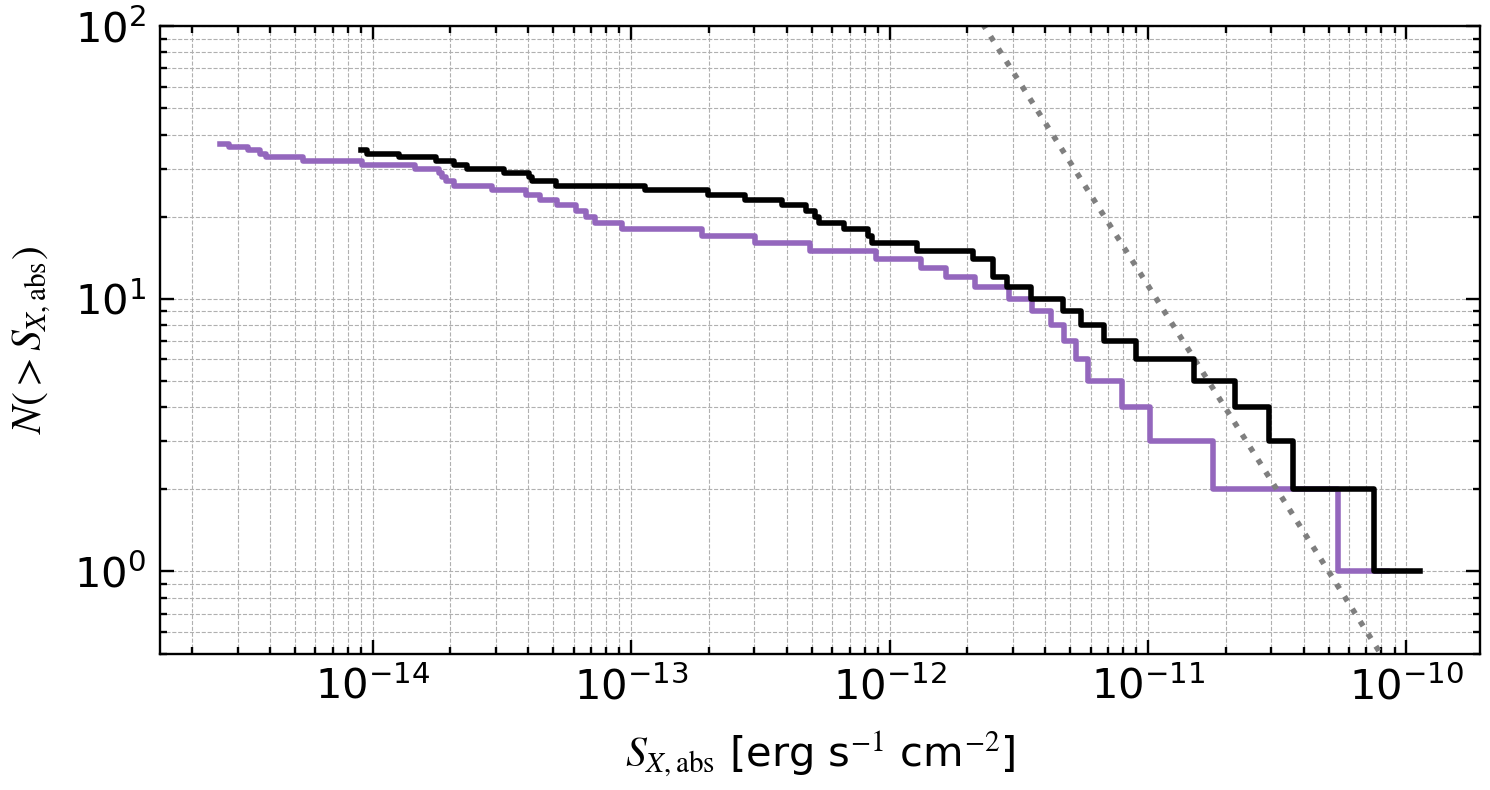

In [64]:
if survey_x:
    # Create the log N - log S step plot
    fig, ax = plt.subplots(figsize=(15, 8))

    ax.step(
        sorted_S_x_sim,
        cumulative_number_sim,
        where="mid",
        lw=4,
        color="tab:purple",
    )
    ax.plot(
        sorted_S_x_obs,
        (sorted_S_x_obs / 5.0e-11) ** (-3.0 / 2.0),
        lw=4,
        ls=":",
        color="tab:gray",
    )
    ax.step(
        sorted_S_x_obs, cumulative_number_obs, where="mid", lw=4, color="black"
    )

    # Set logarithmic scale
    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_ylim(0.5, 1.0e2)

    # Adding titles and labels
    plt.xlabel(r"$S_{X, \rm{abs}}$ [erg s$^{-1}$ cm$^{-2}$]")
    plt.ylabel(r"$N(>S_{X, \rm{abs}})$")

    # Add grid lines
    plt.grid(True, which="both", ls="--")

    # Show the plot
    plt.show()

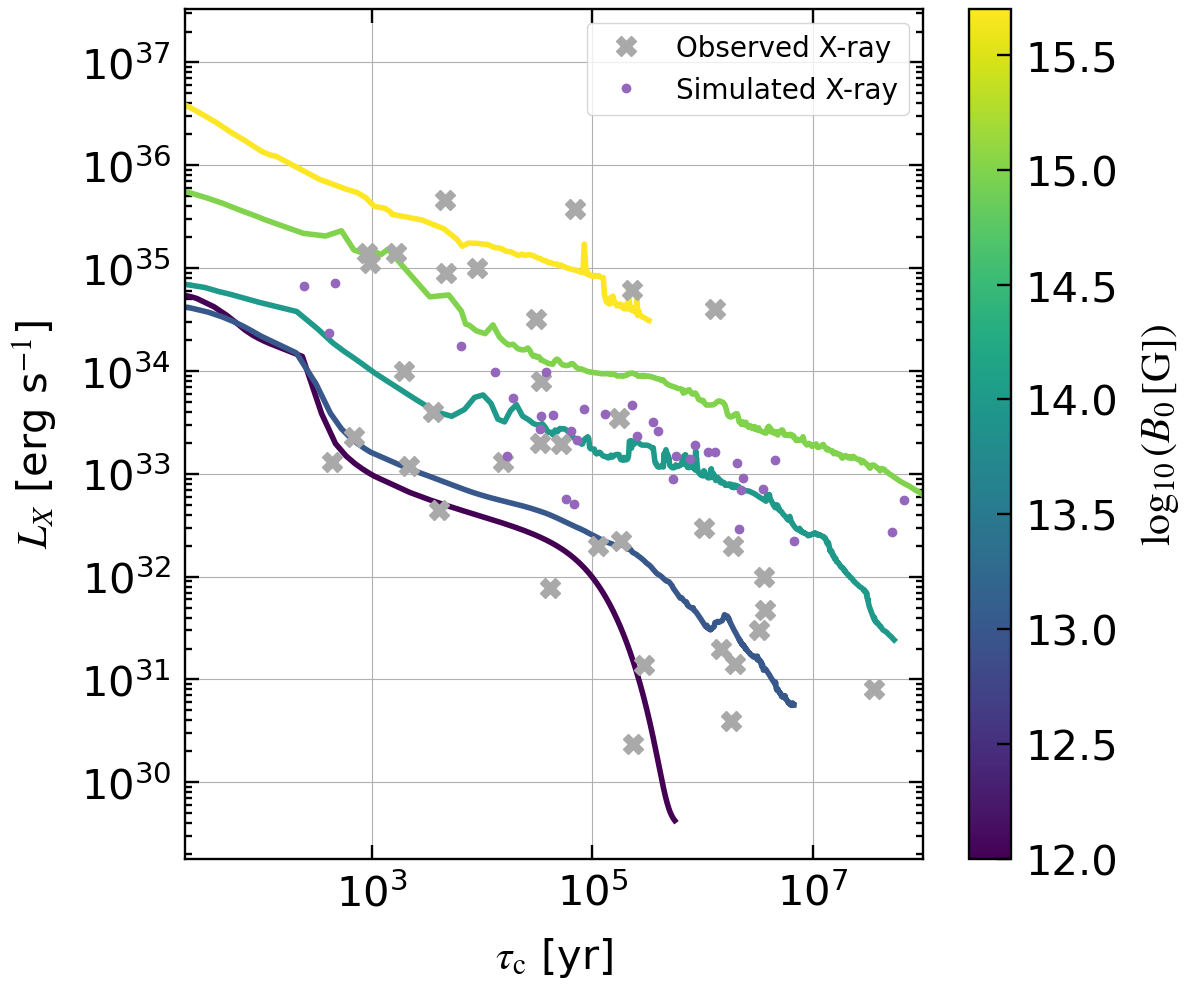

In [65]:
if survey_x:
    vmin, vmax = np.min(log_B_range), np.max(log_B_range)

    # Create a colormap and normalize it.
    cmap = plt.cm.viridis
    norm = Normalize(vmin=vmin, vmax=vmax)

    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    fig, ax = plt.subplots(figsize=(12, 10))

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(20.0, 1.0e8)
    # ax.set_ylim(Pdot_min,Pdot_max)
    ax.set_xlabel(r"$\tau_{\rm c}$ [yr]")
    ax.set_ylabel(r"$L_{X}$ [erg s$^{-1}$]")

    ax.plot(
        tau_c_B12,
        L12,
        linestyle="-",
        linewidth=4,
        color=cmap(norm(log_B_range[0])),
        rasterized=True,
    )
    ax.plot(
        tau_c_B13,
        L13,
        linestyle="-",
        linewidth=4,
        color=cmap(norm(log_B_range[1])),
        rasterized=True,
    )
    ax.plot(
        tau_c_B14,
        L14,
        linestyle="-",
        linewidth=4,
        color=cmap(norm(log_B_range[2])),
        rasterized=True,
    )
    ax.plot(
        tau_c_B15,
        L15,
        linestyle="-",
        linewidth=4,
        color=cmap(norm(log_B_range[3])),
        rasterized=True,
    )
    ax.plot(
        tau_c_B5e15,
        L5e15,
        linestyle="-",
        linewidth=4,
        color=cmap(norm(log_B_range[4])),
        rasterized=True,
    )

    ax.plot(
        age_char_x_obs,
        L_x_bol_obs,
        marker="X",
        color="darkgray",
        linestyle="None",
        markersize=15,
        alpha=1,
        rasterized=True,
        label="Observed X-ray",
    )
    ax.plot(
        age_char_x_sim,
        L_x_sim,
        marker="o",
        color="tab:purple",
        linestyle="None",
        markersize=6,
        alpha=1,
        rasterized=True,
        label="Simulated X-ray",
    )

    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label(r"$\log_{10}(B_0 \, {\rm[G]})$")

    plt.legend(frameon=True, loc=0, fontsize=20)

    plt.grid()

NOTE: For calculating the characteristic age for the cooling curves we considered the value of $P$ and $\dot{P}$ computed by solving equations (10) and (11) in [Graber et al. 2024](https://ui.adsabs.harvard.edu/abs/2024ApJ...968...16G/abstract) and assuming an initial spin period of 0.001 s, an initial inclination angle of 60 deg and the magnetic field evolution associated with the cooling curves.

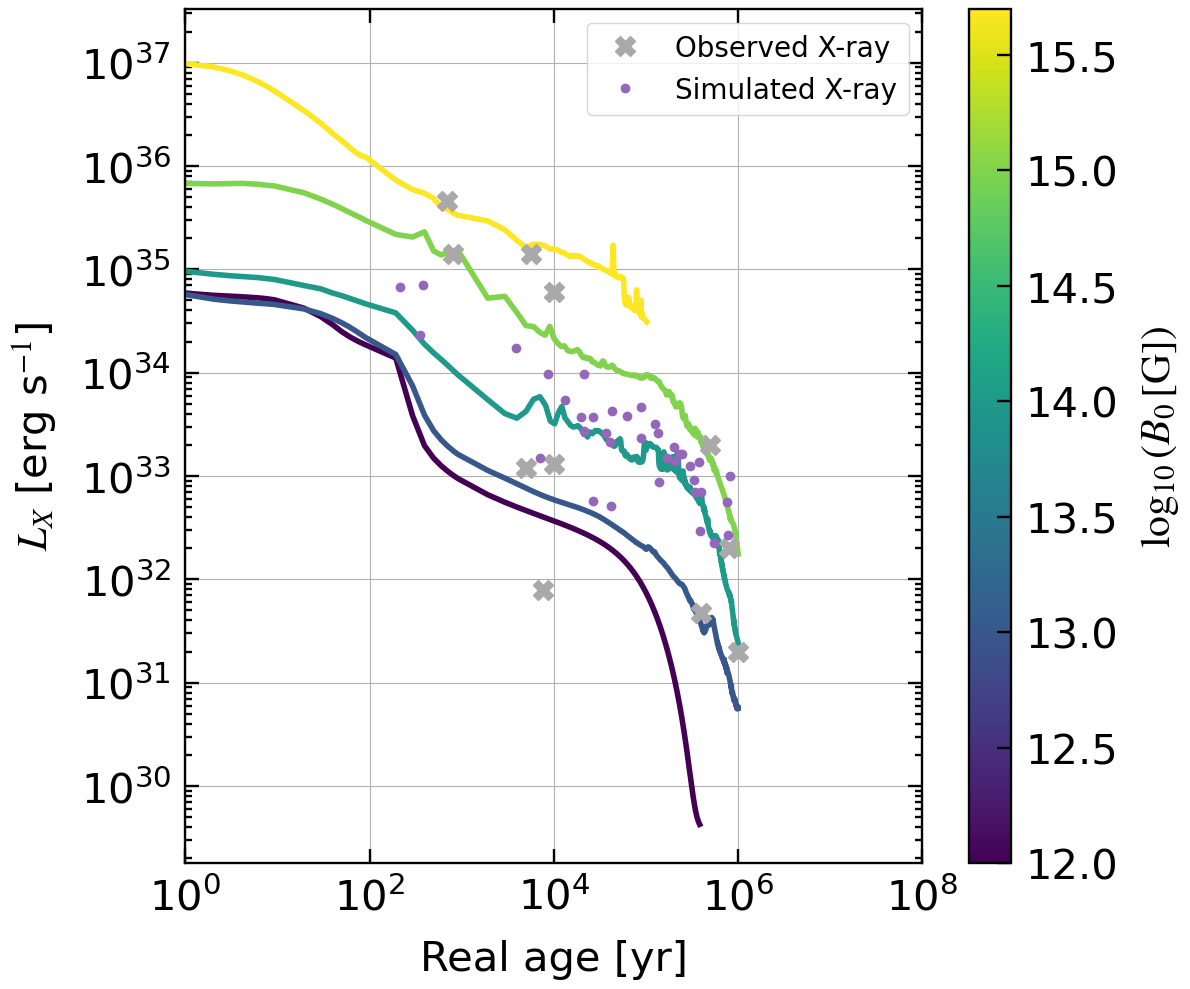

In [66]:
if survey_x:
    fig, ax = plt.subplots(figsize=(12, 10))

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(1.0, 1.0e8)
    # ax.set_ylim(Pdot_min,Pdot_max)
    ax.set_xlabel(r"Real age [yr]")
    ax.set_ylabel(r"$L_{X}$ [erg s$^{-1}$]")

    ax.plot(
        t12,
        L12,
        linestyle="-",
        linewidth=4,
        color=cmap(norm(log_B_range[0])),
        rasterized=True,
    )
    ax.plot(
        t13,
        L13,
        linestyle="-",
        linewidth=4,
        color=cmap(norm(log_B_range[1])),
        rasterized=True,
    )
    ax.plot(
        t14,
        L14,
        linestyle="-",
        linewidth=4,
        color=cmap(norm(log_B_range[2])),
        rasterized=True,
    )
    ax.plot(
        t15,
        L15,
        linestyle="-",
        linewidth=4,
        color=cmap(norm(log_B_range[3])),
        rasterized=True,
    )
    ax.plot(
        t5e15,
        L5e15,
        linestyle="-",
        linewidth=4,
        color=cmap(norm(log_B_range[4])),
        rasterized=True,
    )

    ax.plot(
        age_x_obs * 1000,
        L_x_bol_obs,
        marker="X",
        color="darkgray",
        linestyle="None",
        markersize=15,
        alpha=1,
        rasterized=True,
        label="Observed X-ray",
    )
    ax.plot(
        age_x_sim,
        L_x_sim,
        marker="o",
        color="tab:purple",
        linestyle="None",
        markersize=6,
        alpha=1,
        rasterized=True,
        label="Simulated X-ray",
    )

    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label(r"$\log_{10}(B_0 \, {\rm[G]})$")

    plt.legend(frameon=True, loc=0, fontsize=20)

    plt.grid()

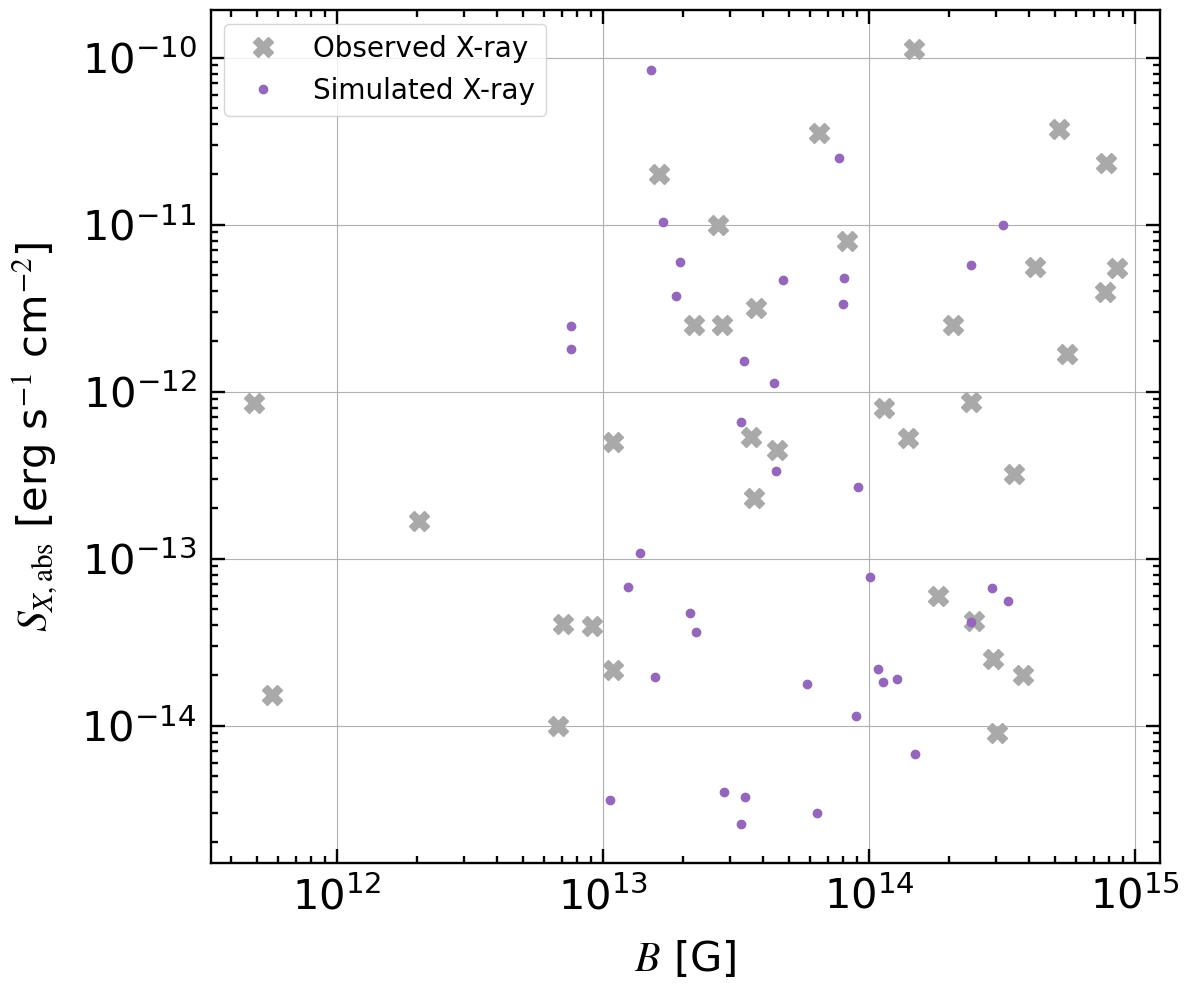

In [67]:
if survey_x:
    fig, ax = plt.subplots(figsize=(12, 10))

    ax.set_xlabel(r"$B$ [G]")
    ax.set_ylabel(r"$S_{X, \rm{abs}}$ [erg s$^{-1}$ cm$^{-2}$]")
    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.plot(
        B_x_obs,
        S_x_abs_obs,
        marker="X",
        color="darkgray",
        linestyle="None",
        markersize=15,
        alpha=1,
        rasterized=True,
        label="Observed X-ray",
    )
    ax.plot(
        B_x_sim,
        S_x_rcs_abs_sim,
        marker="o",
        color="tab:purple",
        linestyle="None",
        markersize=6,
        alpha=1,
        rasterized=True,
        label="Simulated X-ray",
    )

    plt.legend(frameon=True, loc=0, fontsize=20)

    plt.grid()

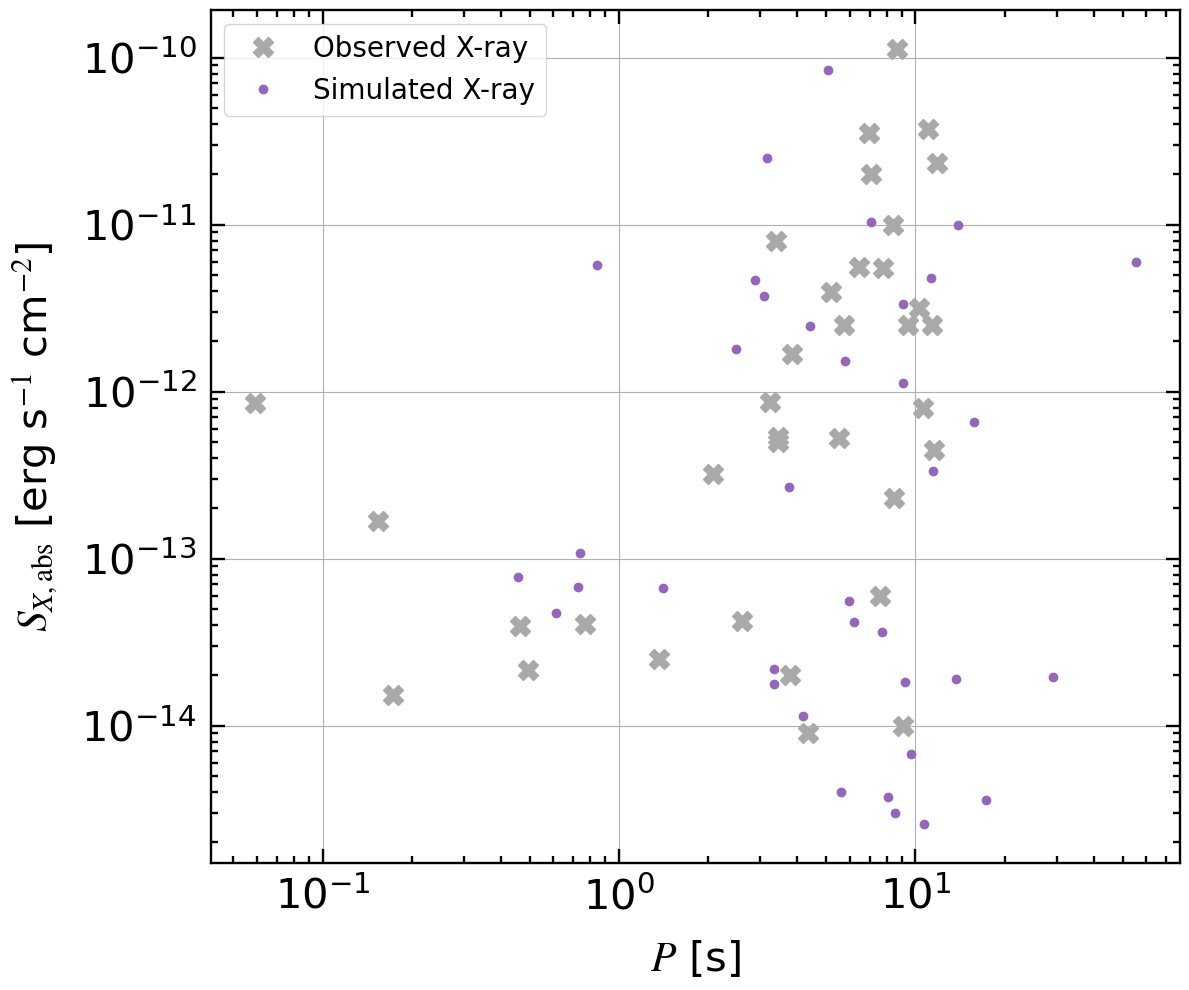

In [68]:
if survey_x:
    fig, ax = plt.subplots(figsize=(12, 10))

    ax.set_xlabel(r"$P$ [s]")
    ax.set_ylabel(r"$S_{X, \rm{abs}}$ [erg s$^{-1}$ cm$^{-2}$]")
    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.plot(
        P_x_obs,
        S_x_abs_obs,
        marker="X",
        color="darkgray",
        linestyle="None",
        markersize=15,
        alpha=1,
        rasterized=True,
        label="Observed X-ray",
    )
    ax.plot(
        P_x_sim,
        S_x_rcs_abs_sim,
        marker="o",
        color="tab:purple",
        linestyle="None",
        markersize=6,
        alpha=1,
        rasterized=True,
        label="Simulated X-ray",
    )

    plt.legend(frameon=True, loc=0, fontsize=20)

    plt.grid()

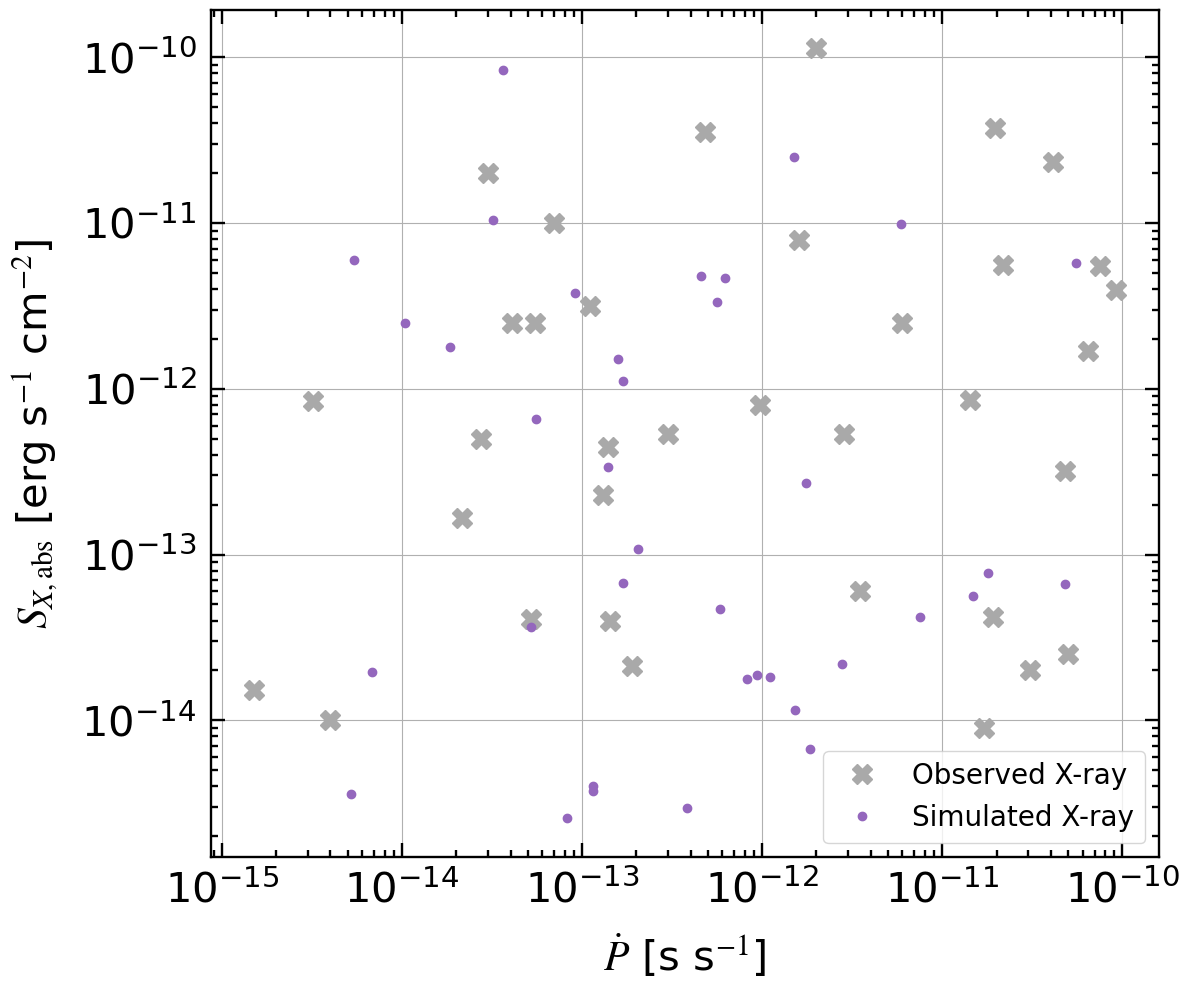

In [69]:
if survey_x:
    fig, ax = plt.subplots(figsize=(12, 10))

    ax.set_xlabel(r"$\dot{P}$ [s s$^{-1}$]")
    ax.set_ylabel(r"$S_{X, \rm{abs}}$ [erg s$^{-1}$ cm$^{-2}$]")
    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.plot(
        Pdot_x_obs,
        S_x_abs_obs,
        marker="X",
        color="darkgray",
        linestyle="None",
        markersize=15,
        alpha=1,
        rasterized=True,
        label="Observed X-ray",
    )
    ax.plot(
        Pdot_x_sim,
        S_x_rcs_abs_sim,
        marker="o",
        color="tab:purple",
        linestyle="None",
        markersize=6,
        alpha=1,
        rasterized=True,
        label="Simulated X-ray",
    )

    plt.legend(frameon=True, loc=0, fontsize=20)

    plt.grid()

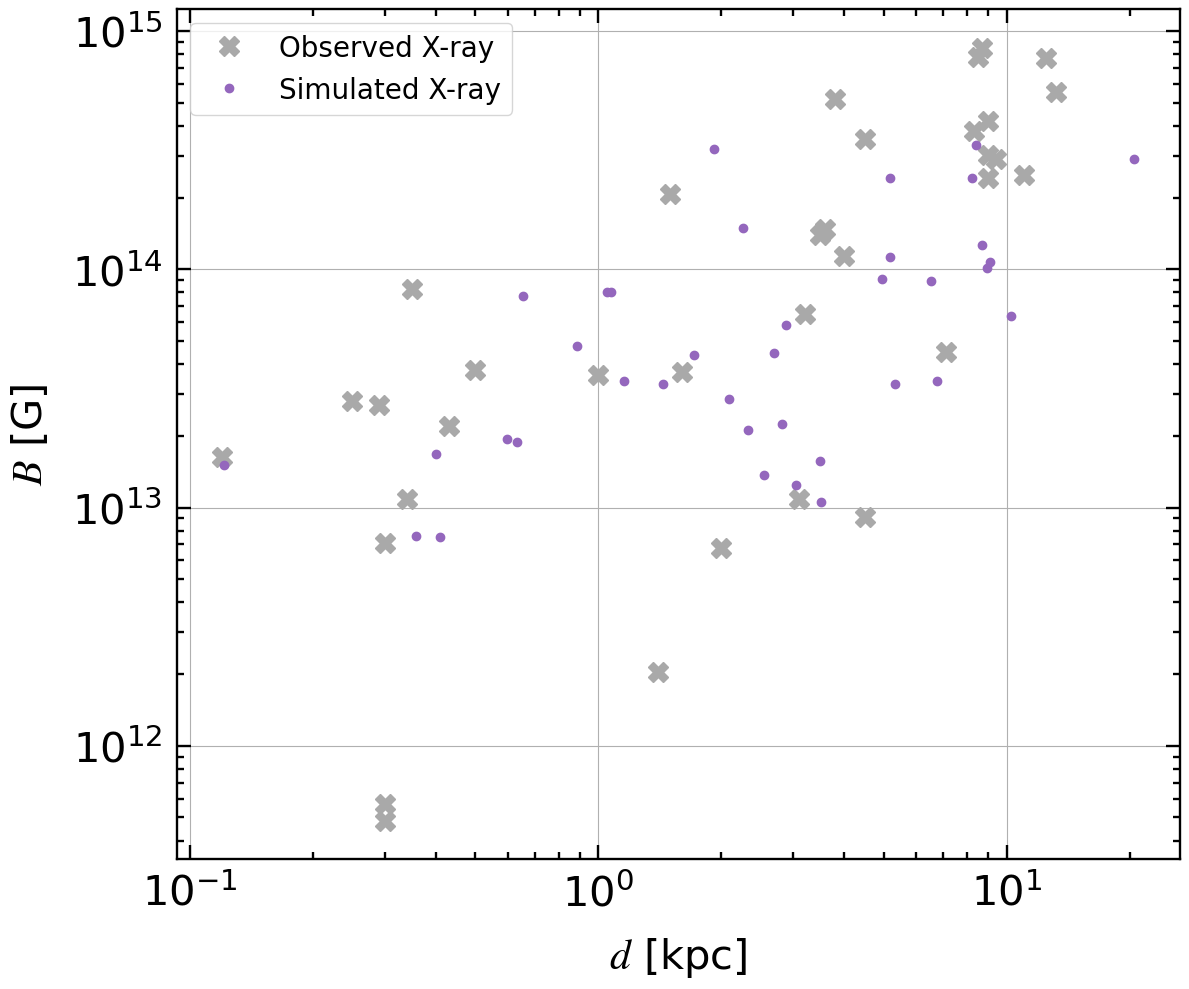

In [70]:
if survey_x:
    fig, ax = plt.subplots(figsize=(12, 10))

    ax.set_xlabel(r"$d$ [kpc]")
    ax.set_ylabel(r"$B$ [G]")
    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.plot(
        dist_x_obs,
        B_x_obs,
        marker="X",
        color="darkgray",
        linestyle="None",
        markersize=15,
        alpha=1,
        rasterized=True,
        label="Observed X-ray",
    )
    ax.plot(
        dist_x_sim,
        B_x_sim,
        marker="o",
        color="tab:purple",
        linestyle="None",
        markersize=6,
        alpha=1,
        rasterized=True,
        label="Simulated X-ray",
    )

    plt.legend(frameon=True, loc=0, fontsize=20)

    plt.grid()

Comparing the pulse-width distributions.

In [71]:
# Converting pulse width into [deg].
w_pk_sim_deg = w_eff_pk_sim / P_pk_sim * 360.0
w_sw_sim_deg = w_eff_sw_sim / P_sw_sim * 360.0
w_htru_sim_deg = w_eff_htru_sim / P_htru_sim * 360.0

w10_pk_obs_deg = w10_pk_obs / 1000 / P_pk_obs_w10 * 360.0
w10_sw_obs_deg = w10_sw_obs / 1000 / P_sw_obs_w10 * 360.0
w10_htru_obs_deg = w10_htru_obs / 1000 / P_htru_obs_w10 * 360.0

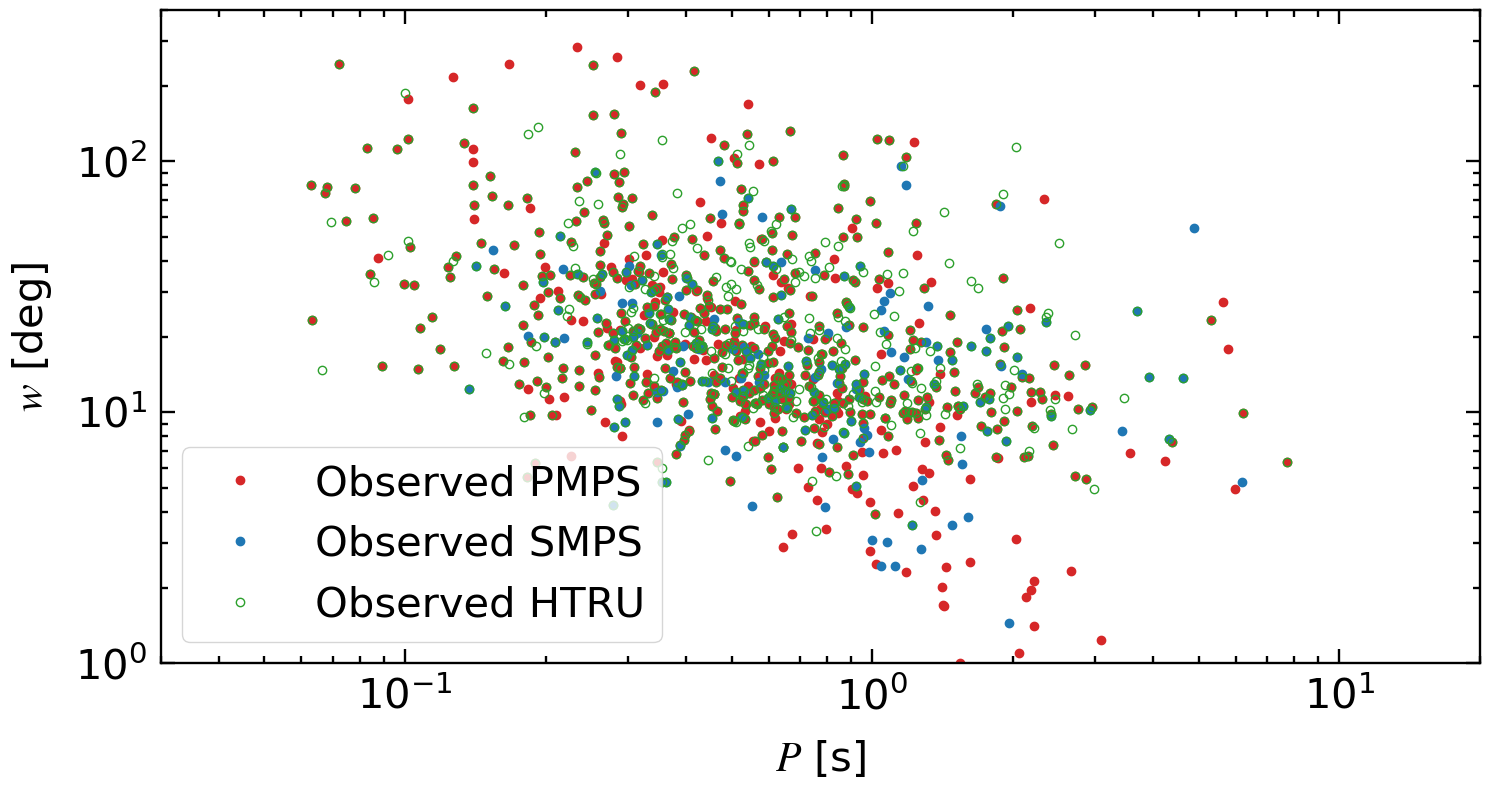

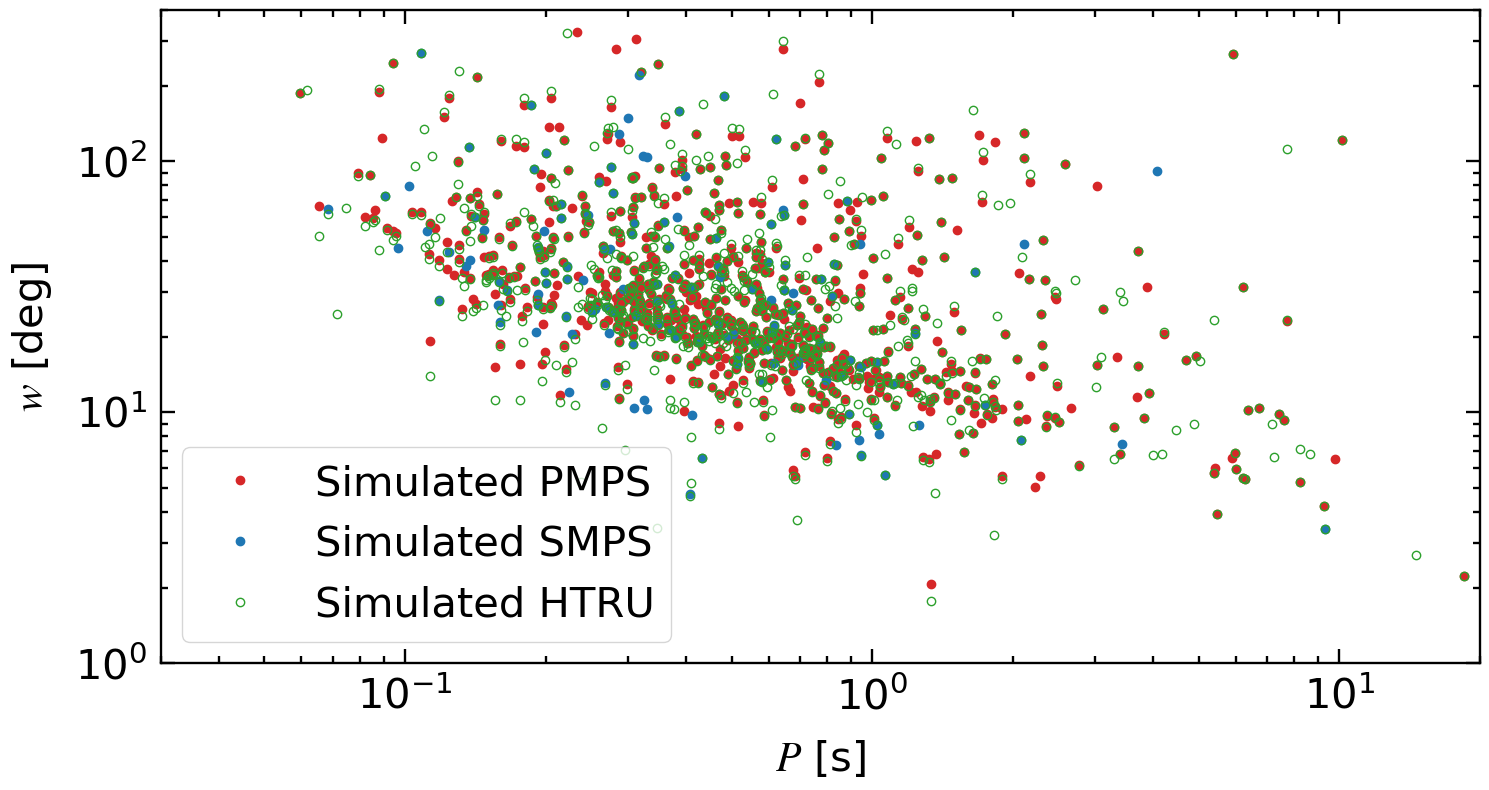

In [72]:
fig, ax = plt.subplots(figsize=(15, 8))

ax.loglog(
    P_pk_obs_w10,
    w10_pk_obs_deg,
    "o",
    color="tab:red",
    ms=6,
    rasterized=True,
    label="Observed PMPS",
)
ax.loglog(
    P_sw_obs_w10,
    w10_sw_obs_deg,
    "o",
    color="tab:blue",
    ms=6,
    rasterized=True,
    label="Observed SMPS",
)

ax.loglog(
    P_htru_obs_w10,
    w10_htru_obs_deg,
    "o",
    fillstyle="none",
    color="tab:green",
    ms=6,
    alpha=1,
    rasterized=True,
    label="Observed HTRU",
)
plt.xlim(3.0e-2, 20)
plt.ylim(1, 400)
plt.xlabel(r"$P$ [s]")
plt.ylabel(r"$w$ [deg]")
ax.legend(frameon=True, loc=3)


fig, ax = plt.subplots(figsize=(15, 8))

ax.loglog(
    P_pk_sim,
    w_pk_sim_deg,
    "o",
    color="tab:red",
    ms=6,
    rasterized=True,
    label="Simulated PMPS",
)
ax.loglog(
    P_sw_sim,
    w_sw_sim_deg,
    "o",
    color="tab:blue",
    ms=6,
    rasterized=True,
    label="Simulated SMPS",
)
ax.loglog(
    P_htru_sim,
    w_htru_sim_deg,
    "o",
    fillstyle="none",
    color="tab:green",
    ms=6,
    alpha=1,
    rasterized=True,
    label="Simulated HTRU",
)

plt.xlim(3.0e-2, 20)
plt.ylim(1, 400)
plt.xlabel(r"$P$ [s]")
plt.ylabel(r"$w$ [deg]")
ax.legend(frameon=True, loc=3)

plt.show()